# 1. Подготовка среды выполнения и структуры эксперимента

На первом этапе подготавливается рабочая среда для проведения эксперимента по генерации и обработке изображений при помощи нейросетей. Создается единая структура каталогов, в которой будут храниться исходные изображения, промежуточные данные, обученные модели, таблицы с метриками, рисунки для диссертации и файлы для будущего пользовательского приложения.

Научная новизна эксперимента закладывается уже на этом этапе. Эксперимент строится как единый воспроизводимый конвейер обработки изображений: от загрузки открытого набора данных до обучения моделей сегментации, восстановления качества и генерации изображений. Такой подход позволяет не просто обучить отдельную модель, а сопоставить несколько способов нейросетевой обработки изображений в одинаковых условиях и подготовить результаты к внедрению в прикладной сервис.

In [1]:
# Обновляем установщик библиотек.
# Это снижает риск ошибок при установке дополнительных пакетов.
!python -m pip install -q --upgrade pip

# Устанавливаем библиотеки для обработки изображений, обучения нейросетей и расчета метрик.
# Библиотека torch используется для построения и обучения нейронных сетей.
# Библиотека torchvision содержит готовые средства для работы с изображениями.
# Библиотека segmentation-models-pytorch нужна для моделей сегментации
# сегментация означает выделение нужной области изображения по пикселям.
# Библиотека torchmetrics нужна для расчета численных показателей качества.
# Библиотека scikit-image нужна для расчета показателей качества восстановленных изображений.
# Библиотека diffusers будет использоваться позже для небольшого генеративного эксперимента.
# Генеративная модель означает модель, которая может создавать новые изображения.
!pip install -q \
    segmentation-models-pytorch \
    torchmetrics \
    scikit-image \
    python-dotenv \
    openai \
    diffusers \
    accelerate \
    datasets \
    transformers \
    opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.8 MB/s eta 0:00:00


In [2]:
# Импортируем стандартные библиотеки языка Python.
# Они нужны для работы с файлами, каталогами, датами, случайными числами и таблицами.
import os
import json
import random
import shutil
import platform
from pathlib import Path
from datetime import datetime

# Импортируем библиотеки для численных вычислений и таблиц.
import numpy as np
import pandas as pd

# Импортируем библиотеку для обучения нейронных сетей.
import torch

# Импортируем библиотеку для работы с изображениями.
from PIL import Image

# Импортируем библиотеку для построения графиков.
import matplotlib.pyplot as plt

# Задаем начальное число для повторяемости эксперимента.
# Повторяемость означает, что при повторном запуске будут получаться максимально близкие результаты.
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Определяем устройство, на котором будут выполняться вычисления.
# Если доступен графический ускоритель, обучение будет выполняться на нем.
# Если графический ускоритель недоступен, код продолжит работу на центральном процессоре.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Создаем основной каталог проекта.
PROJECT_DIR = Path("/content/image_generation_processing_project")

# Создаем каталог для исходных и подготовленных данных.
DATA_DIR = PROJECT_DIR / "data"

# Создаем каталог для результатов эксперимента.
RESULTS_DIR = PROJECT_DIR / "results"

# Создаем каталог для файлов, которые затем будут перенесены в пользовательское приложение.
EXPORT_DIR = PROJECT_DIR / "export"

# Создаем подробную структуру проекта.
DIRECTORIES = {
    "исходные данные": DATA_DIR / "raw",
    "подготовленные данные": DATA_DIR / "processed",
    "модели": RESULTS_DIR / "models",
    "метрики": RESULTS_DIR / "metrics",
    "рисунки": RESULTS_DIR / "figures",
    "примеры": RESULTS_DIR / "examples",
    "отчеты": RESULTS_DIR / "reports",
    "журналы": RESULTS_DIR / "logs",
    "файлы для приложения": EXPORT_DIR,
}

for directory in DIRECTORIES.values():
    directory.mkdir(parents=True, exist_ok=True)

# Собираем сведения о среде выполнения.
# Эти сведения пригодятся для раздела диссертации об условиях проведения эксперимента.
environment_info = {
    "дата_и_время_запуска": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "версия_python": platform.python_version(),
    "операционная_система": platform.platform(),
    "устройство_вычислений": DEVICE,
    "название_графического_ускорителя": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "графический ускоритель недоступен",
    "версия_torch": torch.__version__,
    "начальное_число_для_повторяемости": SEED,
    "основной_каталог_проекта": str(PROJECT_DIR),
}

# Сохраняем паспорт среды в отдельный файл.
environment_path = RESULTS_DIR / "reports" / "environment_info.json"

with open(environment_path, "w", encoding="utf-8") as file:
    json.dump(environment_info, file, ensure_ascii=False, indent=4)

# Выводим краткие сведения на экран.
print("Среда выполнения подготовлена")
print("Основной каталог проекта:", PROJECT_DIR)
print("Устройство вычислений:", DEVICE)
print("Графический ускоритель:", environment_info["название_графического_ускорителя"])
print("Файл со сведениями о среде:", environment_path)

Среда выполнения подготовлена
Основной каталог проекта: /content/image_generation_processing_project
Устройство вычислений: cuda
Графический ускоритель: Tesla T4
Файл со сведениями о среде: /content/image_generation_processing_project/results/reports/environment_info.json


In [3]:
# Подключаем Google Drive.
# Это нужно для сохранения результатов после завершения сеанса Colab.
from google.colab import drive

drive.mount("/content/drive")

# Создаем каталог проекта на Google Drive.
DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/image_generation_processing_project")

DRIVE_DIRECTORIES = {
    "корневой каталог на диске": DRIVE_PROJECT_DIR,
    "копии моделей": DRIVE_PROJECT_DIR / "models",
    "копии метрик": DRIVE_PROJECT_DIR / "metrics",
    "копии рисунков": DRIVE_PROJECT_DIR / "figures",
    "копии отчетов": DRIVE_PROJECT_DIR / "reports",
    "готовые архивы": DRIVE_PROJECT_DIR / "exports",
}

for directory in DRIVE_DIRECTORIES.values():
    directory.mkdir(parents=True, exist_ok=True)

# Сохраняем сведения о расположении каталогов на Google Drive.
drive_info = {
    "каталог_проекта_на_google_drive": str(DRIVE_PROJECT_DIR),
    "каталог_моделей": str(DRIVE_DIRECTORIES["копии моделей"]),
    "каталог_метрик": str(DRIVE_DIRECTORIES["копии метрик"]),
    "каталог_рисунков": str(DRIVE_DIRECTORIES["копии рисунков"]),
    "каталог_отчетов": str(DRIVE_DIRECTORIES["копии отчетов"]),
    "каталог_архивов": str(DRIVE_DIRECTORIES["готовые архивы"]),
}

drive_info_path = RESULTS_DIR / "reports" / "drive_info.json"

with open(drive_info_path, "w", encoding="utf-8") as file:
    json.dump(drive_info, file, ensure_ascii=False, indent=4)

print("Google Drive подключен")
print("Каталог проекта на Google Drive:", DRIVE_PROJECT_DIR)
print("Файл со сведениями о сохранении:", drive_info_path)

Mounted at /content/drive
Google Drive подключен
Каталог проекта на Google Drive: /content/drive/MyDrive/image_generation_processing_project
Файл со сведениями о сохранении: /content/image_generation_processing_project/results/reports/drive_info.json


# 2. Загрузка основного набора изображений

На втором этапе загружается открытый набор изображений Oxford-IIIT Pet. Набор содержит изображения кошек и собак разных пород, а также файлы разметки. Для выбранной темы набор удобен тем, что позволяет решать сразу несколько задач: выделение объекта на изображении, восстановление качества изображения и последующую генерацию похожих изображений на основе изученного распределения данных.

Загрузка выполняется по прямым адресам официального источника. После загрузки архивы распаковываются, проверяется наличие изображений, разметки и служебных файлов. Затем формируется таблица с описанием данных. Такая таблица понадобится для контроля состава набора, построения разбиения на обучающую, проверочную и контрольную части, а также для описания исходных данных в диссертации.

In [4]:
# Импортируем библиотеки для загрузки файлов и работы с архивами.
import urllib.request
import tarfile
from pathlib import Path

# Задаем каталог для официального набора Oxford-IIIT Pet.
OXFORD_DIR = DATA_DIR / "raw" / "oxford_iiit_pet"
OXFORD_DIR.mkdir(parents=True, exist_ok=True)

# Прямые адреса архивов с официального источника.
# Первый архив содержит изображения.
# Второй архив содержит разметку.
IMAGES_URL = "https://thor.robots.ox.ac.uk/~vgg/data/pets/images.tar.gz"
ANNOTATIONS_URL = "https://thor.robots.ox.ac.uk/~vgg/data/pets/annotations.tar.gz"

# Задаем пути для сохранения архивов.
images_archive_path = OXFORD_DIR / "images.tar.gz"
annotations_archive_path = OXFORD_DIR / "annotations.tar.gz"

# Описываем функцию загрузки файла.
# Функция проверяет, был ли файл загружен ранее.
# Если файл уже существует и не пустой, повторная загрузка не выполняется.
def download_file(url, output_path):
    output_path = Path(output_path)

    if output_path.exists() and output_path.stat().st_size > 0:
        print("Файл уже загружен:", output_path.name)
        return

    print("Начата загрузка:", output_path.name)
    urllib.request.urlretrieve(url, output_path)
    print("Загрузка завершена:", output_path.name)

# Загружаем оба архива.
download_file(IMAGES_URL, images_archive_path)
download_file(ANNOTATIONS_URL, annotations_archive_path)

# Описываем функцию распаковки архива.
# Распаковка выполняется только в том случае, если нужная папка еще не создана.
def extract_archive(archive_path, output_dir, expected_folder_name):
    archive_path = Path(archive_path)
    output_dir = Path(output_dir)
    expected_folder = output_dir / expected_folder_name

    if expected_folder.exists():
        print("Архив уже распакован:", expected_folder_name)
        return

    print("Начата распаковка:", archive_path.name)

    with tarfile.open(archive_path, "r:gz") as archive:
        archive.extractall(output_dir)

    print("Распаковка завершена:", archive_path.name)

# Распаковываем изображения и разметку.
extract_archive(images_archive_path, OXFORD_DIR, "images")
extract_archive(annotations_archive_path, OXFORD_DIR, "annotations")

# Проверяем основные каталоги.
images_dir = OXFORD_DIR / "images"
annotations_dir = OXFORD_DIR / "annotations"
trimaps_dir = annotations_dir / "trimaps"

print("Каталог изображений существует:", images_dir.exists())
print("Каталог разметки существует:", annotations_dir.exists())
print("Каталог масок существует:", trimaps_dir.exists())

Начата загрузка: images.tar.gz
Загрузка завершена: images.tar.gz
Начата загрузка: annotations.tar.gz
Загрузка завершена: annotations.tar.gz
Начата распаковка: images.tar.gz


/tmp/ipykernel_27500/46209573.py:52: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  archive.extractall(output_dir)


Распаковка завершена: images.tar.gz
Начата распаковка: annotations.tar.gz
Распаковка завершена: annotations.tar.gz
Каталог изображений существует: True
Каталог разметки существует: True
Каталог масок существует: True


In [5]:
# Получаем список изображений.
image_paths = sorted([
    path for path in images_dir.glob("*.jpg")
    if path.is_file() and not path.name.startswith(".")
])

# Получаем список масок сегментации.
# Маска сегментации означает изображение, где каждому пикселю назначен номер области.
trimap_paths = sorted([
    path for path in trimaps_dir.glob("*.png")
    if path.is_file() and not path.name.startswith(".")
])

# Проверяем наличие служебного файла со списком изображений и метками.
list_file_path = annotations_dir / "list.txt"

print("Количество изображений:", len(image_paths))
print("Количество масок сегментации:", len(trimap_paths))
print("Файл со списком изображений найден:", list_file_path.exists())

# Проверяем первые несколько файлов.
print("\nПримеры изображений:")
for path in image_paths[:5]:
    print(path.name)

print("\nПримеры масок:")
for path in trimap_paths[:5]:
    print(path.name)

Количество изображений: 7390
Количество масок сегментации: 7390
Файл со списком изображений найден: True

Примеры изображений:
Abyssinian_1.jpg
Abyssinian_10.jpg
Abyssinian_100.jpg
Abyssinian_101.jpg
Abyssinian_102.jpg

Примеры масок:
Abyssinian_1.png
Abyssinian_10.png
Abyssinian_100.png
Abyssinian_101.png
Abyssinian_102.png


In [6]:
# Описываем функцию чтения служебного файла list.txt.
# В этом файле содержатся имя изображения, номер класса, вид животного и номер породы.
# Вид животного в исходной разметке задается числом:
# 1 означает кошку
# 2 означает собаку
def read_annotation_list(list_path):
    rows = []

    with open(list_path, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()

            # Пропускаем пустые строки и строки с пояснениями.
            if not line or line.startswith("#"):
                continue

            parts = line.split()

            if len(parts) != 4:
                continue

            image_id, class_id, species_id, breed_id = parts

            rows.append({
                "image_id": image_id,
                "class_id": int(class_id),
                "species_id": int(species_id),
                "breed_id": int(breed_id),
            })

    return pd.DataFrame(rows)

# Читаем таблицу с исходной разметкой.
annotations_table = read_annotation_list(list_file_path)

# Создаем дополнительные поля с понятными обозначениями.
annotations_table["species_name_ru"] = annotations_table["species_id"].map({
    1: "кошка",
    2: "собака",
})

# Название породы можно получить из имени изображения.
# В имени изображения последняя часть после нижнего подчеркивания является номером.
# Остальная часть имени соответствует породе.
annotations_table["breed_name"] = annotations_table["image_id"].apply(
    lambda value: value.rsplit("_", 1)[0]
)

# Создаем пути к изображениям и маскам.
annotations_table["image_path"] = annotations_table["image_id"].apply(
    lambda value: str(images_dir / f"{value}.jpg")
)

annotations_table["trimap_path"] = annotations_table["image_id"].apply(
    lambda value: str(trimaps_dir / f"{value}.png")
)

# Проверяем существование файлов.
annotations_table["image_exists"] = annotations_table["image_path"].apply(
    lambda value: Path(value).exists()
)

annotations_table["trimap_exists"] = annotations_table["trimap_path"].apply(
    lambda value: Path(value).exists()
)

# Добавляем размеры изображений.
# Размеры будут полезны для анализа исходных данных и выбора единого размера входа модели.
widths = []
heights = []

for image_path in annotations_table["image_path"]:
    path = Path(image_path)

    if path.exists():
        with Image.open(path) as image:
            width, height = image.size
    else:
        width, height = None, None

    widths.append(width)
    heights.append(height)

annotations_table["width"] = widths
annotations_table["height"] = heights

# Сохраняем таблицу с описанием набора данных.
manifest_path = RESULTS_DIR / "metrics" / "dataset_manifest.csv"
annotations_table.to_csv(manifest_path, index=False, encoding="utf-8")

# Сохраняем краткую сводку.
dataset_summary = {
    "количество_записей_в_таблице": int(len(annotations_table)),
    "количество_найденных_изображений": int(annotations_table["image_exists"].sum()),
    "количество_найденных_масок": int(annotations_table["trimap_exists"].sum()),
    "количество_классов": int(annotations_table["class_id"].nunique()),
    "количество_пород": int(annotations_table["breed_name"].nunique()),
    "количество_кошек": int((annotations_table["species_name_ru"] == "кошка").sum()),
    "количество_собак": int((annotations_table["species_name_ru"] == "собака").sum()),
    "минимальная_ширина": int(annotations_table["width"].min()),
    "максимальная_ширина": int(annotations_table["width"].max()),
    "минимальная_высота": int(annotations_table["height"].min()),
    "максимальная_высота": int(annotations_table["height"].max()),
}

summary_path = RESULTS_DIR / "metrics" / "dataset_summary.json"

with open(summary_path, "w", encoding="utf-8") as file:
    json.dump(dataset_summary, file, ensure_ascii=False, indent=4)

print("Таблица с описанием данных сохранена:", manifest_path)
print("Краткая сводка сохранена:", summary_path)

print("\nКраткая сводка:")
for key, value in dataset_summary.items():
    print(key, ":", value)

display(annotations_table.head())

Таблица с описанием данных сохранена: /content/image_generation_processing_project/results/metrics/dataset_manifest.csv
Краткая сводка сохранена: /content/image_generation_processing_project/results/metrics/dataset_summary.json

Краткая сводка:
количество_записей_в_таблице : 7349
количество_найденных_изображений : 7349
количество_найденных_масок : 7349
количество_классов : 37
количество_пород : 37
количество_кошек : 2371
количество_собак : 4978
минимальная_ширина : 114
максимальная_ширина : 3264
минимальная_высота : 103
максимальная_высота : 2606


,image_id,class_id,species_id,breed_id,species_name_ru,breed_name,image_path,trimap_path,image_exists,trimap_exists,width,height
0,Abyssinian_100,1,1,1,кошка,Abyssinian,/content/image_generation_processing_project/d...,/content/image_generation_processing_project/d...,True,True,394,500
1,Abyssinian_101,1,1,1,кошка,Abyssinian,/content/image_generation_processing_project/d...,/content/image_generation_processing_project/d...,True,True,450,313
2,Abyssinian_102,1,1,1,кошка,Abyssinian,/content/image_generation_processing_project/d...,/content/image_generation_processing_project/d...,True,True,500,465
3,Abyssinian_103,1,1,1,кошка,Abyssinian,/content/image_generation_processing_project/d...,/content/image_generation_processing_project/d...,True,True,500,351
4,Abyssinian_104,1,1,1,кошка,Abyssinian,/content/image_generation_processing_project/d...,/content/image_generation_processing_project/d...,True,True,600,363


In [7]:
# Копируем основные файлы этапа на Google Drive.
# Это нужно, чтобы результаты не потерялись после завершения сеанса.
drive_metrics_dir = DRIVE_PROJECT_DIR / "metrics"
drive_metrics_dir.mkdir(parents=True, exist_ok=True)

shutil.copy2(manifest_path, drive_metrics_dir / manifest_path.name)
shutil.copy2(summary_path, drive_metrics_dir / summary_path.name)

print("Файлы этапа сохранены на Google Drive:")
print(drive_metrics_dir / manifest_path.name)
print(drive_metrics_dir / summary_path.name)

Файлы этапа сохранены на Google Drive:
/content/drive/MyDrive/image_generation_processing_project/metrics/dataset_manifest.csv
/content/drive/MyDrive/image_generation_processing_project/metrics/dataset_summary.json


Среда подготовлена успешно: используется графический ускоритель Tesla T4, что подходит для дальнейшего обучения моделей сегментации и восстановления изображений в бесплатной среде Colab. Наличие Google Drive также подтверждено, поэтому промежуточные результаты и обученные модели можно будет сохранять без риска потери после завершения сеанса. При этом ограничения Colab остаются динамическими: типы ускорителей, длительность сеанса и доступность ресурсов могут меняться, поэтому сохранение файлов после каждого крупного этапа остается обязательным.

Набор данных загружен правильно. В каталоге находится 7390 файлов изображений и 7390 файлов масок, а рабочая таблица содержит 7349 записей. Это нормальная ситуация: именно 7349 изображений указаны в исходной публикации Oxford-IIIT Pet, где набор описан как коллекция изображений кошек и собак 37 пород. Официальная страница также подтверждает наличие 37 категорий, примерно 200 изображений на категорию и пиксельной разметки для сегментации.

# 3. Первичный анализ набора изображений

На данном этапе выполняется первичный анализ загруженного набора изображений. Проверяется распределение объектов по видам животных и породам, оцениваются размеры изображений, а также формируются наглядные примеры исходных изображений и соответствующих масок. Такой анализ нужен для обоснования выбора предварительной обработки и единого размера входных изображений перед обучением нейросетевых моделей.

Полученные таблицы и рисунки будут использоваться в диссертации для описания исходных данных. Научная новизна эксперимента связана с тем, что один и тот же набор изображений рассматривается как основа для нескольких взаимосвязанных задач: выделения объекта, восстановления качества и генерации новых изображений. Поэтому на этапе анализа важно подтвердить, что набор данных содержит достаточное разнообразие изображений по породам, размерам, масштабу и условиям съемки.

In [8]:
# Загружаем таблицу с описанием изображений, которая была создана на предыдущем этапе.
# Такая таблица содержит пути к изображениям, пути к маскам, сведения о породе и виде животного.
manifest_path = RESULTS_DIR / "metrics" / "dataset_manifest.csv"

if not manifest_path.exists():
    raise FileNotFoundError(
        "Не найдена таблица с описанием данных. Необходимо сначала выполнить этап 2."
    )

data_table = pd.read_csv(manifest_path)

# Проверяем основные размеры таблицы.
print("Количество строк в таблице:", len(data_table))
print("Количество столбцов в таблице:", len(data_table.columns))

# Проверяем наличие обязательных столбцов.
required_columns = [
    "image_id",
    "class_id",
    "species_name_ru",
    "breed_name",
    "image_path",
    "trimap_path",
    "image_exists",
    "trimap_exists",
    "width",
    "height",
]

missing_columns = [
    column for column in required_columns
    if column not in data_table.columns
]

if missing_columns:
    raise ValueError(
        "В таблице отсутствуют обязательные столбцы: " + ", ".join(missing_columns)
    )

# Оставляем только те записи, для которых существуют изображение и маска.
# Это нужно для исключения поврежденных или неполных данных.
data_table = data_table[
    (data_table["image_exists"] == True) &
    (data_table["trimap_exists"] == True)
].reset_index(drop=True)

print("Количество пригодных записей:", len(data_table))
display(data_table.head())

Количество строк в таблице: 7349
Количество столбцов в таблице: 12
Количество пригодных записей: 7349


,image_id,class_id,species_id,breed_id,species_name_ru,breed_name,image_path,trimap_path,image_exists,trimap_exists,width,height
0,Abyssinian_100,1,1,1,кошка,Abyssinian,/content/image_generation_processing_project/d...,/content/image_generation_processing_project/d...,True,True,394,500
1,Abyssinian_101,1,1,1,кошка,Abyssinian,/content/image_generation_processing_project/d...,/content/image_generation_processing_project/d...,True,True,450,313
2,Abyssinian_102,1,1,1,кошка,Abyssinian,/content/image_generation_processing_project/d...,/content/image_generation_processing_project/d...,True,True,500,465
3,Abyssinian_103,1,1,1,кошка,Abyssinian,/content/image_generation_processing_project/d...,/content/image_generation_processing_project/d...,True,True,500,351
4,Abyssinian_104,1,1,1,кошка,Abyssinian,/content/image_generation_processing_project/d...,/content/image_generation_processing_project/d...,True,True,600,363


In [9]:
# Создаем каталог для таблиц с метриками, если он еще не создан.
metrics_dir = RESULTS_DIR / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

# Считаем количество изображений по видам животных.
species_distribution = (
    data_table
    .groupby("species_name_ru")
    .size()
    .reset_index(name="image_count")
    .sort_values("image_count", ascending=False)
)

# Считаем количество изображений по породам.
breed_distribution = (
    data_table
    .groupby(["species_name_ru", "breed_name"])
    .size()
    .reset_index(name="image_count")
    .sort_values("image_count", ascending=False)
)

# Рассчитываем описательные показатели размеров изображений.
# Описательные показатели показывают минимальные, средние и максимальные значения.
image_size_summary = data_table[["width", "height"]].describe().T

# Добавляем площадь изображения в пикселях.
# Пиксель означает минимальную точку цифрового изображения.
data_table["image_area"] = data_table["width"] * data_table["height"]

image_area_summary = data_table[["image_area"]].describe().T

# Сохраняем сводные таблицы.
species_distribution_path = metrics_dir / "species_distribution.csv"
breed_distribution_path = metrics_dir / "breed_distribution.csv"
image_size_summary_path = metrics_dir / "image_size_summary.csv"
image_area_summary_path = metrics_dir / "image_area_summary.csv"

species_distribution.to_csv(species_distribution_path, index=False, encoding="utf-8")
breed_distribution.to_csv(breed_distribution_path, index=False, encoding="utf-8")
image_size_summary.to_csv(image_size_summary_path, encoding="utf-8")
image_area_summary.to_csv(image_area_summary_path, encoding="utf-8")

print("Распределение по видам животных:")
display(species_distribution)

print("Первые строки распределения по породам:")
display(breed_distribution.head(10))

print("Описательные показатели размеров изображений:")
display(image_size_summary)

print("Описательные показатели площади изображений:")
display(image_area_summary)

Распределение по видам животных:


,species_name_ru,image_count
1,собака,4978
0,кошка,2371


Первые строки распределения по породам:


,species_name_ru,breed_name,image_count
1,кошка,Bengal,200
4,кошка,British_Shorthair,200
2,кошка,Birman,200
7,кошка,Persian,200
6,кошка,Maine_Coon,200
36,собака,yorkshire_terrier,200
35,собака,wheaten_terrier,200
8,кошка,Ragdoll,200
9,кошка,Russian_Blue,200
12,собака,american_bulldog,200


Описательные показатели размеров изображений:


,count,mean,std,min,25%,50%,75%,max
width,7349.0,437.237447,115.775876,114.0,337.0,500.0,500.0,3264.0
height,7349.0,391.387264,109.394560,103.0,333.0,375.0,500.0,2606.0


Описательные показатели площади изображений:


,count,mean,std,min,25%,50%,75%,max
image_area,7349.0,175208.226561,157327.273573,14111.0,166500.0,167500.0,187500.0,7990272.0


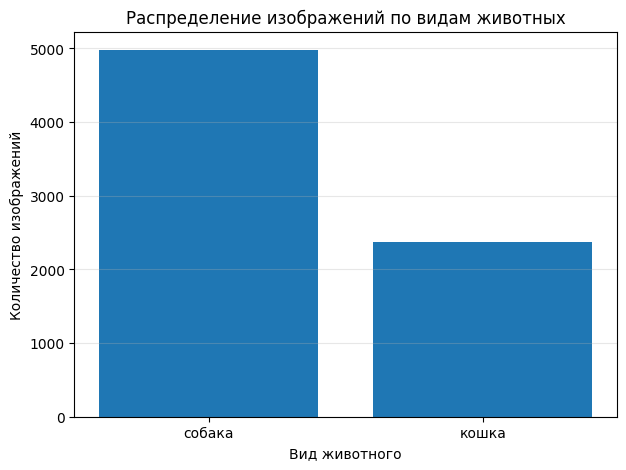

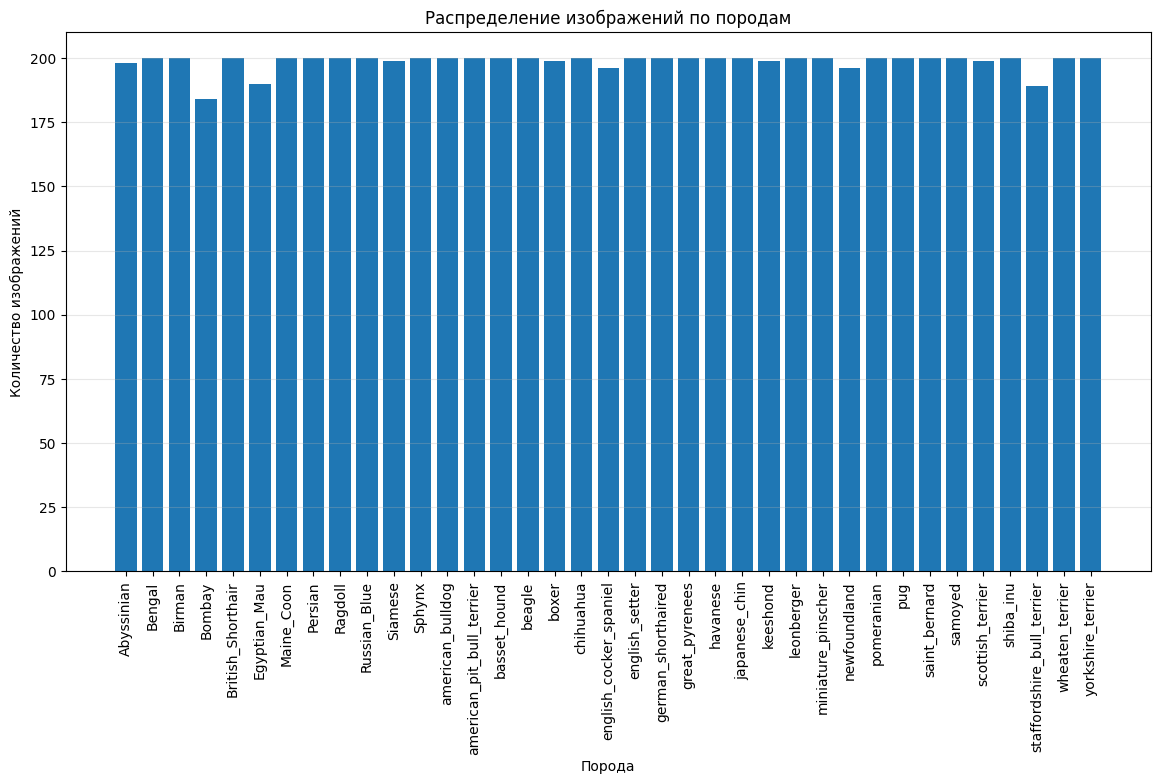

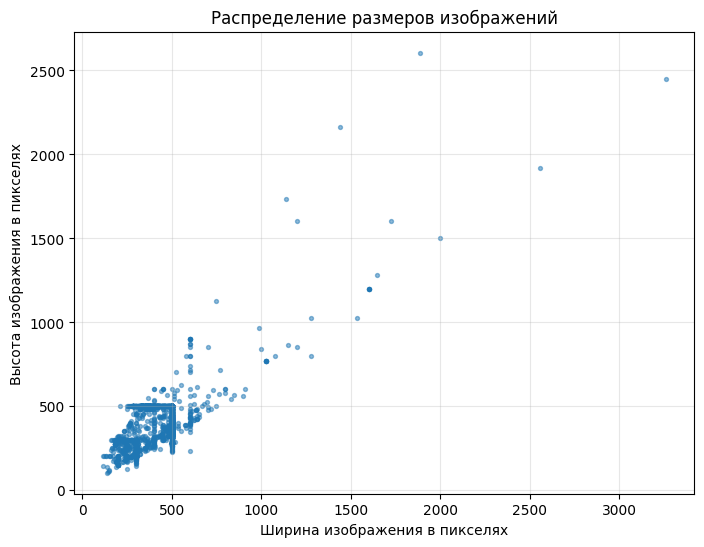

Рисунки сохранены:
/content/image_generation_processing_project/results/figures/species_distribution.png
/content/image_generation_processing_project/results/figures/breed_distribution.png
/content/image_generation_processing_project/results/figures/image_size_distribution.png


In [10]:
# Создаем каталог для рисунков.
figures_dir = RESULTS_DIR / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# Строим рисунок с распределением изображений по видам животных.
plt.figure(figsize=(7, 5))
plt.bar(
    species_distribution["species_name_ru"],
    species_distribution["image_count"]
)
plt.title("Распределение изображений по видам животных")
plt.xlabel("Вид животного")
plt.ylabel("Количество изображений")
plt.grid(axis="y", alpha=0.3)

species_figure_path = figures_dir / "species_distribution.png"
plt.savefig(species_figure_path, dpi=200, bbox_inches="tight")
plt.show()

# Строим рисунок с распределением изображений по породам.
# Для читаемости используем все породы, но поворачиваем подписи.
breed_for_plot = breed_distribution.sort_values("breed_name")

plt.figure(figsize=(14, 7))
plt.bar(
    breed_for_plot["breed_name"],
    breed_for_plot["image_count"]
)
plt.title("Распределение изображений по породам")
plt.xlabel("Порода")
plt.ylabel("Количество изображений")
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)

breed_figure_path = figures_dir / "breed_distribution.png"
plt.savefig(breed_figure_path, dpi=200, bbox_inches="tight")
plt.show()

# Строим рисунок с распределением ширины и высоты изображений.
plt.figure(figsize=(8, 6))
plt.scatter(
    data_table["width"],
    data_table["height"],
    s=8,
    alpha=0.5
)
plt.title("Распределение размеров изображений")
plt.xlabel("Ширина изображения в пикселях")
plt.ylabel("Высота изображения в пикселях")
plt.grid(alpha=0.3)

size_figure_path = figures_dir / "image_size_distribution.png"
plt.savefig(size_figure_path, dpi=200, bbox_inches="tight")
plt.show()

print("Рисунки сохранены:")
print(species_figure_path)
print(breed_figure_path)
print(size_figure_path)

In [11]:
# Проверяем значения, которые встречаются в масках сегментации.
# Маска сегментации хранит номер области для каждого пикселя.
# В данном наборе данных обычно используются три значения:
# 1 соответствует объекту
# 2 соответствует фону
# 3 соответствует границе объекта

sample_mask_paths = data_table["trimap_path"].sample(
    n=min(100, len(data_table)),
    random_state=SEED
).tolist()

unique_values = {}

for mask_path in sample_mask_paths:
    mask = Image.open(mask_path)
    mask_array = np.array(mask)

    for value in np.unique(mask_array):
        value = int(value)
        unique_values[value] = unique_values.get(value, 0) + 1

unique_values_path = metrics_dir / "mask_unique_values.json"

with open(unique_values_path, "w", encoding="utf-8") as file:
    json.dump(unique_values, file, ensure_ascii=False, indent=4)

print("Значения, найденные в проверенных масках:")
for value, count in sorted(unique_values.items()):
    print("Значение", value, "встретилось в", count, "масках")

print("Файл с проверкой значений масок сохранен:", unique_values_path)

Значения, найденные в проверенных масках:
Значение 1 встретилось в 100 масках
Значение 2 встретилось в 100 масках
Значение 3 встретилось в 100 масках
Файл с проверкой значений масок сохранен: /content/image_generation_processing_project/results/metrics/mask_unique_values.json


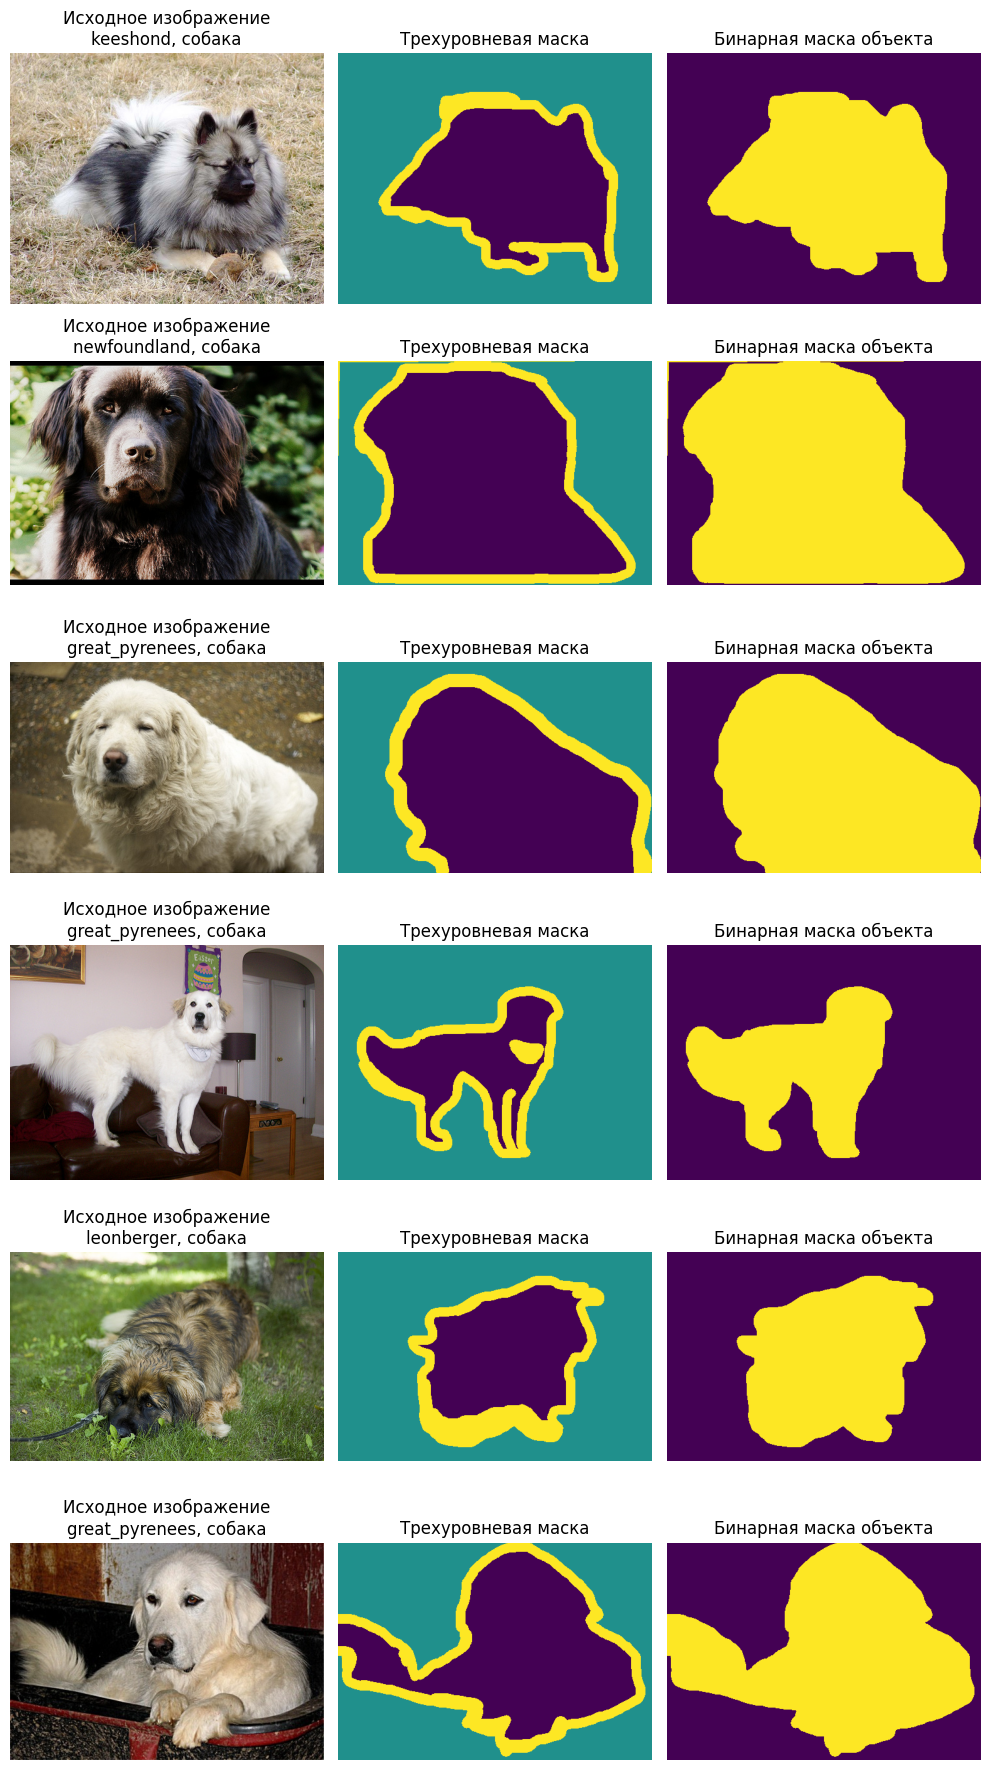

Сетка примеров сохранена: /content/image_generation_processing_project/results/examples/sample_images_and_masks.png


In [12]:
# Создаем наглядную сетку примеров.
# В каждой строке показывается исходное изображение, трехуровневая маска
# и бинарная маска объекта.
# Бинарная маска означает изображение из двух областей:
# объект и фон.

examples_dir = RESULTS_DIR / "examples"
examples_dir.mkdir(parents=True, exist_ok=True)

sample_rows = data_table.sample(
    n=min(6, len(data_table)),
    random_state=SEED
).reset_index(drop=True)

figure, axes = plt.subplots(
    nrows=len(sample_rows),
    ncols=3,
    figsize=(10, 3 * len(sample_rows))
)

if len(sample_rows) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_index, row in sample_rows.iterrows():
    image = Image.open(row["image_path"]).convert("RGB")
    trimap = Image.open(row["trimap_path"])

    image_array = np.array(image)
    trimap_array = np.array(trimap)

    # Создаем бинарную маску объекта.
    # Значения 1 и 3 относим к объекту, потому что значение 3 соответствует границе.
    object_mask = np.isin(trimap_array, [1, 3]).astype(np.uint8)

    axes[row_index, 0].imshow(image_array)
    axes[row_index, 0].set_title(
        "Исходное изображение\n" + row["breed_name"] + ", " + row["species_name_ru"]
    )
    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(trimap_array)
    axes[row_index, 1].set_title("Трехуровневая маска")
    axes[row_index, 1].axis("off")

    axes[row_index, 2].imshow(object_mask)
    axes[row_index, 2].set_title("Бинарная маска объекта")
    axes[row_index, 2].axis("off")

plt.tight_layout()

sample_grid_path = examples_dir / "sample_images_and_masks.png"
plt.savefig(sample_grid_path, dpi=200, bbox_inches="tight")
plt.show()

print("Сетка примеров сохранена:", sample_grid_path)

In [13]:
# Копируем результаты третьего этапа на Google Drive.
# Сохраняем таблицы, рисунки и примеры для дальнейшего использования в диссертации.

drive_metrics_dir = DRIVE_PROJECT_DIR / "metrics"
drive_figures_dir = DRIVE_PROJECT_DIR / "figures"
drive_examples_dir = DRIVE_PROJECT_DIR / "examples"

drive_metrics_dir.mkdir(parents=True, exist_ok=True)
drive_figures_dir.mkdir(parents=True, exist_ok=True)
drive_examples_dir.mkdir(parents=True, exist_ok=True)

files_to_copy = [
    species_distribution_path,
    breed_distribution_path,
    image_size_summary_path,
    image_area_summary_path,
    unique_values_path,
    species_figure_path,
    breed_figure_path,
    size_figure_path,
    sample_grid_path,
]

for source_path in files_to_copy:
    source_path = Path(source_path)

    if source_path.suffix == ".csv" or source_path.suffix == ".json":
        destination_path = drive_metrics_dir / source_path.name
    elif source_path.name.startswith("sample"):
        destination_path = drive_examples_dir / source_path.name
    else:
        destination_path = drive_figures_dir / source_path.name

    shutil.copy2(source_path, destination_path)
    print("Сохранено:", destination_path)

print("Результаты этапа 3 сохранены на Google Drive")

Сохранено: /content/drive/MyDrive/image_generation_processing_project/metrics/species_distribution.csv
Сохранено: /content/drive/MyDrive/image_generation_processing_project/metrics/breed_distribution.csv
Сохранено: /content/drive/MyDrive/image_generation_processing_project/metrics/image_size_summary.csv
Сохранено: /content/drive/MyDrive/image_generation_processing_project/metrics/image_area_summary.csv
Сохранено: /content/drive/MyDrive/image_generation_processing_project/metrics/mask_unique_values.json
Сохранено: /content/drive/MyDrive/image_generation_processing_project/figures/species_distribution.png
Сохранено: /content/drive/MyDrive/image_generation_processing_project/figures/breed_distribution.png
Сохранено: /content/drive/MyDrive/image_generation_processing_project/figures/image_size_distribution.png
Сохранено: /content/drive/MyDrive/image_generation_processing_project/examples/sample_images_and_masks.png
Результаты этапа 3 сохранены на Google Drive


Набор данных пригоден для дальнейшего обучения: все 7349 записей имеют изображения и маски, распределение по породам почти равномерное, а распределение по видам показывает ожидаемый перекос в сторону собак. Такой перекос не мешает задаче сегментации, потому что модель будет обучаться выделять объект на изображении, а не классифицировать вид животного. Для будущей диссертации это можно описать как преимущество набора: породы представлены сбалансированно, а изображения различаются по масштабу, позе, освещению и размеру, что соответствует официальному описанию Oxford-IIIT Pet.

График размеров подтверждает необходимость приведения изображений к единому размеру перед обучением. Большинство изображений находится в умеренном диапазоне, но встречаются крупные изображения до 3264 пикселей по ширине и 2606 пикселей по высоте. Значит, без предварительного изменения размера обучение будет нестабильным по памяти. Проверка масок также выполнена правильно: в масках присутствуют значения 1, 2 и 3, что соответствует трехуровневой разметке объекта, фона и границы. Для обучения сегментации будет сформирована бинарная маска, где объект и его граница объединяются в одну область.

# 4. Формирование разбиения данных для задачи сегментации

На четвертом этапе набор изображений разделяется на обучающую, проверочную и контрольную части. Обучающая часть будет использоваться для настройки параметров нейросетевой модели, проверочная часть нужна для контроля качества во время обучения, а контрольная часть останется закрытой до финальной оценки. Такой порядок позволяет избежать завышенной оценки качества модели и делает эксперимент воспроизводимым.

Для сегментации формируется отдельная таблица с путями к изображениям и маскам. Трехуровневая маска преобразуется в бинарную маску: пиксели объекта и его границы объединяются в одну область, а фон остается отдельной областью. Такое преобразование соответствует задаче будущего приложения, где требуется отделить основной объект изображения от фона и затем использовать выделенную область для восстановления или дальнейшей обработки.

In [14]:
# Загружаем таблицу с описанием набора данных.
# Эта таблица была создана на этапе загрузки и проверена на этапе первичного анализа.
manifest_path = RESULTS_DIR / "metrics" / "dataset_manifest.csv"

if not manifest_path.exists():
    raise FileNotFoundError(
        "Не найдена таблица с описанием данных. Необходимо выполнить предыдущие этапы."
    )

data_table = pd.read_csv(manifest_path)

# Оставляем только записи, где существуют изображение и маска.
# Это защищает дальнейшие этапы от ошибок чтения файлов.
data_table = data_table[
    (data_table["image_exists"] == True) &
    (data_table["trimap_exists"] == True)
].reset_index(drop=True)

# Проверяем, что после очистки данные не исчезли.
if len(data_table) == 0:
    raise ValueError("После проверки не осталось пригодных записей.")

# Проверяем наличие путей к файлам на диске.
missing_images = []
missing_masks = []

for image_path, mask_path in zip(data_table["image_path"], data_table["trimap_path"]):
    if not Path(image_path).exists():
        missing_images.append(image_path)
    if not Path(mask_path).exists():
        missing_masks.append(mask_path)

if missing_images:
    raise FileNotFoundError(
        "Обнаружены отсутствующие изображения. Первый пример: " + missing_images[0]
    )

if missing_masks:
    raise FileNotFoundError(
        "Обнаружены отсутствующие маски. Первый пример: " + missing_masks[0]
    )

print("Исходная таблица загружена")
print("Количество пригодных записей:", len(data_table))
print("Количество пород:", data_table["breed_name"].nunique())
print("Количество видов животных:", data_table["species_name_ru"].nunique())

Исходная таблица загружена
Количество пригодных записей: 7349
Количество пород: 37
Количество видов животных: 2


In [15]:
# Импортируем средство для разбиения таблицы.
# Разбиение выполняется с сохранением распределения пород.
# Это нужно, чтобы в каждой части набора были представлены разные породы животных.
from sklearn.model_selection import train_test_split

# Задаем доли частей набора.
# Обучающая часть используется для настройки модели.
# Проверочная часть используется для контроля качества во время обучения.
# Контрольная часть используется только для итоговой проверки.
train_fraction = 0.70
validation_fraction = 0.15
test_fraction = 0.15

# Сначала отделяем обучающую часть.
# Стратификация означает сохранение близкого распределения пород в разных частях.
train_table, temp_table = train_test_split(
    data_table,
    test_size=(validation_fraction + test_fraction),
    random_state=SEED,
    stratify=data_table["breed_name"]
)

# Затем делим оставшуюся часть на проверочную и контрольную.
# Так как оставшаяся часть составляет 30 процентов, ее деление пополам дает 15 и 15 процентов.
validation_table, test_table = train_test_split(
    temp_table,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_table["breed_name"]
)

# Добавляем название части набора.
train_table = train_table.copy()
validation_table = validation_table.copy()
test_table = test_table.copy()

train_table["data_part"] = "обучающая"
validation_table["data_part"] = "проверочная"
test_table["data_part"] = "контрольная"

# Объединяем таблицы в одну.
split_table = pd.concat(
    [train_table, validation_table, test_table],
    ignore_index=True
)

# Перемешиваем строки для удобства просмотра.
split_table = split_table.sample(
    frac=1.0,
    random_state=SEED
).reset_index(drop=True)

# Сохраняем таблицу разбиения.
split_manifest_path = RESULTS_DIR / "metrics" / "segmentation_split_manifest.csv"
split_table.to_csv(split_manifest_path, index=False, encoding="utf-8")

# Формируем сводку по частям набора.
split_summary = (
    split_table
    .groupby("data_part")
    .agg(
        image_count=("image_id", "count"),
        breed_count=("breed_name", "nunique"),
        species_count=("species_name_ru", "nunique")
    )
    .reset_index()
)

split_summary_path = RESULTS_DIR / "metrics" / "segmentation_split_summary.csv"
split_summary.to_csv(split_summary_path, index=False, encoding="utf-8")

print("Разбиение данных выполнено")
display(split_summary)

print("Файл с разбиением сохранен:", split_manifest_path)
print("Файл со сводкой сохранен:", split_summary_path)

Разбиение данных выполнено


,data_part,image_count,breed_count,species_count
0,контрольная,1103,37,2
1,обучающая,5144,37,2
2,проверочная,1102,37,2


Файл с разбиением сохранен: /content/image_generation_processing_project/results/metrics/segmentation_split_manifest.csv
Файл со сводкой сохранен: /content/image_generation_processing_project/results/metrics/segmentation_split_summary.csv


In [16]:
# Проверяем, что в каждой части набора представлены все породы.
# Это особенно важно для честной оценки модели.
breed_part_table = (
    split_table
    .groupby(["data_part", "breed_name"])
    .size()
    .reset_index(name="image_count")
)

# Сохраняем подробную таблицу распределения пород.
breed_part_path = RESULTS_DIR / "metrics" / "breed_distribution_by_part.csv"
breed_part_table.to_csv(breed_part_path, index=False, encoding="utf-8")

# Строим сводную таблицу для просмотра.
breed_pivot = breed_part_table.pivot(
    index="breed_name",
    columns="data_part",
    values="image_count"
).fillna(0).astype(int)

# Проверяем, есть ли породы, отсутствующие в какой-либо части.
missing_breed_distribution = breed_pivot[
    (breed_pivot == 0).any(axis=1)
]

print("Распределение первых десяти пород по частям набора:")
display(breed_pivot.head(10))

if len(missing_breed_distribution) == 0:
    print("Все породы представлены в каждой части набора")
else:
    print("Обнаружены породы, отсутствующие в одной из частей набора")
    display(missing_breed_distribution)

print("Подробная таблица распределения пород сохранена:", breed_part_path)

Распределение первых десяти пород по частям набора:


data_part,контрольная,обучающая,проверочная
breed_name,,,
Abyssinian,30,139,29
Bengal,30,140,30
Birman,30,140,30
Bombay,27,129,28
British_Shorthair,30,140,30
Egyptian_Mau,28,133,29
Maine_Coon,30,140,30
Persian,30,140,30
Ragdoll,30,140,30


Все породы представлены в каждой части набора
Подробная таблица распределения пород сохранена: /content/image_generation_processing_project/results/metrics/breed_distribution_by_part.csv


In [17]:
# Описываем функцию преобразования маски.
# В исходной трехуровневой маске:
# значение 1 соответствует объекту
# значение 2 соответствует фону
# значение 3 соответствует границе объекта
#
# В бинарной маске:
# значение 1 означает объект вместе с границей
# значение 0 означает фон
def convert_trimap_to_binary_mask(trimap_image):
    # Преобразуем изображение маски в числовой массив.
    trimap_array = np.array(trimap_image)

    # Объединяем объект и его границу.
    # Это важно для будущего приложения, где объект должен выделяться целиком.
    binary_mask = np.isin(trimap_array, [1, 3]).astype(np.uint8)

    return binary_mask

# Проверяем функцию на одном примере.
example_row = split_table.iloc[0]

example_image = Image.open(example_row["image_path"]).convert("RGB")
example_trimap = Image.open(example_row["trimap_path"])

example_binary_mask = convert_trimap_to_binary_mask(example_trimap)

print("Проверка преобразования маски")
print("Размер изображения:", example_image.size)
print("Размер исходной маски:", example_trimap.size)
print("Размер бинарной маски:", example_binary_mask.shape)
print("Уникальные значения бинарной маски:", sorted(np.unique(example_binary_mask).tolist()))

Проверка преобразования маски
Размер изображения: (500, 333)
Размер исходной маски: (500, 333)
Размер бинарной маски: (333, 500)
Уникальные значения бинарной маски: [0, 1]


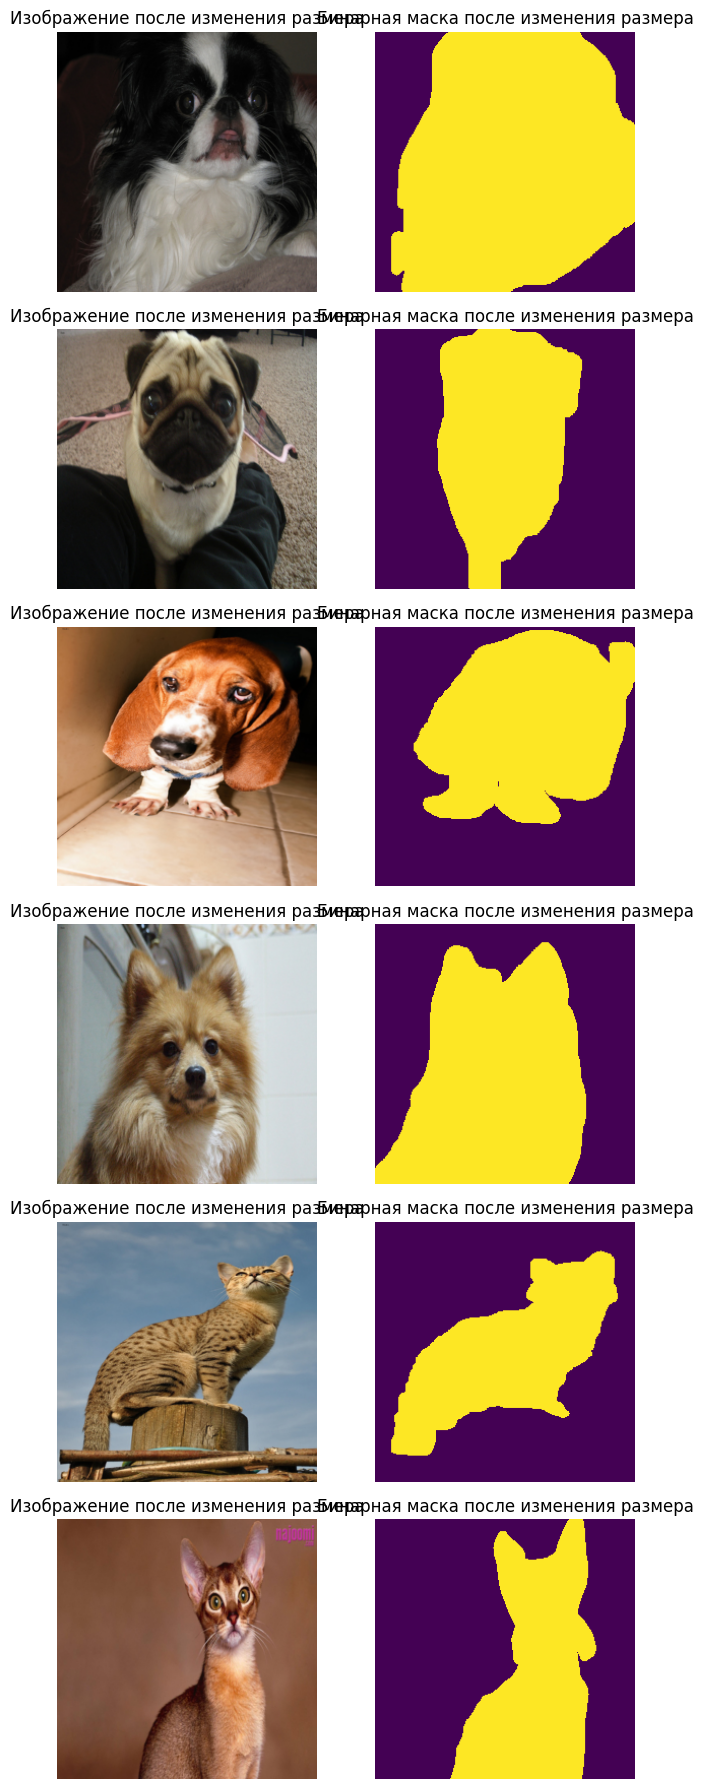

Проверочный рисунок сохранен: /content/image_generation_processing_project/results/examples/segmentation_resize_check.png


In [18]:
# Задаем единый размер входа модели.
# Размер 256 на 256 является компромиссом между качеством деталей и расходом памяти.
IMAGE_SIZE = 256

# Описываем функцию подготовки одной пары изображение-маска.
# Изображение изменяется обычным способом.
# Маска изменяется способом ближайшего соседа, чтобы не появились промежуточные значения.
def prepare_segmentation_pair(image_path, mask_path, image_size=IMAGE_SIZE):
    image = Image.open(image_path).convert("RGB")
    trimap = Image.open(mask_path)

    binary_mask = convert_trimap_to_binary_mask(trimap)

    # Изменяем размер исходного изображения.
    image_resized = image.resize(
        (image_size, image_size),
        resample=Image.Resampling.BILINEAR
    )

    # Изменяем размер маски.
    # Ближайший сосед сохраняет только значения 0 и 1.
    mask_image = Image.fromarray((binary_mask * 255).astype(np.uint8))
    mask_resized = mask_image.resize(
        (image_size, image_size),
        resample=Image.Resampling.NEAREST
    )

    # Возвращаем подготовленные массивы.
    image_array = np.array(image_resized)
    mask_array = (np.array(mask_resized) > 127).astype(np.uint8)

    return image_array, mask_array

# Проверяем подготовку на нескольких примерах.
sample_for_resize = split_table.sample(
    n=6,
    random_state=SEED
).reset_index(drop=True)

figure, axes = plt.subplots(
    nrows=len(sample_for_resize),
    ncols=2,
    figsize=(7, 3 * len(sample_for_resize))
)

if len(sample_for_resize) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_index, row in sample_for_resize.iterrows():
    image_array, mask_array = prepare_segmentation_pair(
        row["image_path"],
        row["trimap_path"],
        image_size=IMAGE_SIZE
    )

    axes[row_index, 0].imshow(image_array)
    axes[row_index, 0].set_title("Изображение после изменения размера")
    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(mask_array)
    axes[row_index, 1].set_title("Бинарная маска после изменения размера")
    axes[row_index, 1].axis("off")

plt.tight_layout()

resize_check_path = RESULTS_DIR / "examples" / "segmentation_resize_check.png"
plt.savefig(resize_check_path, dpi=200, bbox_inches="tight")
plt.show()

print("Проверочный рисунок сохранен:", resize_check_path)

In [19]:
# Создаем файл с настройками задачи сегментации.
# Этот файл понадобится для обучения модели и для будущего пользовательского приложения.
segmentation_config = {
    "task_name": "segmentation",
    "task_name_ru": "выделение объекта на изображении",
    "image_size": IMAGE_SIZE,
    "mask_values_source": {
        "1": "объект",
        "2": "фон",
        "3": "граница объекта"
    },
    "mask_values_binary": {
        "0": "фон",
        "1": "объект и граница объекта"
    },
    "split_file": str(split_manifest_path),
    "train_fraction": train_fraction,
    "validation_fraction": validation_fraction,
    "test_fraction": test_fraction,
    "random_seed": SEED,
    "scientific_novelty_note": (
        "Разбиение фиксирует единые условия для сравнения моделей сегментации, "
        "восстановления и генерации изображений. Это позволяет оценивать разные "
        "способы нейросетевой обработки на единой базе изображений."
    )
}

segmentation_config_path = RESULTS_DIR / "reports" / "segmentation_config.json"

with open(segmentation_config_path, "w", encoding="utf-8") as file:
    json.dump(segmentation_config, file, ensure_ascii=False, indent=4)

print("Файл настроек задачи сегментации сохранен:", segmentation_config_path)

# Выводим настройки на экран для контроля.
for key, value in segmentation_config.items():
    print(key, ":", value)

Файл настроек задачи сегментации сохранен: /content/image_generation_processing_project/results/reports/segmentation_config.json
task_name : segmentation
task_name_ru : выделение объекта на изображении
image_size : 256
mask_values_source : {'1': 'объект', '2': 'фон', '3': 'граница объекта'}
mask_values_binary : {'0': 'фон', '1': 'объект и граница объекта'}
split_file : /content/image_generation_processing_project/results/metrics/segmentation_split_manifest.csv
train_fraction : 0.7
validation_fraction : 0.15
test_fraction : 0.15
random_seed : 42
scientific_novelty_note : Разбиение фиксирует единые условия для сравнения моделей сегментации, восстановления и генерации изображений. Это позволяет оценивать разные способы нейросетевой обработки на единой базе изображений.


In [20]:
# Копируем результаты этапа на Google Drive.
# Сохраняются таблицы разбиения, настройки и проверочный рисунок.
drive_metrics_dir = DRIVE_PROJECT_DIR / "metrics"
drive_reports_dir = DRIVE_PROJECT_DIR / "reports"
drive_examples_dir = DRIVE_PROJECT_DIR / "examples"

drive_metrics_dir.mkdir(parents=True, exist_ok=True)
drive_reports_dir.mkdir(parents=True, exist_ok=True)
drive_examples_dir.mkdir(parents=True, exist_ok=True)

files_to_copy = [
    split_manifest_path,
    split_summary_path,
    breed_part_path,
    segmentation_config_path,
    resize_check_path,
]

for source_path in files_to_copy:
    source_path = Path(source_path)

    if source_path.suffix == ".csv":
        destination_path = drive_metrics_dir / source_path.name
    elif source_path.suffix == ".json":
        destination_path = drive_reports_dir / source_path.name
    else:
        destination_path = drive_examples_dir / source_path.name

    shutil.copy2(source_path, destination_path)
    print("Сохранено:", destination_path)

print("Результаты этапа 4 сохранены на Google Drive")

Сохранено: /content/drive/MyDrive/image_generation_processing_project/metrics/segmentation_split_manifest.csv
Сохранено: /content/drive/MyDrive/image_generation_processing_project/metrics/segmentation_split_summary.csv
Сохранено: /content/drive/MyDrive/image_generation_processing_project/metrics/breed_distribution_by_part.csv
Сохранено: /content/drive/MyDrive/image_generation_processing_project/reports/segmentation_config.json
Сохранено: /content/drive/MyDrive/image_generation_processing_project/examples/segmentation_resize_check.png
Результаты этапа 4 сохранены на Google Drive


Разбиение выполнено корректно: обучающая часть содержит 5144 изображения, проверочная — 1102 изображения, контрольная — 1103 изображения. Все 37 пород представлены в каждой части, поэтому дальнейшее сравнение моделей будет проводиться в устойчивых условиях, без выпадения отдельных пород из проверки или итогового контроля.

Преобразование масок также выполнено правильно: бинарная маска содержит только значения 0 и 1. Небольшое наложение заголовков на проверочном рисунке является только оформительской проблемой и не влияет на качество данных. На следующем этапе создается программный набор данных и загрузчики данных для обучения. В PyTorch такая схема является стандартной: объект Dataset хранит образцы и ответы, а DataLoader подает данные модели небольшими частями во время обучения. Для задачи сегментации важно применять согласованные преобразования к изображению и маске, поскольку изображение и пиксельная разметка должны оставаться геометрически совпадающими.

# 5. Создание загрузчиков данных для обучения модели сегментации

На пятом этапе создается программный набор данных для задачи сегментации. Каждая запись набора содержит исходное изображение, бинарную маску объекта и служебные сведения об изображении. Изображение и маска приводятся к единому размеру, затем преобразуются в тензоры. Тензор представляет собой многомерный числовой массив, с которым работает нейросетевая модель.

Научная новизна эксперимента поддерживается за счет единого конвейера подготовки данных. Один и тот же набор изображений будет использоваться для нескольких связанных задач: выделения объекта, восстановления качества изображения и генерации новых изображений. Поэтому на данном этапе особенно важно обеспечить воспроизводимую подачу данных, чтобы последующее сравнение моделей было выполнено в одинаковых условиях.

In [21]:
# Импортируем библиотеки, необходимые для подготовки данных к обучению.
# Класс Dataset используется для описания набора данных.
# Класс DataLoader используется для подачи данных модели небольшими частями.
from torch.utils.data import Dataset, DataLoader

# Импортируем средства для работы с изображениями и числами.
from PIL import Image
import numpy as np
import pandas as pd
import torch
import random
import json
import shutil
from pathlib import Path
import matplotlib.pyplot as plt

# Указываем путь к таблице разбиения, созданной на предыдущем этапе.
split_manifest_path = RESULTS_DIR / "metrics" / "segmentation_split_manifest.csv"

if not split_manifest_path.exists():
    raise FileNotFoundError(
        "Не найдена таблица разбиения. Необходимо сначала выполнить этап 4."
    )

# Загружаем таблицу разбиения.
split_table = pd.read_csv(split_manifest_path)

# Проверяем наличие обязательных столбцов.
required_columns = [
    "image_id",
    "image_path",
    "trimap_path",
    "breed_name",
    "species_name_ru",
    "data_part",
]

missing_columns = [
    column for column in required_columns
    if column not in split_table.columns
]

if missing_columns:
    raise ValueError(
        "В таблице разбиения отсутствуют обязательные столбцы: " + ", ".join(missing_columns)
    )

# Проверяем количество строк в каждой части.
part_counts = split_table["data_part"].value_counts().reset_index()
part_counts.columns = ["часть_набора", "количество_изображений"]

print("Таблица разбиения загружена")
display(part_counts)

# Проверяем существование файлов изображений и масок.
missing_files = []

for row in split_table.itertuples(index=False):
    if not Path(row.image_path).exists():
        missing_files.append(row.image_path)
    if not Path(row.trimap_path).exists():
        missing_files.append(row.trimap_path)

if missing_files:
    raise FileNotFoundError(
        "Обнаружены отсутствующие файлы. Первый пример: " + missing_files[0]
    )

print("Проверка файлов завершена")
print("Все изображения и маски найдены")

Таблица разбиения загружена


,часть_набора,количество_изображений
0,обучающая,5144
1,контрольная,1103
2,проверочная,1102


Проверка файлов завершена
Все изображения и маски найдены


In [22]:
# Задаем единый размер изображения.
# Этот размер уже был сохранен в настройках задачи сегментации.
IMAGE_SIZE = 256

# Средние значения и отклонения используются для приведения яркости каналов к единому масштабу.
# Канал означает одну составляющую цвета изображения.
# Используются распространенные значения для изображений, на которых часто обучаются сверточные модели.
IMAGE_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGE_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

# Описываем функцию преобразования трехуровневой маски в бинарную.
# Значение 1 соответствует объекту.
# Значение 2 соответствует фону.
# Значение 3 соответствует границе объекта.
# Для задачи выделения объекта значения 1 и 3 объединяются.
def convert_trimap_to_binary_mask(trimap_image):
    trimap_array = np.array(trimap_image)
    binary_mask = np.isin(trimap_array, [1, 3]).astype(np.uint8)
    return binary_mask

# Описываем класс набора данных для сегментации.
# Каждый вызов по номеру возвращает одно подготовленное изображение и одну маску.
class PetSegmentationDataset(Dataset):
    def __init__(
        self,
        table,
        image_size=256,
        use_augmentation=False,
        image_mean=None,
        image_std=None,
    ):
        # Сохраняем таблицу с путями к изображениям и маскам.
        self.table = table.reset_index(drop=True).copy()

        # Сохраняем размер, к которому будут приводиться изображения и маски.
        self.image_size = image_size

        # Сохраняем признак использования дополнения данных.
        # Дополнение данных означает случайное изменение изображения во время обучения.
        self.use_augmentation = use_augmentation

        # Сохраняем значения для нормализации изображения.
        # Нормализация означает приведение чисел к удобному диапазону для обучения модели.
        self.image_mean = image_mean if image_mean is not None else IMAGE_MEAN
        self.image_std = image_std if image_std is not None else IMAGE_STD

    def __len__(self):
        # Возвращаем количество записей в наборе.
        return len(self.table)

    def __getitem__(self, index):
        # Получаем одну строку таблицы.
        row = self.table.iloc[index]

        # Загружаем исходное изображение.
        image = Image.open(row["image_path"]).convert("RGB")

        # Загружаем трехуровневую маску.
        trimap = Image.open(row["trimap_path"])

        # Преобразуем трехуровневую маску в бинарную.
        binary_mask = convert_trimap_to_binary_mask(trimap)

        # Изменяем размер изображения.
        # Для изображения используется сглаженное изменение размера.
        image = image.resize(
            (self.image_size, self.image_size),
            resample=Image.Resampling.BILINEAR
        )

        # Изменяем размер маски.
        # Для маски используется ближайший сосед, чтобы сохранить только значения 0 и 1.
        mask_image = Image.fromarray((binary_mask * 255).astype(np.uint8))
        mask_image = mask_image.resize(
            (self.image_size, self.image_size),
            resample=Image.Resampling.NEAREST
        )

        # Переводим изображение и маску в числовые массивы.
        image_array = np.array(image).astype(np.float32) / 255.0
        mask_array = (np.array(mask_image) > 127).astype(np.float32)

        # Применяем случайное горизонтальное отражение только для обучающей части.
        # Отражение выполняется одновременно для изображения и маски.
        if self.use_augmentation and random.random() < 0.5:
            image_array = np.ascontiguousarray(image_array[:, ::-1, :])
            mask_array = np.ascontiguousarray(mask_array[:, ::-1])

        # Применяем небольшое случайное изменение яркости только для обучающей части.
        # Маска при этом не меняется, потому что геометрия объекта остается прежней.
        if self.use_augmentation and random.random() < 0.5:
            brightness_factor = random.uniform(0.85, 1.15)
            image_array = np.clip(image_array * brightness_factor, 0.0, 1.0)

        # Нормализуем изображение.
        image_array = (image_array - self.image_mean) / self.image_std

        # Меняем порядок осей изображения.
        # Было высота, ширина, каналы.
        # Стало каналы, высота, ширина, потому что такой порядок ожидает PyTorch.
        image_tensor = torch.from_numpy(image_array.transpose(2, 0, 1)).float()

        # Добавляем измерение канала к маске.
        # Маска имеет один канал: объект или фон.
        mask_tensor = torch.from_numpy(mask_array[None, :, :]).float()

        # Возвращаем словарь с данными.
        sample = {
            "image": image_tensor,
            "mask": mask_tensor,
            "image_id": row["image_id"],
            "breed_name": row["breed_name"],
            "species_name_ru": row["species_name_ru"],
            "data_part": row["data_part"],
        }

        return sample

print("Класс набора данных для сегментации создан")

Класс набора данных для сегментации создан


In [23]:
# Разделяем таблицу на три части.
train_table = split_table[split_table["data_part"] == "обучающая"].reset_index(drop=True)
validation_table = split_table[split_table["data_part"] == "проверочная"].reset_index(drop=True)
test_table = split_table[split_table["data_part"] == "контрольная"].reset_index(drop=True)

# Создаем наборы данных.
# Для обучающей части включается дополнение данных.
# Для проверочной и контрольной частей дополнение данных не используется.
train_dataset = PetSegmentationDataset(
    table=train_table,
    image_size=IMAGE_SIZE,
    use_augmentation=True,
    image_mean=IMAGE_MEAN,
    image_std=IMAGE_STD,
)

validation_dataset = PetSegmentationDataset(
    table=validation_table,
    image_size=IMAGE_SIZE,
    use_augmentation=False,
    image_mean=IMAGE_MEAN,
    image_std=IMAGE_STD,
)

test_dataset = PetSegmentationDataset(
    table=test_table,
    image_size=IMAGE_SIZE,
    use_augmentation=False,
    image_mean=IMAGE_MEAN,
    image_std=IMAGE_STD,
)

# Задаем размер пакета.
# Пакет означает несколько изображений, которые одновременно подаются модели.
# Для Tesla T4 размер 8 является безопасным вариантом для первых опытов.
BATCH_SIZE = 8

# Задаем число дополнительных процессов для загрузки данных.
# Если в среде возникнут проблемы с загрузкой, значение можно заменить на 0.
NUM_WORKERS = 2 if DEVICE == "cuda" else 0

# Создаем загрузчики данных.
# Обучающая часть перемешивается, чтобы модель не запоминала порядок изображений.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
    drop_last=True,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
    drop_last=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
    drop_last=False,
)

print("Наборы данных и загрузчики созданы")
print("Размер обучающей части:", len(train_dataset))
print("Размер проверочной части:", len(validation_dataset))
print("Размер контрольной части:", len(test_dataset))
print("Размер пакета:", BATCH_SIZE)
print("Число дополнительных процессов загрузки:", NUM_WORKERS)
print("Количество пакетов в обучающей части:", len(train_loader))
print("Количество пакетов в проверочной части:", len(validation_loader))
print("Количество пакетов в контрольной части:", len(test_loader))

Наборы данных и загрузчики созданы
Размер обучающей части: 5144
Размер проверочной части: 1102
Размер контрольной части: 1103
Размер пакета: 8
Число дополнительных процессов загрузки: 2
Количество пакетов в обучающей части: 643
Количество пакетов в проверочной части: 138
Количество пакетов в контрольной части: 138


In [24]:
# Получаем один пакет из обучающего загрузчика.
train_batch = next(iter(train_loader))

# Извлекаем изображения и маски.
batch_images = train_batch["image"]
batch_masks = train_batch["mask"]

# Проверяем размеры тензоров.
print("Размер пакета изображений:", tuple(batch_images.shape))
print("Размер пакета масок:", tuple(batch_masks.shape))

# Проверяем типы данных.
print("Тип данных изображений:", batch_images.dtype)
print("Тип данных масок:", batch_masks.dtype)

# Проверяем числовые диапазоны.
# После нормализации значения изображения могут быть меньше 0 и больше 1.
print("Минимальное значение изображения:", float(batch_images.min()))
print("Максимальное значение изображения:", float(batch_images.max()))

# Маска должна содержать только 0 и 1.
unique_mask_values = torch.unique(batch_masks).detach().cpu().numpy().tolist()
print("Уникальные значения маски:", unique_mask_values)

# Рассчитываем долю пикселей объекта в пакете.
# Этот показатель помогает понять, не являются ли маски пустыми.
object_pixel_share = float(batch_masks.mean())
print("Средняя доля пикселей объекта в пакете:", round(object_pixel_share, 4))

if set(unique_mask_values).issubset({0.0, 1.0}):
    print("Маски имеют корректный бинарный вид")
else:
    raise ValueError("В масках обнаружены значения, отличные от 0 и 1")

if object_pixel_share <= 0.0 or object_pixel_share >= 1.0:
    raise ValueError("Пакет содержит некорректные маски: объект отсутствует или занимает все изображение")

print("Проверка пакета данных завершена успешно")

Размер пакета изображений: (8, 3, 256, 256)
Размер пакета масок: (8, 1, 256, 256)
Тип данных изображений: torch.float32
Тип данных масок: torch.float32
Минимальное значение изображения: -2.1179039478302
Максимальное значение изображения: 2.640000104904175
Уникальные значения маски: [0.0, 1.0]
Средняя доля пикселей объекта в пакете: 0.4495
Маски имеют корректный бинарный вид
Проверка пакета данных завершена успешно


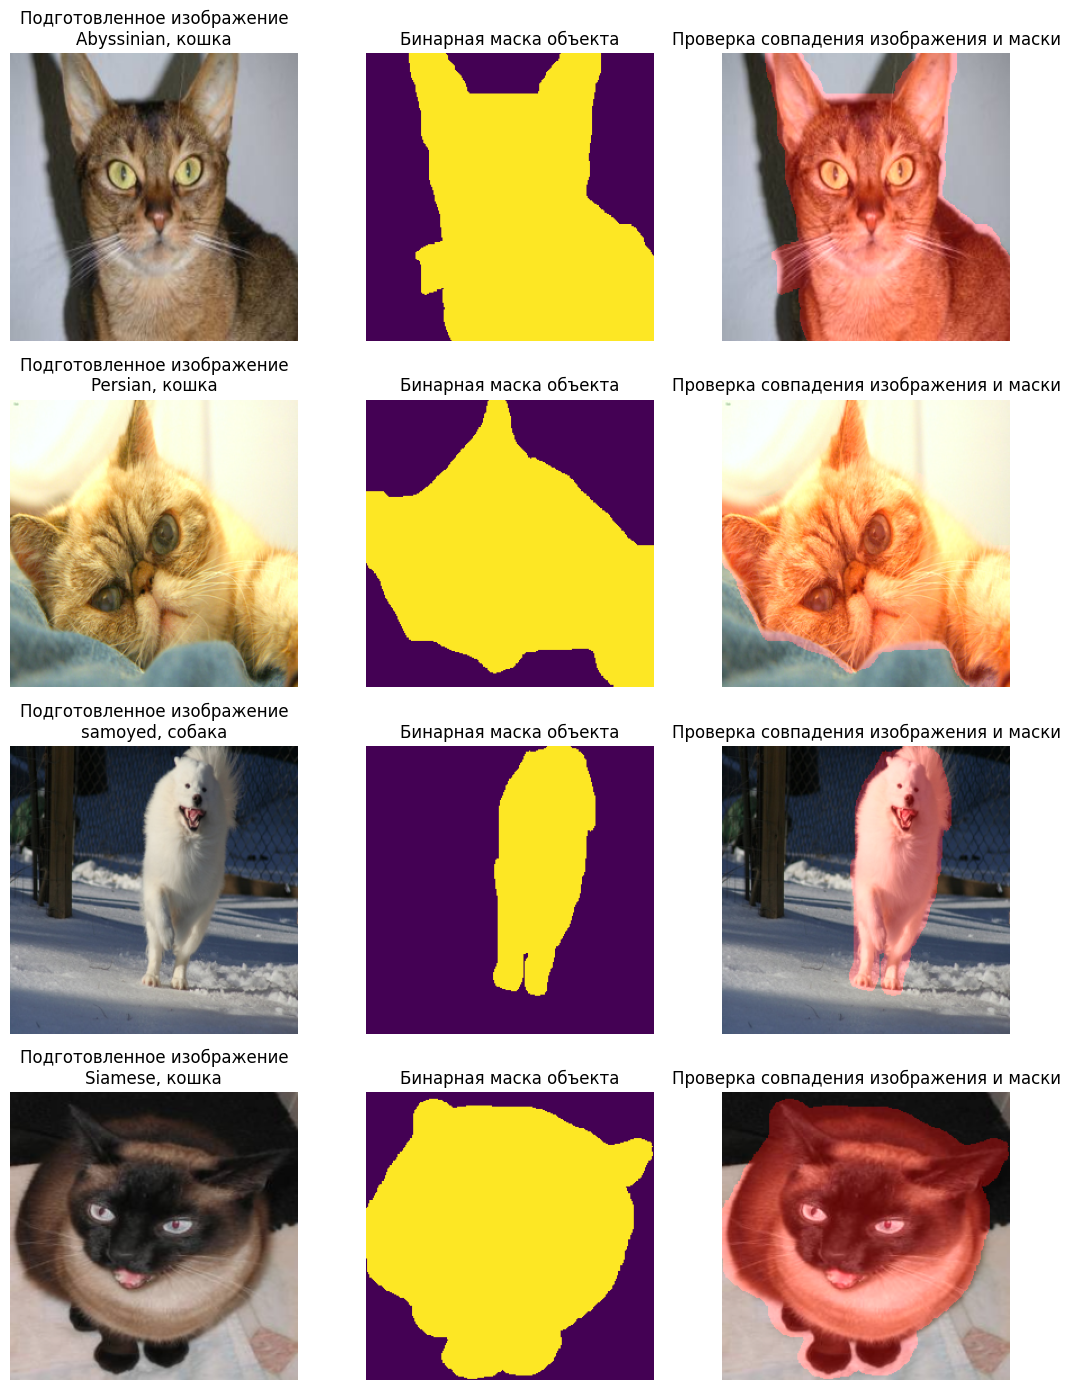

Рисунок проверки загрузчика сохранен: /content/image_generation_processing_project/results/examples/segmentation_dataloader_check.png


In [25]:
# Описываем функцию обратного преобразования изображения для показа.
# Она возвращает изображение из нормализованного вида к обычному диапазону от 0 до 1.
def denormalize_image(image_tensor, image_mean=IMAGE_MEAN, image_std=IMAGE_STD):
    image_array = image_tensor.detach().cpu().numpy()
    image_array = image_array.transpose(1, 2, 0)
    image_array = image_array * image_std + image_mean
    image_array = np.clip(image_array, 0.0, 1.0)
    return image_array

# Создаем рисунок с примерами из одного пакета.
# Показываются исходные изображения после подготовки и соответствующие маски.
samples_to_show = min(4, batch_images.shape[0])

figure, axes = plt.subplots(
    nrows=samples_to_show,
    ncols=3,
    figsize=(11, 3.5 * samples_to_show)
)

if samples_to_show == 1:
    axes = np.expand_dims(axes, axis=0)

for index in range(samples_to_show):
    image_for_show = denormalize_image(batch_images[index])
    mask_for_show = batch_masks[index, 0].detach().cpu().numpy()

    # Создаем изображение с наложением маски.
    # Наложение помогает визуально проверить совпадение объекта и разметки.
    overlay = image_for_show.copy()
    overlay[:, :, 0] = np.clip(overlay[:, :, 0] + mask_for_show * 0.35, 0.0, 1.0)

    title_text = (
        str(train_batch["breed_name"][index]) +
        ", " +
        str(train_batch["species_name_ru"][index])
    )

    axes[index, 0].imshow(image_for_show)
    axes[index, 0].set_title("Подготовленное изображение\n" + title_text)
    axes[index, 0].axis("off")

    axes[index, 1].imshow(mask_for_show)
    axes[index, 1].set_title("Бинарная маска объекта")
    axes[index, 1].axis("off")

    axes[index, 2].imshow(overlay)
    axes[index, 2].set_title("Проверка совпадения изображения и маски")
    axes[index, 2].axis("off")

plt.tight_layout()

dataloader_check_path = RESULTS_DIR / "examples" / "segmentation_dataloader_check.png"
plt.savefig(dataloader_check_path, dpi=200, bbox_inches="tight")
plt.show()

print("Рисунок проверки загрузчика сохранен:", dataloader_check_path)

In [26]:
# Создаем файл с настройками загрузки данных.
# Он потребуется для обучения модели и для будущего переноса решения в приложение.
dataloader_config = {
    "task_name": "segmentation",
    "task_name_ru": "выделение объекта на изображении",
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "train_size": len(train_dataset),
    "validation_size": len(validation_dataset),
    "test_size": len(test_dataset),
    "train_batches": len(train_loader),
    "validation_batches": len(validation_loader),
    "test_batches": len(test_loader),
    "image_mean": IMAGE_MEAN.tolist(),
    "image_std": IMAGE_STD.tolist(),
    "augmentation_for_train": [
        "случайное горизонтальное отражение",
        "небольшое случайное изменение яркости"
    ],
    "augmentation_for_validation_and_test": "не используется",
    "scientific_novelty_note": (
        "Данные подготовлены в едином формате для последующего сопоставления "
        "базовой и улучшенной моделей сегментации, а также для передачи масок "
        "в модуль восстановления качества изображения."
    )
}

dataloader_config_path = RESULTS_DIR / "reports" / "segmentation_dataloader_config.json"

with open(dataloader_config_path, "w", encoding="utf-8") as file:
    json.dump(dataloader_config, file, ensure_ascii=False, indent=4)

print("Настройки загрузки данных сохранены:", dataloader_config_path)

for key, value in dataloader_config.items():
    print(key, ":", value)

Настройки загрузки данных сохранены: /content/image_generation_processing_project/results/reports/segmentation_dataloader_config.json
task_name : segmentation
task_name_ru : выделение объекта на изображении
image_size : 256
batch_size : 8
num_workers : 2
train_size : 5144
validation_size : 1102
test_size : 1103
train_batches : 643
validation_batches : 138
test_batches : 138
image_mean : [0.48500001430511475, 0.4560000002384186, 0.4059999883174896]
image_std : [0.2290000021457672, 0.2240000069141388, 0.22499999403953552]
augmentation_for_train : ['случайное горизонтальное отражение', 'небольшое случайное изменение яркости']
augmentation_for_validation_and_test : не используется
scientific_novelty_note : Данные подготовлены в едином формате для последующего сопоставления базовой и улучшенной моделей сегментации, а также для передачи масок в модуль восстановления качества изображения.


In [27]:
# Копируем результаты этапа на Google Drive.
# Сохраняются настройки загрузки и рисунок проверки.
drive_reports_dir = DRIVE_PROJECT_DIR / "reports"
drive_examples_dir = DRIVE_PROJECT_DIR / "examples"

drive_reports_dir.mkdir(parents=True, exist_ok=True)
drive_examples_dir.mkdir(parents=True, exist_ok=True)

files_to_copy = [
    dataloader_config_path,
    dataloader_check_path,
]

for source_path in files_to_copy:
    source_path = Path(source_path)

    if source_path.suffix == ".json":
        destination_path = drive_reports_dir / source_path.name
    else:
        destination_path = drive_examples_dir / source_path.name

    shutil.copy2(source_path, destination_path)
    print("Сохранено:", destination_path)

print("Результаты этапа 5 сохранены на Google Drive")

Сохранено: /content/drive/MyDrive/image_generation_processing_project/reports/segmentation_dataloader_config.json
Сохранено: /content/drive/MyDrive/image_generation_processing_project/examples/segmentation_dataloader_check.png
Результаты этапа 5 сохранены на Google Drive


Загрузчики данных созданы правильно: изображения имеют форму (8, 3, 256, 256), маски имеют форму (8, 1, 256, 256), числовой тип соответствует обучению нейросетевой модели, а маски содержат только значения 0 и 1. Средняя доля пикселей объекта в пакете равна 0,4495, поэтому в проверенном пакете нет признаков пустых масок или полного заполнения изображения объектом.

Визуальная проверка подтверждает, что маска совпадает с объектом на изображении. Для некоторых примеров граница объекта захватывает часть фона, но это связано с исходной трехуровневой разметкой и выбранным правилом объединения объекта с границей. Для будущего приложения такое решение допустимо, поскольку задача состоит в выделении объекта целиком, а не в сверхточной разметке шерсти, усов и сложных краевых деталей. В PyTorch такая связка набора данных и загрузчика является штатным способом подачи образцов модели: набор данных хранит изображения и ответы, а загрузчик формирует пакеты для обучения.

# 6. Обучение базовой модели сегментации

На шестом этапе обучается первая базовая модель для выделения объекта на изображении. Модель получает подготовленное изображение и должна построить бинарную маску, где единица соответствует объекту, а ноль соответствует фону. Такая модель нужна как начальная контрольная точка эксперимента: ее качество будет сопоставляться с качеством улучшенной модели на следующих этапах.

Научная новизна работы поддерживается через сравнительный эксперимент. Сначала фиксируется результат простой модели, затем проводится анализ ошибок, после чего применяется более сильная архитектура и улучшенная функция ошибки. Такой порядок позволяет показать не только итоговое качество, но и обоснованный путь повышения качества обработки изображений.

In [28]:
# Импортируем библиотеки для обучения модели.
import os
import json
import time
import copy
import math
import shutil
from pathlib import Path
from datetime import datetime
from contextlib import nullcontext

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as function
import matplotlib.pyplot as plt

# Проверяем, что загрузчики данных были созданы на предыдущем этапе.
# Если переменные не найдены, необходимо сначала выполнить этап 5.
required_objects = [
    "train_loader",
    "validation_loader",
    "test_loader",
    "train_dataset",
    "validation_dataset",
    "test_dataset",
    "DEVICE",
    "RESULTS_DIR",
    "DRIVE_PROJECT_DIR",
]

for object_name in required_objects:
    if object_name not in globals():
        raise NameError(
            "Не найдена переменная " + object_name + ". Необходимо сначала выполнить этап 5."
        )

# Повторно фиксируем начальное число для воспроизводимости.
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

# Создаем каталоги для результатов обучения.
models_dir = RESULTS_DIR / "models"
metrics_dir = RESULTS_DIR / "metrics"
figures_dir = RESULTS_DIR / "figures"
examples_dir = RESULTS_DIR / "examples"
reports_dir = RESULTS_DIR / "reports"

for directory in [models_dir, metrics_dir, figures_dir, examples_dir, reports_dir]:
    directory.mkdir(parents=True, exist_ok=True)

# Задаем основные параметры обучения базовой модели.
# Эпоха означает один полный проход по обучающей части набора.
BASELINE_EPOCHS = 5

# Скорость обучения задает величину изменения параметров модели на каждом шаге.
LEARNING_RATE = 1e-3

# Порог нужен для преобразования вероятности в бинарную маску.
# Если вероятность выше порога, пиксель относится к объекту.
MASK_THRESHOLD = 0.5

# Используем смешанную точность только при наличии графического ускорителя.
# Смешанная точность означает использование менее точных чисел там, где это ускоряет вычисления без заметной потери качества.
USE_MIXED_PRECISION = DEVICE == "cuda"

print("Настройки обучения базовой модели")
print("Устройство вычислений:", DEVICE)
print("Количество эпох:", BASELINE_EPOCHS)
print("Скорость обучения:", LEARNING_RATE)
print("Порог бинаризации маски:", MASK_THRESHOLD)
print("Смешанная точность:", USE_MIXED_PRECISION)
print("Количество пакетов в обучающей части:", len(train_loader))
print("Количество пакетов в проверочной части:", len(validation_loader))

Настройки обучения базовой модели
Устройство вычислений: cuda
Количество эпох: 5
Скорость обучения: 0.001
Порог бинаризации маски: 0.5
Смешанная точность: True
Количество пакетов в обучающей части: 643
Количество пакетов в проверочной части: 138


In [29]:
# Описываем блок из двух сверточных слоев.
# Сверточный слой выделяет локальные признаки изображения, например границы, пятна и текстуры.
# Нормализация пакета стабилизирует обучение.
# Выпрямленная линейная функция добавляет модели нелинейность.
class DoubleConvolutionBlock(nn.Module):
    def __init__(self, input_channels, output_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(input_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(output_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, input_tensor):
        return self.block(input_tensor)

# Описываем простую модель типа энкодер-декодер.
# Энкодер постепенно уменьшает размер карты признаков и извлекает смысловые признаки.
# Декодер восстанавливает пространственный размер и строит маску объекта.
class SimpleUNet(nn.Module):
    def __init__(self, input_channels=3, output_channels=1, base_channels=32):
        super().__init__()

        # Нисходящая часть модели.
        self.down_block_1 = DoubleConvolutionBlock(input_channels, base_channels)
        self.down_block_2 = DoubleConvolutionBlock(base_channels, base_channels * 2)
        self.down_block_3 = DoubleConvolutionBlock(base_channels * 2, base_channels * 4)
        self.down_block_4 = DoubleConvolutionBlock(base_channels * 4, base_channels * 8)

        # Центральная часть модели.
        self.center_block = DoubleConvolutionBlock(base_channels * 8, base_channels * 16)

        # Слой уменьшения пространственного размера.
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Восходящая часть модели.
        # Транспонированная свертка увеличивает пространственный размер карты признаков.
        self.up_transpose_4 = nn.ConvTranspose2d(base_channels * 16, base_channels * 8, kernel_size=2, stride=2)
        self.up_block_4 = DoubleConvolutionBlock(base_channels * 16, base_channels * 8)

        self.up_transpose_3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)
        self.up_block_3 = DoubleConvolutionBlock(base_channels * 8, base_channels * 4)

        self.up_transpose_2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.up_block_2 = DoubleConvolutionBlock(base_channels * 4, base_channels * 2)

        self.up_transpose_1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.up_block_1 = DoubleConvolutionBlock(base_channels * 2, base_channels)

        # Итоговая свертка строит один выходной канал.
        # В этом канале хранится оценка принадлежности пикселя к объекту.
        self.output_layer = nn.Conv2d(base_channels, output_channels, kernel_size=1)

    def forward(self, input_tensor):
        # Нисходящая часть.
        down_1 = self.down_block_1(input_tensor)
        down_2 = self.down_block_2(self.pool(down_1))
        down_3 = self.down_block_3(self.pool(down_2))
        down_4 = self.down_block_4(self.pool(down_3))

        # Центральная часть.
        center = self.center_block(self.pool(down_4))

        # Восходящая часть с соединениями пропуска.
        # Соединения пропуска помогают сохранять сведения о границах объекта.
        up_4 = self.up_transpose_4(center)
        up_4 = torch.cat([up_4, down_4], dim=1)
        up_4 = self.up_block_4(up_4)

        up_3 = self.up_transpose_3(up_4)
        up_3 = torch.cat([up_3, down_3], dim=1)
        up_3 = self.up_block_3(up_3)

        up_2 = self.up_transpose_2(up_3)
        up_2 = torch.cat([up_2, down_2], dim=1)
        up_2 = self.up_block_2(up_2)

        up_1 = self.up_transpose_1(up_2)
        up_1 = torch.cat([up_1, down_1], dim=1)
        up_1 = self.up_block_1(up_1)

        output = self.output_layer(up_1)

        return output

# Создаем модель и переносим ее на выбранное устройство.
baseline_model = SimpleUNet(
    input_channels=3,
    output_channels=1,
    base_channels=32
).to(DEVICE)

# Считаем количество обучаемых параметров.
# Обучаемые параметры означают числовые коэффициенты, которые изменяются во время обучения.
trainable_parameters = sum(
    parameter.numel()
    for parameter in baseline_model.parameters()
    if parameter.requires_grad
)

print("Базовая модель создана")
print("Количество обучаемых параметров:", trainable_parameters)
print(baseline_model.__class__.__name__)

Базовая модель создана
Количество обучаемых параметров: 7763041
SimpleUNet


In [30]:
# Функция ошибки показывает, насколько предсказание модели отличается от правильной маски.
# В базовой модели используется бинарная перекрестная энтропия с внутренним сигмоидным преобразованием.
loss_function = nn.BCEWithLogitsLoss()

# Создаем оптимизатор.
# Оптимизатор изменяет параметры модели так, чтобы уменьшать функцию ошибки.
optimizer = torch.optim.Adam(
    baseline_model.parameters(),
    lr=LEARNING_RATE
)

# Создаем план изменения скорости обучения.
# Если качество на проверочной части перестает улучшаться, скорость обучения уменьшается.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1
)

# Описываем расчет коэффициента Дайса.
# Коэффициент Дайса показывает степень совпадения предсказанной и правильной областей объекта.
# Значение ближе к 1 означает лучшее совпадение.
def calculate_dice_score_from_logits(logits, masks, threshold=0.5, smooth=1e-7):
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities > threshold).float()

    intersection = (predictions * masks).sum(dim=(1, 2, 3))
    prediction_sum = predictions.sum(dim=(1, 2, 3))
    mask_sum = masks.sum(dim=(1, 2, 3))

    dice = (2.0 * intersection + smooth) / (prediction_sum + mask_sum + smooth)
    return dice.mean()

# Описываем расчет пересечения над объединением.
# Показатель показывает, какая часть объединенной области совпадает у предсказания и правильной маски.
def calculate_iou_score_from_logits(logits, masks, threshold=0.5, smooth=1e-7):
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities > threshold).float()

    intersection = (predictions * masks).sum(dim=(1, 2, 3))
    union = predictions.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - intersection

    iou = (intersection + smooth) / (union + smooth)
    return iou.mean()

# Описываем расчет средней доли правильно определенных пикселей.
# Этот показатель используется только как дополнительный, потому что фон может занимать большую часть изображения.
def calculate_pixel_accuracy_from_logits(logits, masks, threshold=0.5):
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities > threshold).float()
    accuracy = (predictions == masks).float().mean()
    return accuracy

# Подготавливаем средство для смешанной точности.
# Если графический ускоритель недоступен, обучение будет идти в обычной точности.
if USE_MIXED_PRECISION:
    scaler = torch.amp.GradScaler("cuda", enabled=True)
else:
    scaler = torch.amp.GradScaler("cpu", enabled=False)

def get_autocast_context():
    if USE_MIXED_PRECISION:
        return torch.amp.autocast(device_type="cuda", enabled=True)
    return nullcontext()

print("Функция ошибки, оптимизатор и метрики качества подготовлены")

Функция ошибки, оптимизатор и метрики качества подготовлены


In [31]:
# Описываем функцию одного обучающего прохода.
# За один проход модель просматривает всю обучающую часть набора.
def train_one_epoch(model, data_loader, optimizer, loss_function):
    model.train()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    total_accuracy = 0.0
    batch_count = 0

    start_time = time.time()

    for batch in data_loader:
        images = batch["image"].to(DEVICE, non_blocking=True)
        masks = batch["mask"].to(DEVICE, non_blocking=True)

        # Перед вычислением нового шага очищаем старые значения производных.
        optimizer.zero_grad(set_to_none=True)

        # Прямой проход модели.
        with get_autocast_context():
            logits = model(images)
            loss = loss_function(logits, masks)

        # Обратный проход и обновление параметров.
        if USE_MIXED_PRECISION:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        # Рассчитываем метрики без сохранения лишних вычислений.
        with torch.no_grad():
            dice_score = calculate_dice_score_from_logits(logits, masks, threshold=MASK_THRESHOLD)
            iou_score = calculate_iou_score_from_logits(logits, masks, threshold=MASK_THRESHOLD)
            pixel_accuracy = calculate_pixel_accuracy_from_logits(logits, masks, threshold=MASK_THRESHOLD)

        total_loss += float(loss.detach().cpu())
        total_dice += float(dice_score.detach().cpu())
        total_iou += float(iou_score.detach().cpu())
        total_accuracy += float(pixel_accuracy.detach().cpu())
        batch_count += 1

    epoch_time = time.time() - start_time

    metrics = {
        "loss": total_loss / batch_count,
        "dice": total_dice / batch_count,
        "iou": total_iou / batch_count,
        "pixel_accuracy": total_accuracy / batch_count,
        "epoch_time_seconds": epoch_time,
    }

    return metrics

# Описываем функцию проверки модели.
# В режиме проверки параметры модели не изменяются.
def evaluate_model(model, data_loader, loss_function):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    total_accuracy = 0.0
    batch_count = 0

    start_time = time.time()

    with torch.no_grad():
        for batch in data_loader:
            images = batch["image"].to(DEVICE, non_blocking=True)
            masks = batch["mask"].to(DEVICE, non_blocking=True)

            with get_autocast_context():
                logits = model(images)
                loss = loss_function(logits, masks)

            dice_score = calculate_dice_score_from_logits(logits, masks, threshold=MASK_THRESHOLD)
            iou_score = calculate_iou_score_from_logits(logits, masks, threshold=MASK_THRESHOLD)
            pixel_accuracy = calculate_pixel_accuracy_from_logits(logits, masks, threshold=MASK_THRESHOLD)

            total_loss += float(loss.detach().cpu())
            total_dice += float(dice_score.detach().cpu())
            total_iou += float(iou_score.detach().cpu())
            total_accuracy += float(pixel_accuracy.detach().cpu())
            batch_count += 1

    epoch_time = time.time() - start_time

    metrics = {
        "loss": total_loss / batch_count,
        "dice": total_dice / batch_count,
        "iou": total_iou / batch_count,
        "pixel_accuracy": total_accuracy / batch_count,
        "epoch_time_seconds": epoch_time,
    }

    return metrics

print("Функции обучения и проверки подготовлены")

Функции обучения и проверки подготовлены


In [32]:
# Обучаем базовую модель и сохраняем лучший вариант по коэффициенту Дайса на проверочной части.
baseline_history = []
best_validation_dice = -1.0
best_model_state = None
best_epoch = 0

baseline_model_path = models_dir / "segmentation_baseline_unet_best.pt"
baseline_last_model_path = models_dir / "segmentation_baseline_unet_last.pt"

print("Начато обучение базовой модели")
print("Лучшей будет считаться модель с максимальным коэффициентом Дайса на проверочной части")

for epoch in range(1, BASELINE_EPOCHS + 1):
    train_metrics = train_one_epoch(
        model=baseline_model,
        data_loader=train_loader,
        optimizer=optimizer,
        loss_function=loss_function
    )

    validation_metrics = evaluate_model(
        model=baseline_model,
        data_loader=validation_loader,
        loss_function=loss_function
    )

    # Обновляем скорость обучения по результату на проверочной части.
    scheduler.step(validation_metrics["dice"])

    current_learning_rate = optimizer.param_groups[0]["lr"]

    row = {
        "epoch": epoch,
        "learning_rate": current_learning_rate,
        "train_loss": train_metrics["loss"],
        "train_dice": train_metrics["dice"],
        "train_iou": train_metrics["iou"],
        "train_pixel_accuracy": train_metrics["pixel_accuracy"],
        "train_time_seconds": train_metrics["epoch_time_seconds"],
        "validation_loss": validation_metrics["loss"],
        "validation_dice": validation_metrics["dice"],
        "validation_iou": validation_metrics["iou"],
        "validation_pixel_accuracy": validation_metrics["pixel_accuracy"],
        "validation_time_seconds": validation_metrics["epoch_time_seconds"],
    }

    baseline_history.append(row)

    # Если текущая модель лучше предыдущих, сохраняем ее состояние.
    if validation_metrics["dice"] > best_validation_dice:
        best_validation_dice = validation_metrics["dice"]
        best_epoch = epoch
        best_model_state = copy.deepcopy(baseline_model.state_dict())

        torch.save(
            {
                "model_state_dict": best_model_state,
                "model_name": "segmentation_baseline_unet",
                "image_size": IMAGE_SIZE,
                "image_mean": IMAGE_MEAN.tolist(),
                "image_std": IMAGE_STD.tolist(),
                "best_epoch": best_epoch,
                "best_validation_dice": best_validation_dice,
                "threshold": MASK_THRESHOLD,
                "trainable_parameters": trainable_parameters,
            },
            baseline_model_path
        )

    # Сохраняем последнюю модель после каждой эпохи.
    torch.save(
        {
            "model_state_dict": baseline_model.state_dict(),
            "model_name": "segmentation_baseline_unet",
            "image_size": IMAGE_SIZE,
            "image_mean": IMAGE_MEAN.tolist(),
            "image_std": IMAGE_STD.tolist(),
            "last_epoch": epoch,
            "threshold": MASK_THRESHOLD,
            "trainable_parameters": trainable_parameters,
        },
        baseline_last_model_path
    )

    print(
        "Эпоха:",
        epoch,
        "| ошибка обучения:",
        round(train_metrics["loss"], 4),
        "| Дайс обучения:",
        round(train_metrics["dice"], 4),
        "| ошибка проверки:",
        round(validation_metrics["loss"], 4),
        "| Дайс проверки:",
        round(validation_metrics["dice"], 4),
        "| пересечение над объединением:",
        round(validation_metrics["iou"], 4),
        "| время эпохи:",
        round(train_metrics["epoch_time_seconds"], 1),
        "сек."
    )

print("Обучение базовой модели завершено")
print("Лучшая эпоха:", best_epoch)
print("Лучший коэффициент Дайса на проверочной части:", round(best_validation_dice, 4))
print("Лучшая модель сохранена:", baseline_model_path)

Начато обучение базовой модели
Лучшей будет считаться модель с максимальным коэффициентом Дайса на проверочной части
Эпоха: 1 | ошибка обучения: 0.4497 | Дайс обучения: 0.7295 | ошибка проверки: 0.3956 | Дайс проверки: 0.7823 | пересечение над объединением: 0.6601 | время эпохи: 99.6 сек.
Эпоха: 2 | ошибка обучения: 0.3562 | Дайс обучения: 0.7996 | ошибка проверки: 0.4694 | Дайс проверки: 0.7723 | пересечение над объединением: 0.6509 | время эпохи: 63.7 сек.
Эпоха: 3 | ошибка обучения: 0.3095 | Дайс обучения: 0.8281 | ошибка проверки: 0.3343 | Дайс проверки: 0.8115 | пересечение над объединением: 0.7035 | время эпохи: 63.1 сек.
Эпоха: 4 | ошибка обучения: 0.2772 | Дайс обучения: 0.8477 | ошибка проверки: 0.2613 | Дайс проверки: 0.8563 | пересечение над объединением: 0.7629 | время эпохи: 62.6 сек.
Эпоха: 5 | ошибка обучения: 0.2571 | Дайс обучения: 0.8602 | ошибка проверки: 0.2566 | Дайс проверки: 0.8685 | пересечение над объединением: 0.7818 | время эпохи: 62.2 сек.
Обучение базовой м

История обучения сохранена: /content/image_generation_processing_project/results/metrics/segmentation_baseline_history.csv


,epoch,learning_rate,train_loss,train_dice,train_iou,train_pixel_accuracy,train_time_seconds,validation_loss,validation_dice,validation_iou,validation_pixel_accuracy,validation_time_seconds
0,1,0.001,0.449707,0.729526,0.594753,0.787809,99.562237,0.395600,0.782331,0.660133,0.819836,9.805628
1,2,0.001,0.356158,0.799634,0.682100,0.844628,63.737766,0.469405,0.772265,0.650927,0.802984,8.678335
2,3,0.001,0.309483,0.828069,0.722131,0.867042,63.146787,0.334257,0.811543,0.703548,0.869523,9.077457
3,4,0.001,0.277196,0.847745,0.750634,0.882931,62.575155,0.261279,0.856320,0.762934,0.890806,10.385942
4,5,0.001,0.257107,0.860244,0.769683,0.893013,62.234653,0.256558,0.868471,0.781805,0.895874,10.648921


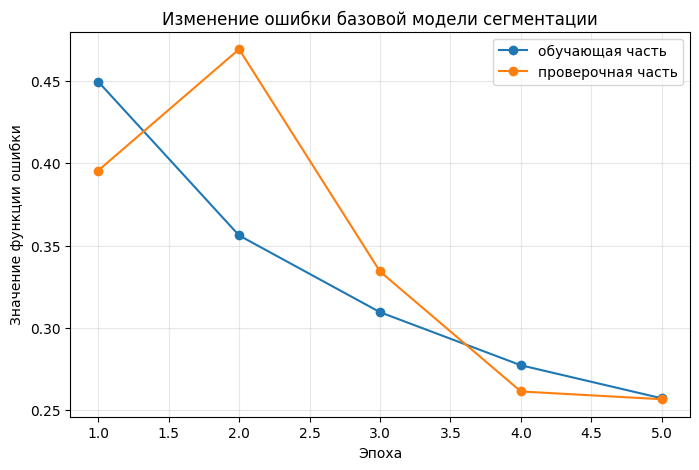

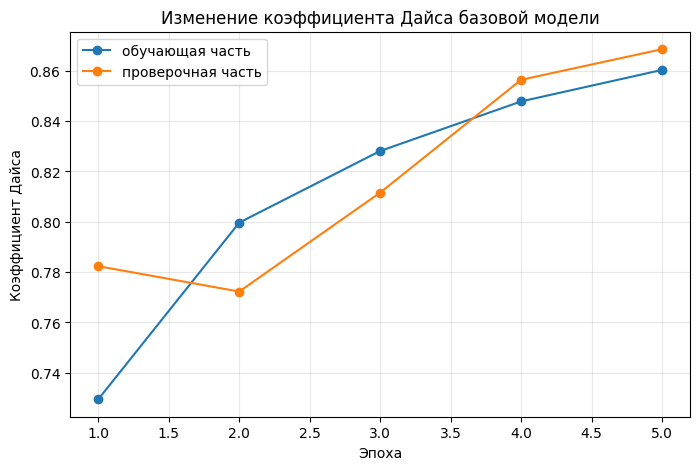

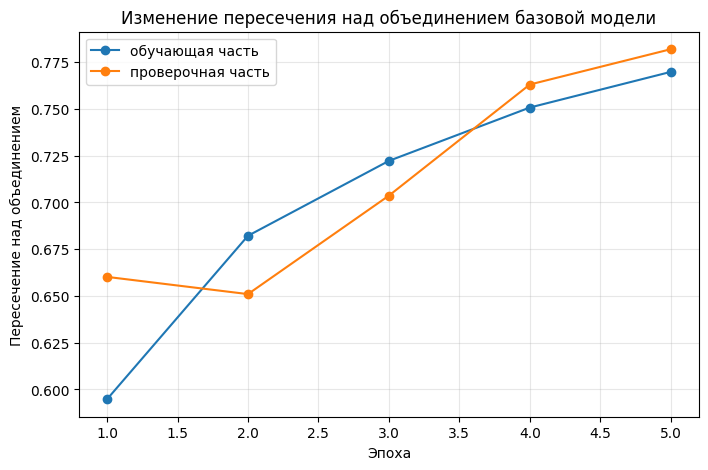

Графики сохранены:
/content/image_generation_processing_project/results/figures/segmentation_baseline_loss.png
/content/image_generation_processing_project/results/figures/segmentation_baseline_dice.png
/content/image_generation_processing_project/results/figures/segmentation_baseline_iou.png


In [33]:
# Преобразуем историю обучения в таблицу.
baseline_history_table = pd.DataFrame(baseline_history)

baseline_history_path = metrics_dir / "segmentation_baseline_history.csv"
baseline_history_table.to_csv(baseline_history_path, index=False, encoding="utf-8")

print("История обучения сохранена:", baseline_history_path)
display(baseline_history_table)

# Строим график функции ошибки.
plt.figure(figsize=(8, 5))
plt.plot(baseline_history_table["epoch"], baseline_history_table["train_loss"], marker="o", label="обучающая часть")
plt.plot(baseline_history_table["epoch"], baseline_history_table["validation_loss"], marker="o", label="проверочная часть")
plt.title("Изменение ошибки базовой модели сегментации")
plt.xlabel("Эпоха")
plt.ylabel("Значение функции ошибки")
plt.grid(alpha=0.3)
plt.legend()

baseline_loss_figure_path = figures_dir / "segmentation_baseline_loss.png"
plt.savefig(baseline_loss_figure_path, dpi=200, bbox_inches="tight")
plt.show()

# Строим график коэффициента Дайса.
plt.figure(figsize=(8, 5))
plt.plot(baseline_history_table["epoch"], baseline_history_table["train_dice"], marker="o", label="обучающая часть")
plt.plot(baseline_history_table["epoch"], baseline_history_table["validation_dice"], marker="o", label="проверочная часть")
plt.title("Изменение коэффициента Дайса базовой модели")
plt.xlabel("Эпоха")
plt.ylabel("Коэффициент Дайса")
plt.grid(alpha=0.3)
plt.legend()

baseline_dice_figure_path = figures_dir / "segmentation_baseline_dice.png"
plt.savefig(baseline_dice_figure_path, dpi=200, bbox_inches="tight")
plt.show()

# Строим график пересечения над объединением.
plt.figure(figsize=(8, 5))
plt.plot(baseline_history_table["epoch"], baseline_history_table["train_iou"], marker="o", label="обучающая часть")
plt.plot(baseline_history_table["epoch"], baseline_history_table["validation_iou"], marker="o", label="проверочная часть")
plt.title("Изменение пересечения над объединением базовой модели")
plt.xlabel("Эпоха")
plt.ylabel("Пересечение над объединением")
plt.grid(alpha=0.3)
plt.legend()

baseline_iou_figure_path = figures_dir / "segmentation_baseline_iou.png"
plt.savefig(baseline_iou_figure_path, dpi=200, bbox_inches="tight")
plt.show()

print("Графики сохранены:")
print(baseline_loss_figure_path)
print(baseline_dice_figure_path)
print(baseline_iou_figure_path)

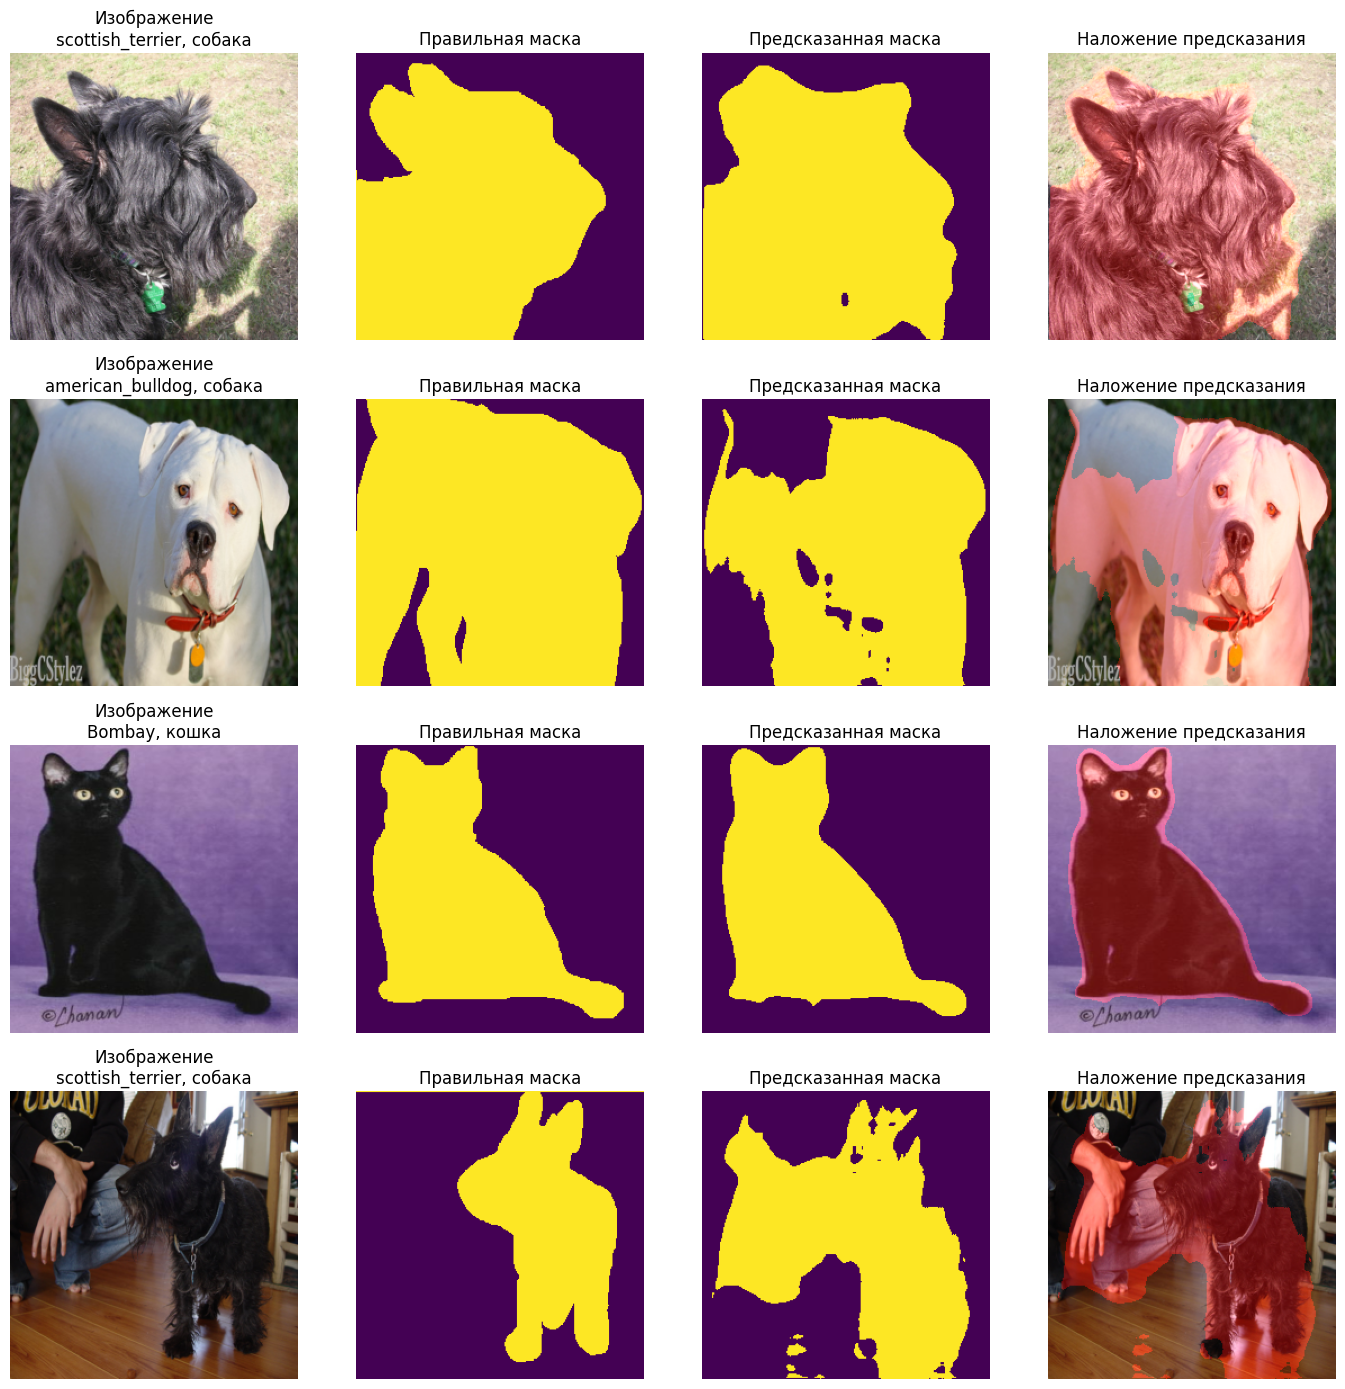

Рисунок с предсказаниями базовой модели сохранен: /content/image_generation_processing_project/results/examples/segmentation_baseline_predictions.png


In [34]:
# Загружаем лучший вариант базовой модели.
checkpoint = torch.load(baseline_model_path, map_location=DEVICE)
baseline_model.load_state_dict(checkpoint["model_state_dict"])
baseline_model.to(DEVICE)
baseline_model.eval()

# Получаем один пакет из проверочной части.
validation_batch = next(iter(validation_loader))

images = validation_batch["image"].to(DEVICE)
true_masks = validation_batch["mask"].to(DEVICE)

with torch.no_grad():
    with get_autocast_context():
        logits = baseline_model(images)
        probabilities = torch.sigmoid(logits)
        predicted_masks = (probabilities > MASK_THRESHOLD).float()

# Выбираем несколько примеров для показа.
samples_to_show = min(4, images.shape[0])

figure, axes = plt.subplots(
    nrows=samples_to_show,
    ncols=4,
    figsize=(14, 3.5 * samples_to_show)
)

if samples_to_show == 1:
    axes = np.expand_dims(axes, axis=0)

for index in range(samples_to_show):
    image_for_show = denormalize_image(images[index])
    true_mask_for_show = true_masks[index, 0].detach().cpu().numpy()
    predicted_mask_for_show = predicted_masks[index, 0].detach().cpu().numpy()

    # Создаем наложение предсказанной маски на исходное изображение.
    overlay = image_for_show.copy()
    overlay[:, :, 0] = np.clip(overlay[:, :, 0] + predicted_mask_for_show * 0.35, 0.0, 1.0)

    title_text = (
        str(validation_batch["breed_name"][index]) +
        ", " +
        str(validation_batch["species_name_ru"][index])
    )

    axes[index, 0].imshow(image_for_show)
    axes[index, 0].set_title("Изображение\n" + title_text)
    axes[index, 0].axis("off")

    axes[index, 1].imshow(true_mask_for_show)
    axes[index, 1].set_title("Правильная маска")
    axes[index, 1].axis("off")

    axes[index, 2].imshow(predicted_mask_for_show)
    axes[index, 2].set_title("Предсказанная маска")
    axes[index, 2].axis("off")

    axes[index, 3].imshow(overlay)
    axes[index, 3].set_title("Наложение предсказания")
    axes[index, 3].axis("off")

plt.tight_layout()

baseline_predictions_path = examples_dir / "segmentation_baseline_predictions.png"
plt.savefig(baseline_predictions_path, dpi=200, bbox_inches="tight")
plt.show()

print("Рисунок с предсказаниями базовой модели сохранен:", baseline_predictions_path)

In [35]:
# Выполняем итоговую оценку лучшей базовой модели на проверочной части.
# Контрольную часть пока не используем, чтобы сохранить ее для финального сравнения.
final_validation_metrics = evaluate_model(
    model=baseline_model,
    data_loader=validation_loader,
    loss_function=loss_function
)

baseline_validation_metrics = {
    "model_name": "segmentation_baseline_unet",
    "evaluation_part": "проверочная",
    "best_epoch": int(best_epoch),
    "loss": float(final_validation_metrics["loss"]),
    "dice": float(final_validation_metrics["dice"]),
    "iou": float(final_validation_metrics["iou"]),
    "pixel_accuracy": float(final_validation_metrics["pixel_accuracy"]),
    "threshold": float(MASK_THRESHOLD),
    "image_size": int(IMAGE_SIZE),
    "trainable_parameters": int(trainable_parameters),
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

baseline_metrics_path = metrics_dir / "segmentation_baseline_validation_metrics.json"

with open(baseline_metrics_path, "w", encoding="utf-8") as file:
    json.dump(baseline_validation_metrics, file, ensure_ascii=False, indent=4)

print("Итоговые показатели базовой модели на проверочной части:")
for key, value in baseline_validation_metrics.items():
    print(key, ":", value)

print("Файл с итоговыми показателями сохранен:", baseline_metrics_path)

Итоговые показатели базовой модели на проверочной части:
model_name : segmentation_baseline_unet
evaluation_part : проверочная
best_epoch : 5
loss : 0.2565582083619159
dice : 0.8684705884560294
iou : 0.7818047810291898
pixel_accuracy : 0.895873701226884
threshold : 0.5
image_size : 256
trainable_parameters : 7763041
created_at : 2026-05-04 00:26:08
Файл с итоговыми показателями сохранен: /content/image_generation_processing_project/results/metrics/segmentation_baseline_validation_metrics.json


In [36]:
# Копируем результаты обучения базовой модели на Google Drive.
# Сохраняются веса модели, история обучения, показатели качества, графики и примеры предсказаний.

drive_models_dir = DRIVE_PROJECT_DIR / "models"
drive_metrics_dir = DRIVE_PROJECT_DIR / "metrics"
drive_figures_dir = DRIVE_PROJECT_DIR / "figures"
drive_examples_dir = DRIVE_PROJECT_DIR / "examples"

for directory in [drive_models_dir, drive_metrics_dir, drive_figures_dir, drive_examples_dir]:
    directory.mkdir(parents=True, exist_ok=True)

files_to_copy = [
    baseline_model_path,
    baseline_last_model_path,
    baseline_history_path,
    baseline_metrics_path,
    baseline_loss_figure_path,
    baseline_dice_figure_path,
    baseline_iou_figure_path,
    baseline_predictions_path,
]

for source_path in files_to_copy:
    source_path = Path(source_path)

    if source_path.suffix == ".pt":
        destination_path = drive_models_dir / source_path.name
    elif source_path.suffix in [".csv", ".json"]:
        destination_path = drive_metrics_dir / source_path.name
    elif source_path.name.endswith(".png") and "predictions" in source_path.name:
        destination_path = drive_examples_dir / source_path.name
    else:
        destination_path = drive_figures_dir / source_path.name

    shutil.copy2(source_path, destination_path)
    print("Сохранено:", destination_path)

print("Результаты этапа 6 сохранены на Google Drive")

Сохранено: /content/drive/MyDrive/image_generation_processing_project/models/segmentation_baseline_unet_best.pt
Сохранено: /content/drive/MyDrive/image_generation_processing_project/models/segmentation_baseline_unet_last.pt
Сохранено: /content/drive/MyDrive/image_generation_processing_project/metrics/segmentation_baseline_history.csv
Сохранено: /content/drive/MyDrive/image_generation_processing_project/metrics/segmentation_baseline_validation_metrics.json
Сохранено: /content/drive/MyDrive/image_generation_processing_project/figures/segmentation_baseline_loss.png
Сохранено: /content/drive/MyDrive/image_generation_processing_project/figures/segmentation_baseline_dice.png
Сохранено: /content/drive/MyDrive/image_generation_processing_project/figures/segmentation_baseline_iou.png
Сохранено: /content/drive/MyDrive/image_generation_processing_project/examples/segmentation_baseline_predictions.png
Результаты этапа 6 сохранены на Google Drive


Результаты этапа 6 хорошие для базовой модели. Коэффициент Дайса на проверочной части вырос с 0,7823 до 0,8685, а пересечение над объединением достигло 0,7818. Графики показывают устойчивое улучшение качества к пятой эпохе: ошибка снижается, а обе основные метрики растут. Отдельный всплеск ошибки на второй эпохе не является критическим, поскольку после него модель восстановила динамику и завершила обучение с лучшим результатом.

Визуальная проверка показывает, что базовая модель в целом выделяет животных, но на сложных изображениях появляются ошибки: захватывается часть фона, теряются тонкие детали, иногда возникают пустоты внутри объекта. Для магистерской диссертации это полезный результат, потому что он обосновывает необходимость улучшенной модели. На следующем этапе используется модель U-Net с предварительно обученным кодировщиком. Библиотека segmentation_models_pytorch поддерживает U-Net с разными кодировщиками через параметр encoder_name, а предварительно обученные веса задаются через encoder_weights. Также библиотека содержит функцию ошибки DiceLoss для задач бинарной сегментации.

# 7. Обучение улучшенной модели сегментации

На седьмом этапе обучается улучшенная модель сегментации. В отличие от базовой модели, улучшенная модель использует предварительно обученный кодировщик. Кодировщик представляет собой часть нейросетевой модели, которая извлекает признаки изображения: границы, формы, цветовые переходы и более сложные зрительные структуры. Предварительное обучение позволяет использовать уже накопленные признаки и быстрее получить качественную маску объекта.

Научная новизна данного этапа состоит в сравнении двух подходов в одинаковых условиях: простая модель обучалась с нуля, а улучшенная модель использует перенос признаков из предварительно обученной сети и комбинированную функцию ошибки. Комбинированная функция ошибки учитывает как попиксельное отличие, так и совпадение формы объекта. Такой подход должен уменьшить ошибки на границах и повысить качество выделения объекта на сложных изображениях.

In [37]:
# Импортируем основные библиотеки.
import os
import json
import time
import copy
import shutil
from pathlib import Path
from datetime import datetime
from contextlib import nullcontext

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Импортируем библиотеку готовых моделей сегментации.
# Она содержит архитектуры, которые часто применяются для выделения объектов на изображениях.
import segmentation_models_pytorch as smp

# Проверяем, что предыдущие этапы уже выполнены.
required_objects = [
    "train_loader",
    "validation_loader",
    "test_loader",
    "DEVICE",
    "RESULTS_DIR",
    "DRIVE_PROJECT_DIR",
    "IMAGE_SIZE",
    "IMAGE_MEAN",
    "IMAGE_STD",
    "MASK_THRESHOLD",
]

for object_name in required_objects:
    if object_name not in globals():
        raise NameError(
            "Не найдена переменная " + object_name + ". Необходимо сначала выполнить предыдущие этапы."
        )

# Проверяем наличие функций из предыдущего этапа.
# Если они отсутствуют, код дальше остановится с понятным сообщением.
required_functions = [
    "calculate_dice_score_from_logits",
    "calculate_iou_score_from_logits",
    "calculate_pixel_accuracy_from_logits",
    "denormalize_image",
]

for function_name in required_functions:
    if function_name not in globals():
        raise NameError(
            "Не найдена функция " + function_name + ". Необходимо сначала выполнить этапы 5 и 6."
        )

# Создаем каталоги для результатов.
models_dir = RESULTS_DIR / "models"
metrics_dir = RESULTS_DIR / "metrics"
figures_dir = RESULTS_DIR / "figures"
examples_dir = RESULTS_DIR / "examples"
reports_dir = RESULTS_DIR / "reports"

for directory in [models_dir, metrics_dir, figures_dir, examples_dir, reports_dir]:
    directory.mkdir(parents=True, exist_ok=True)

# Фиксируем начальное число для воспроизводимости.
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

print("Библиотека моделей сегментации загружена")
print("Версия библиотеки:", smp.__version__)
print("Устройство вычислений:", DEVICE)
print("Размер входного изображения:", IMAGE_SIZE)

Библиотека моделей сегментации загружена
Версия библиотеки: 0.5.0
Устройство вычислений: cuda
Размер входного изображения: 256


In [38]:
# Задаем параметры улучшенной модели.
# U-Net используется как основная архитектура для выделения объекта.
# ResNet34 используется как кодировщик, то есть часть модели для извлечения признаков.
# Предварительно обученные веса помогают модели быстрее распознавать полезные зрительные признаки.
IMPROVED_MODEL_NAME = "segmentation_improved_unet_resnet34"
ENCODER_NAME = "resnet34"
ENCODER_WEIGHTS = "imagenet"

# Создаем модель.
# Если загрузка предварительно обученных весов не удастся из-за временной сетевой ошибки,
# модель будет создана без предварительно обученных весов.
try:
    improved_model = smp.Unet(
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=3,
        classes=1,
        activation=None,
    )
    used_encoder_weights = ENCODER_WEIGHTS
    print("Улучшенная модель создана с предварительно обученным кодировщиком")
except Exception as exception:
    print("Не удалось загрузить предварительно обученные веса")
    print("Причина:", str(exception))
    print("Модель будет создана без предварительно обученных весов")

    improved_model = smp.Unet(
        encoder_name=ENCODER_NAME,
        encoder_weights=None,
        in_channels=3,
        classes=1,
        activation=None,
    )
    used_encoder_weights = None

# Переносим модель на выбранное устройство.
improved_model = improved_model.to(DEVICE)

# Считаем количество обучаемых параметров.
improved_trainable_parameters = sum(
    parameter.numel()
    for parameter in improved_model.parameters()
    if parameter.requires_grad
)

print("Название улучшенной модели:", IMPROVED_MODEL_NAME)
print("Кодировщик:", ENCODER_NAME)
print("Использованные предварительно обученные веса:", used_encoder_weights)
print("Количество обучаемых параметров:", improved_trainable_parameters)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Улучшенная модель создана с предварительно обученным кодировщиком
Название улучшенной модели: segmentation_improved_unet_resnet34
Кодировщик: resnet34
Использованные предварительно обученные веса: imagenet
Количество обучаемых параметров: 24436369


In [39]:
# Описываем комбинированную функцию ошибки.
# Первая часть оценивает отличие каждого пикселя от правильного ответа.
# Вторая часть оценивает совпадение формы предсказанной области и правильной области.
class CombinedSegmentationLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()

        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

        # Бинарная перекрестная энтропия с внутренним сигмоидным преобразованием.
        self.bce_loss = nn.BCEWithLogitsLoss()

        # Функция ошибки Дайса для бинарной сегментации.
        self.dice_loss = smp.losses.DiceLoss(
            mode="binary",
            from_logits=True
        )

    def forward(self, logits, masks):
        bce_value = self.bce_loss(logits, masks)
        dice_value = self.dice_loss(logits, masks)

        total_loss = self.bce_weight * bce_value + self.dice_weight * dice_value

        return total_loss

# Задаем параметры обучения улучшенной модели.
# Количество эпох умеренное, чтобы эксперимент укладывался в ограничения бесплатной среды Colab.
IMPROVED_EPOCHS = 6
IMPROVED_LEARNING_RATE = 5e-4

improved_loss_function = CombinedSegmentationLoss(
    bce_weight=0.5,
    dice_weight=0.5
)

# AdamW отличается от Adam тем, что отдельно учитывает ограничение роста весов.
# Это помогает немного снизить риск переобучения.
improved_optimizer = torch.optim.AdamW(
    improved_model.parameters(),
    lr=IMPROVED_LEARNING_RATE,
    weight_decay=1e-4
)

# Если качество перестает расти, скорость обучения будет уменьшена.
improved_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    improved_optimizer,
    mode="max",
    factor=0.5,
    patience=1
)

# Настраиваем смешанную точность.
# Она ускоряет вычисления на графическом ускорителе и снижает расход памяти.
USE_MIXED_PRECISION = DEVICE == "cuda"

if USE_MIXED_PRECISION:
    improved_scaler = torch.amp.GradScaler("cuda", enabled=True)
else:
    improved_scaler = torch.amp.GradScaler("cpu", enabled=False)

def get_improved_autocast_context():
    if USE_MIXED_PRECISION:
        return torch.amp.autocast(device_type="cuda", enabled=True)
    return nullcontext()

print("Настройки обучения улучшенной модели подготовлены")
print("Количество эпох:", IMPROVED_EPOCHS)
print("Скорость обучения:", IMPROVED_LEARNING_RATE)
print("Смешанная точность:", USE_MIXED_PRECISION)
print("Функция ошибки: половина попиксельной ошибки и половина ошибки Дайса")

Настройки обучения улучшенной модели подготовлены
Количество эпох: 6
Скорость обучения: 0.0005
Смешанная точность: True
Функция ошибки: половина попиксельной ошибки и половина ошибки Дайса


In [40]:
# Описываем один проход обучения для улучшенной модели.
def train_one_epoch_improved(model, data_loader, optimizer, loss_function):
    model.train()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    total_accuracy = 0.0
    batch_count = 0

    start_time = time.time()

    for batch in data_loader:
        images = batch["image"].to(DEVICE, non_blocking=True)
        masks = batch["mask"].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with get_improved_autocast_context():
            logits = model(images)
            loss = loss_function(logits, masks)

        if USE_MIXED_PRECISION:
            improved_scaler.scale(loss).backward()
            improved_scaler.step(optimizer)
            improved_scaler.update()
        else:
            loss.backward()
            optimizer.step()

        with torch.no_grad():
            dice_score = calculate_dice_score_from_logits(logits, masks, threshold=MASK_THRESHOLD)
            iou_score = calculate_iou_score_from_logits(logits, masks, threshold=MASK_THRESHOLD)
            pixel_accuracy = calculate_pixel_accuracy_from_logits(logits, masks, threshold=MASK_THRESHOLD)

        total_loss += float(loss.detach().cpu())
        total_dice += float(dice_score.detach().cpu())
        total_iou += float(iou_score.detach().cpu())
        total_accuracy += float(pixel_accuracy.detach().cpu())
        batch_count += 1

    epoch_time = time.time() - start_time

    return {
        "loss": total_loss / batch_count,
        "dice": total_dice / batch_count,
        "iou": total_iou / batch_count,
        "pixel_accuracy": total_accuracy / batch_count,
        "epoch_time_seconds": epoch_time,
    }

# Описываем проверку улучшенной модели.
def evaluate_model_improved(model, data_loader, loss_function):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    total_accuracy = 0.0
    batch_count = 0

    start_time = time.time()

    with torch.no_grad():
        for batch in data_loader:
            images = batch["image"].to(DEVICE, non_blocking=True)
            masks = batch["mask"].to(DEVICE, non_blocking=True)

            with get_improved_autocast_context():
                logits = model(images)
                loss = loss_function(logits, masks)

            dice_score = calculate_dice_score_from_logits(logits, masks, threshold=MASK_THRESHOLD)
            iou_score = calculate_iou_score_from_logits(logits, masks, threshold=MASK_THRESHOLD)
            pixel_accuracy = calculate_pixel_accuracy_from_logits(logits, masks, threshold=MASK_THRESHOLD)

            total_loss += float(loss.detach().cpu())
            total_dice += float(dice_score.detach().cpu())
            total_iou += float(iou_score.detach().cpu())
            total_accuracy += float(pixel_accuracy.detach().cpu())
            batch_count += 1

    epoch_time = time.time() - start_time

    return {
        "loss": total_loss / batch_count,
        "dice": total_dice / batch_count,
        "iou": total_iou / batch_count,
        "pixel_accuracy": total_accuracy / batch_count,
        "epoch_time_seconds": epoch_time,
    }

print("Функции обучения и проверки улучшенной модели подготовлены")

Функции обучения и проверки улучшенной модели подготовлены


In [41]:
# Обучаем улучшенную модель и сохраняем лучший вариант по коэффициенту Дайса.
improved_history = []
improved_best_validation_dice = -1.0
improved_best_model_state = None
improved_best_epoch = 0

improved_model_path = models_dir / "segmentation_improved_unet_resnet34_best.pt"
improved_last_model_path = models_dir / "segmentation_improved_unet_resnet34_last.pt"

print("Начато обучение улучшенной модели")
print("Лучшей будет считаться модель с максимальным коэффициентом Дайса на проверочной части")

for epoch in range(1, IMPROVED_EPOCHS + 1):
    train_metrics = train_one_epoch_improved(
        model=improved_model,
        data_loader=train_loader,
        optimizer=improved_optimizer,
        loss_function=improved_loss_function
    )

    validation_metrics = evaluate_model_improved(
        model=improved_model,
        data_loader=validation_loader,
        loss_function=improved_loss_function
    )

    improved_scheduler.step(validation_metrics["dice"])

    current_learning_rate = improved_optimizer.param_groups[0]["lr"]

    row = {
        "epoch": epoch,
        "learning_rate": current_learning_rate,
        "train_loss": train_metrics["loss"],
        "train_dice": train_metrics["dice"],
        "train_iou": train_metrics["iou"],
        "train_pixel_accuracy": train_metrics["pixel_accuracy"],
        "train_time_seconds": train_metrics["epoch_time_seconds"],
        "validation_loss": validation_metrics["loss"],
        "validation_dice": validation_metrics["dice"],
        "validation_iou": validation_metrics["iou"],
        "validation_pixel_accuracy": validation_metrics["pixel_accuracy"],
        "validation_time_seconds": validation_metrics["epoch_time_seconds"],
    }

    improved_history.append(row)

    if validation_metrics["dice"] > improved_best_validation_dice:
        improved_best_validation_dice = validation_metrics["dice"]
        improved_best_epoch = epoch
        improved_best_model_state = copy.deepcopy(improved_model.state_dict())

        torch.save(
            {
                "model_state_dict": improved_best_model_state,
                "model_name": IMPROVED_MODEL_NAME,
                "architecture": "Unet",
                "encoder_name": ENCODER_NAME,
                "encoder_weights": used_encoder_weights,
                "image_size": IMAGE_SIZE,
                "image_mean": IMAGE_MEAN.tolist(),
                "image_std": IMAGE_STD.tolist(),
                "best_epoch": improved_best_epoch,
                "best_validation_dice": improved_best_validation_dice,
                "threshold": MASK_THRESHOLD,
                "trainable_parameters": improved_trainable_parameters,
                "loss_function": "половина попиксельной ошибки и половина ошибки Дайса",
            },
            improved_model_path
        )

    torch.save(
        {
            "model_state_dict": improved_model.state_dict(),
            "model_name": IMPROVED_MODEL_NAME,
            "architecture": "Unet",
            "encoder_name": ENCODER_NAME,
            "encoder_weights": used_encoder_weights,
            "image_size": IMAGE_SIZE,
            "image_mean": IMAGE_MEAN.tolist(),
            "image_std": IMAGE_STD.tolist(),
            "last_epoch": epoch,
            "threshold": MASK_THRESHOLD,
            "trainable_parameters": improved_trainable_parameters,
        },
        improved_last_model_path
    )

    print(
        "Эпоха:",
        epoch,
        "| ошибка обучения:",
        round(train_metrics["loss"], 4),
        "| Дайс обучения:",
        round(train_metrics["dice"], 4),
        "| ошибка проверки:",
        round(validation_metrics["loss"], 4),
        "| Дайс проверки:",
        round(validation_metrics["dice"], 4),
        "| пересечение над объединением:",
        round(validation_metrics["iou"], 4),
        "| скорость обучения:",
        current_learning_rate,
        "| время эпохи:",
        round(train_metrics["epoch_time_seconds"], 1),
        "сек."
    )

print("Обучение улучшенной модели завершено")
print("Лучшая эпоха:", improved_best_epoch)
print("Лучший коэффициент Дайса на проверочной части:", round(improved_best_validation_dice, 4))
print("Лучшая модель сохранена:", improved_model_path)

Начато обучение улучшенной модели
Лучшей будет считаться модель с максимальным коэффициентом Дайса на проверочной части
Эпоха: 1 | ошибка обучения: 0.1841 | Дайс обучения: 0.8889 | ошибка проверки: 0.1528 | Дайс проверки: 0.9052 | пересечение над объединением: 0.8407 | скорость обучения: 0.0005 | время эпохи: 97.6 сек.
Эпоха: 2 | ошибка обучения: 0.1403 | Дайс обучения: 0.9142 | ошибка проверки: 0.144 | Дайс проверки: 0.9067 | пересечение над объединением: 0.8435 | скорость обучения: 0.0005 | время эпохи: 64.0 сек.
Эпоха: 3 | ошибка обучения: 0.126 | Дайс обучения: 0.9232 | ошибка проверки: 0.1301 | Дайс проверки: 0.9196 | пересечение над объединением: 0.8612 | скорость обучения: 0.0005 | время эпохи: 64.0 сек.
Эпоха: 4 | ошибка обучения: 0.1197 | Дайс обучения: 0.9262 | ошибка проверки: 0.1072 | Дайс проверки: 0.9329 | пересечение над объединением: 0.8811 | скорость обучения: 0.0005 | время эпохи: 63.9 сек.
Эпоха: 5 | ошибка обучения: 0.1089 | Дайс обучения: 0.9329 | ошибка проверки: 

История обучения улучшенной модели сохранена: /content/image_generation_processing_project/results/metrics/segmentation_improved_history.csv


,epoch,learning_rate,train_loss,train_dice,train_iou,train_pixel_accuracy,train_time_seconds,validation_loss,validation_dice,validation_iou,validation_pixel_accuracy,validation_time_seconds
0,1,0.0005,0.184110,0.888944,0.813935,0.914550,97.643482,0.152809,0.905238,0.840673,0.934116,11.155185
1,2,0.0005,0.140252,0.914201,0.852192,0.934871,64.005939,0.143955,0.906720,0.843515,0.934847,11.001163
2,3,0.0005,0.126019,0.923173,0.866068,0.941933,63.994714,0.130089,0.919616,0.861213,0.939857,10.979790
3,4,0.0005,0.119682,0.926198,0.871024,0.944329,63.850520,0.107150,0.932949,0.881092,0.950363,10.946441
4,5,0.0005,0.108856,0.932942,0.881230,0.949372,63.662498,0.101177,0.935458,0.885696,0.952437,10.710368
5,6,0.0005,0.099787,0.937673,0.889102,0.953665,64.447109,0.095948,0.939614,0.892138,0.954611,10.188047


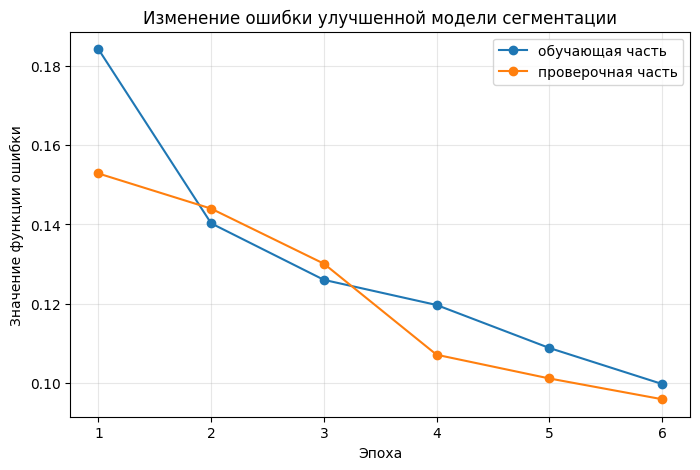

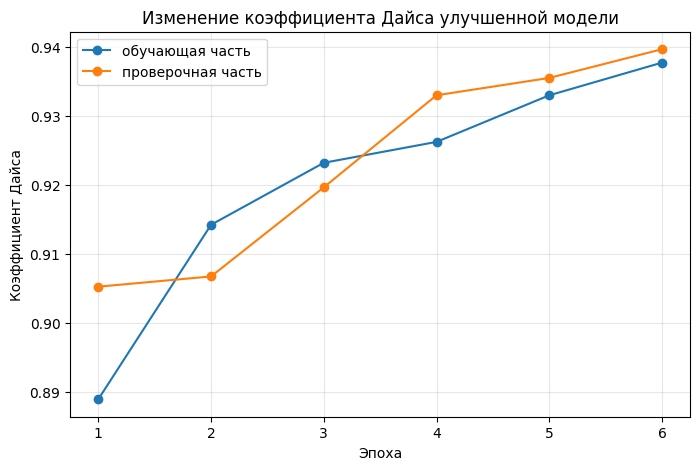

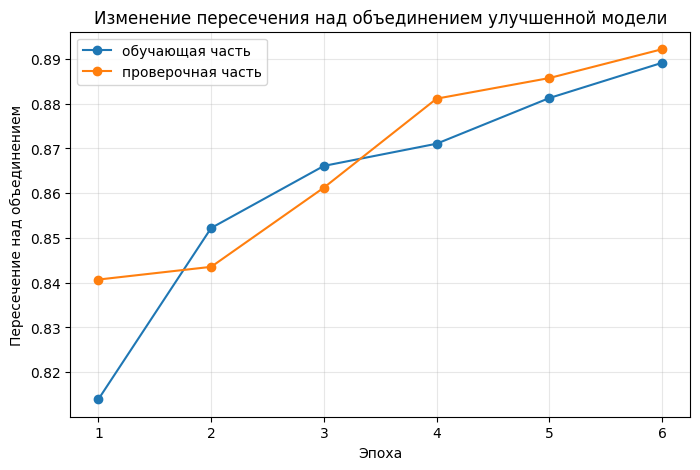

Графики улучшенной модели сохранены:
/content/image_generation_processing_project/results/figures/segmentation_improved_loss.png
/content/image_generation_processing_project/results/figures/segmentation_improved_dice.png
/content/image_generation_processing_project/results/figures/segmentation_improved_iou.png


In [42]:
# Преобразуем историю обучения в таблицу.
improved_history_table = pd.DataFrame(improved_history)

improved_history_path = metrics_dir / "segmentation_improved_history.csv"
improved_history_table.to_csv(improved_history_path, index=False, encoding="utf-8")

print("История обучения улучшенной модели сохранена:", improved_history_path)
display(improved_history_table)

# Строим график функции ошибки.
plt.figure(figsize=(8, 5))
plt.plot(improved_history_table["epoch"], improved_history_table["train_loss"], marker="o", label="обучающая часть")
plt.plot(improved_history_table["epoch"], improved_history_table["validation_loss"], marker="o", label="проверочная часть")
plt.title("Изменение ошибки улучшенной модели сегментации")
plt.xlabel("Эпоха")
plt.ylabel("Значение функции ошибки")
plt.grid(alpha=0.3)
plt.legend()

improved_loss_figure_path = figures_dir / "segmentation_improved_loss.png"
plt.savefig(improved_loss_figure_path, dpi=200, bbox_inches="tight")
plt.show()

# Строим график коэффициента Дайса.
plt.figure(figsize=(8, 5))
plt.plot(improved_history_table["epoch"], improved_history_table["train_dice"], marker="o", label="обучающая часть")
plt.plot(improved_history_table["epoch"], improved_history_table["validation_dice"], marker="o", label="проверочная часть")
plt.title("Изменение коэффициента Дайса улучшенной модели")
plt.xlabel("Эпоха")
plt.ylabel("Коэффициент Дайса")
plt.grid(alpha=0.3)
plt.legend()

improved_dice_figure_path = figures_dir / "segmentation_improved_dice.png"
plt.savefig(improved_dice_figure_path, dpi=200, bbox_inches="tight")
plt.show()

# Строим график пересечения над объединением.
plt.figure(figsize=(8, 5))
plt.plot(improved_history_table["epoch"], improved_history_table["train_iou"], marker="o", label="обучающая часть")
plt.plot(improved_history_table["epoch"], improved_history_table["validation_iou"], marker="o", label="проверочная часть")
plt.title("Изменение пересечения над объединением улучшенной модели")
plt.xlabel("Эпоха")
plt.ylabel("Пересечение над объединением")
plt.grid(alpha=0.3)
plt.legend()

improved_iou_figure_path = figures_dir / "segmentation_improved_iou.png"
plt.savefig(improved_iou_figure_path, dpi=200, bbox_inches="tight")
plt.show()

print("Графики улучшенной модели сохранены:")
print(improved_loss_figure_path)
print(improved_dice_figure_path)
print(improved_iou_figure_path)

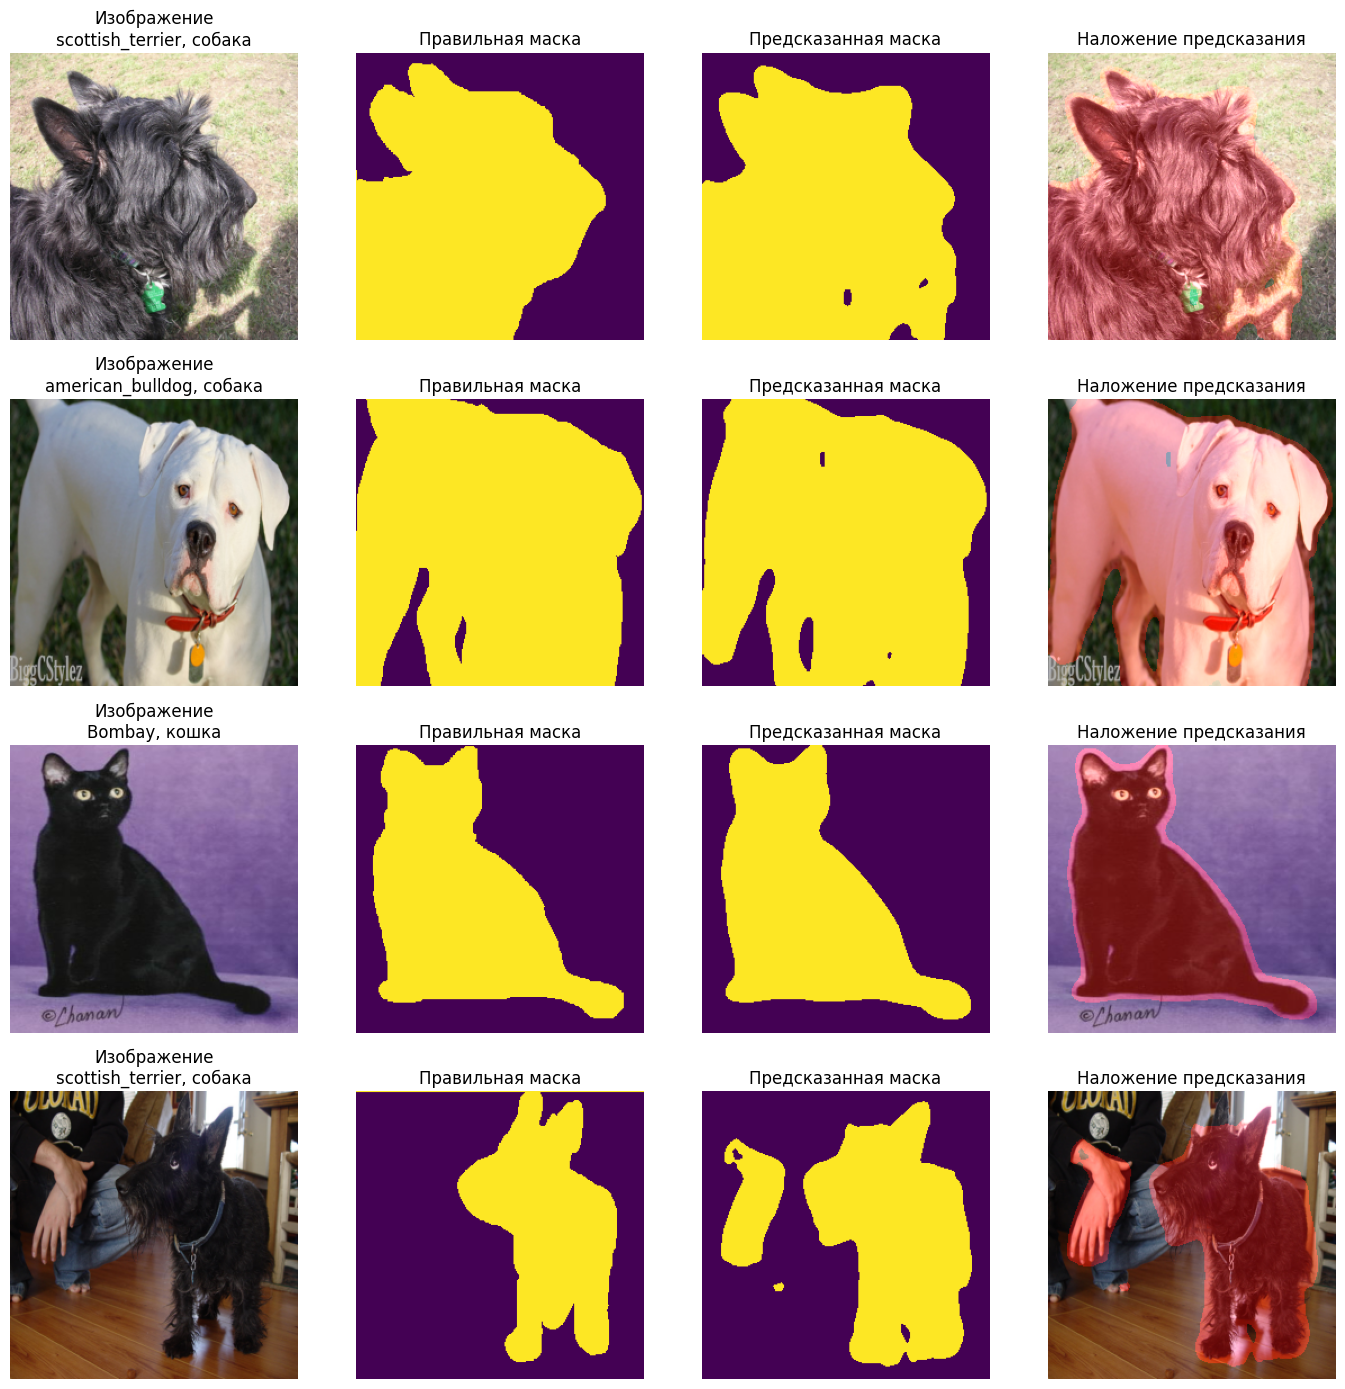

Рисунок с предсказаниями улучшенной модели сохранен: /content/image_generation_processing_project/results/examples/segmentation_improved_predictions.png


In [43]:
# Загружаем лучший вариант улучшенной модели.
checkpoint = torch.load(improved_model_path, map_location=DEVICE)
improved_model.load_state_dict(checkpoint["model_state_dict"])
improved_model.to(DEVICE)
improved_model.eval()

# Получаем один пакет из проверочной части.
validation_batch = next(iter(validation_loader))

images = validation_batch["image"].to(DEVICE)
true_masks = validation_batch["mask"].to(DEVICE)

with torch.no_grad():
    with get_improved_autocast_context():
        logits = improved_model(images)
        probabilities = torch.sigmoid(logits)
        predicted_masks = (probabilities > MASK_THRESHOLD).float()

samples_to_show = min(4, images.shape[0])

figure, axes = plt.subplots(
    nrows=samples_to_show,
    ncols=4,
    figsize=(14, 3.5 * samples_to_show)
)

if samples_to_show == 1:
    axes = np.expand_dims(axes, axis=0)

for index in range(samples_to_show):
    image_for_show = denormalize_image(images[index])
    true_mask_for_show = true_masks[index, 0].detach().cpu().numpy()
    predicted_mask_for_show = predicted_masks[index, 0].detach().cpu().numpy()

    overlay = image_for_show.copy()
    overlay[:, :, 0] = np.clip(overlay[:, :, 0] + predicted_mask_for_show * 0.35, 0.0, 1.0)

    title_text = (
        str(validation_batch["breed_name"][index]) +
        ", " +
        str(validation_batch["species_name_ru"][index])
    )

    axes[index, 0].imshow(image_for_show)
    axes[index, 0].set_title("Изображение\n" + title_text)
    axes[index, 0].axis("off")

    axes[index, 1].imshow(true_mask_for_show)
    axes[index, 1].set_title("Правильная маска")
    axes[index, 1].axis("off")

    axes[index, 2].imshow(predicted_mask_for_show)
    axes[index, 2].set_title("Предсказанная маска")
    axes[index, 2].axis("off")

    axes[index, 3].imshow(overlay)
    axes[index, 3].set_title("Наложение предсказания")
    axes[index, 3].axis("off")

plt.tight_layout()

improved_predictions_path = examples_dir / "segmentation_improved_predictions.png"
plt.savefig(improved_predictions_path, dpi=200, bbox_inches="tight")
plt.show()

print("Рисунок с предсказаниями улучшенной модели сохранен:", improved_predictions_path)

In [44]:
# Выполняем итоговую оценку лучшей улучшенной модели на проверочной части.
improved_validation_metrics_values = evaluate_model_improved(
    model=improved_model,
    data_loader=validation_loader,
    loss_function=improved_loss_function
)

improved_validation_metrics = {
    "model_name": IMPROVED_MODEL_NAME,
    "evaluation_part": "проверочная",
    "architecture": "Unet",
    "encoder_name": ENCODER_NAME,
    "encoder_weights": used_encoder_weights,
    "best_epoch": int(improved_best_epoch),
    "loss": float(improved_validation_metrics_values["loss"]),
    "dice": float(improved_validation_metrics_values["dice"]),
    "iou": float(improved_validation_metrics_values["iou"]),
    "pixel_accuracy": float(improved_validation_metrics_values["pixel_accuracy"]),
    "threshold": float(MASK_THRESHOLD),
    "image_size": int(IMAGE_SIZE),
    "trainable_parameters": int(improved_trainable_parameters),
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

improved_metrics_path = metrics_dir / "segmentation_improved_validation_metrics.json"

with open(improved_metrics_path, "w", encoding="utf-8") as file:
    json.dump(improved_validation_metrics, file, ensure_ascii=False, indent=4)

print("Итоговые показатели улучшенной модели на проверочной части:")
for key, value in improved_validation_metrics.items():
    print(key, ":", value)

print("Файл с итоговыми показателями сохранен:", improved_metrics_path)

Итоговые показатели улучшенной модели на проверочной части:
model_name : segmentation_improved_unet_resnet34
evaluation_part : проверочная
architecture : Unet
encoder_name : resnet34
encoder_weights : imagenet
best_epoch : 6
loss : 0.09594760397854059
dice : 0.9396140065746031
iou : 0.892137742128925
pixel_accuracy : 0.9546106911223867
threshold : 0.5
image_size : 256
trainable_parameters : 24436369
created_at : 2026-05-04 00:42:53
Файл с итоговыми показателями сохранен: /content/image_generation_processing_project/results/metrics/segmentation_improved_validation_metrics.json


In [45]:
# Загружаем показатели базовой модели, если файл существует.
baseline_metrics_path = metrics_dir / "segmentation_baseline_validation_metrics.json"

if not baseline_metrics_path.exists():
    raise FileNotFoundError(
        "Не найден файл с показателями базовой модели. Необходимо сначала выполнить этап 6."
    )

with open(baseline_metrics_path, "r", encoding="utf-8") as file:
    baseline_validation_metrics = json.load(file)

# Формируем сравнительную таблицу.
comparison_rows = [
    {
        "model_name": "базовая модель",
        "dice": baseline_validation_metrics["dice"],
        "iou": baseline_validation_metrics["iou"],
        "pixel_accuracy": baseline_validation_metrics["pixel_accuracy"],
        "loss": baseline_validation_metrics["loss"],
        "trainable_parameters": baseline_validation_metrics["trainable_parameters"],
        "best_epoch": baseline_validation_metrics["best_epoch"],
    },
    {
        "model_name": "улучшенная модель",
        "dice": improved_validation_metrics["dice"],
        "iou": improved_validation_metrics["iou"],
        "pixel_accuracy": improved_validation_metrics["pixel_accuracy"],
        "loss": improved_validation_metrics["loss"],
        "trainable_parameters": improved_validation_metrics["trainable_parameters"],
        "best_epoch": improved_validation_metrics["best_epoch"],
    },
]

segmentation_model_comparison = pd.DataFrame(comparison_rows)

# Рассчитываем прирост качества улучшенной модели относительно базовой.
baseline_dice = float(baseline_validation_metrics["dice"])
improved_dice = float(improved_validation_metrics["dice"])

baseline_iou = float(baseline_validation_metrics["iou"])
improved_iou = float(improved_validation_metrics["iou"])

dice_gain = improved_dice - baseline_dice
iou_gain = improved_iou - baseline_iou

comparison_path = metrics_dir / "segmentation_model_comparison_validation.csv"
segmentation_model_comparison.to_csv(comparison_path, index=False, encoding="utf-8")

comparison_summary = {
    "baseline_dice": baseline_dice,
    "improved_dice": improved_dice,
    "dice_gain": dice_gain,
    "baseline_iou": baseline_iou,
    "improved_iou": improved_iou,
    "iou_gain": iou_gain,
    "best_model_by_dice": "улучшенная модель" if improved_dice > baseline_dice else "базовая модель",
}

comparison_summary_path = metrics_dir / "segmentation_model_comparison_validation.json"

with open(comparison_summary_path, "w", encoding="utf-8") as file:
    json.dump(comparison_summary, file, ensure_ascii=False, indent=4)

print("Сравнение моделей на проверочной части:")
display(segmentation_model_comparison)

print("Прирост коэффициента Дайса:", round(dice_gain, 4))
print("Прирост пересечения над объединением:", round(iou_gain, 4))
print("Лучшая модель по коэффициенту Дайса:", comparison_summary["best_model_by_dice"])

print("Сравнительная таблица сохранена:", comparison_path)
print("Сводка сравнения сохранена:", comparison_summary_path)

Сравнение моделей на проверочной части:


,model_name,dice,iou,pixel_accuracy,loss,trainable_parameters,best_epoch
0,базовая модель,0.868471,0.781805,0.895874,0.256558,7763041,5
1,улучшенная модель,0.939614,0.892138,0.954611,0.095948,24436369,6


Прирост коэффициента Дайса: 0.0711
Прирост пересечения над объединением: 0.1103
Лучшая модель по коэффициенту Дайса: улучшенная модель
Сравнительная таблица сохранена: /content/image_generation_processing_project/results/metrics/segmentation_model_comparison_validation.csv
Сводка сравнения сохранена: /content/image_generation_processing_project/results/metrics/segmentation_model_comparison_validation.json


In [46]:
# Копируем результаты этапа на Google Drive.
drive_models_dir = DRIVE_PROJECT_DIR / "models"
drive_metrics_dir = DRIVE_PROJECT_DIR / "metrics"
drive_figures_dir = DRIVE_PROJECT_DIR / "figures"
drive_examples_dir = DRIVE_PROJECT_DIR / "examples"

for directory in [drive_models_dir, drive_metrics_dir, drive_figures_dir, drive_examples_dir]:
    directory.mkdir(parents=True, exist_ok=True)

files_to_copy = [
    improved_model_path,
    improved_last_model_path,
    improved_history_path,
    improved_metrics_path,
    comparison_path,
    comparison_summary_path,
    improved_loss_figure_path,
    improved_dice_figure_path,
    improved_iou_figure_path,
    improved_predictions_path,
]

for source_path in files_to_copy:
    source_path = Path(source_path)

    if source_path.suffix == ".pt":
        destination_path = drive_models_dir / source_path.name
    elif source_path.suffix in [".csv", ".json"]:
        destination_path = drive_metrics_dir / source_path.name
    elif source_path.name.endswith(".png") and "predictions" in source_path.name:
        destination_path = drive_examples_dir / source_path.name
    else:
        destination_path = drive_figures_dir / source_path.name

    shutil.copy2(source_path, destination_path)
    print("Сохранено:", destination_path)

print("Результаты этапа 7 сохранены на Google Drive")

Сохранено: /content/drive/MyDrive/image_generation_processing_project/models/segmentation_improved_unet_resnet34_best.pt
Сохранено: /content/drive/MyDrive/image_generation_processing_project/models/segmentation_improved_unet_resnet34_last.pt
Сохранено: /content/drive/MyDrive/image_generation_processing_project/metrics/segmentation_improved_history.csv
Сохранено: /content/drive/MyDrive/image_generation_processing_project/metrics/segmentation_improved_validation_metrics.json
Сохранено: /content/drive/MyDrive/image_generation_processing_project/metrics/segmentation_model_comparison_validation.csv
Сохранено: /content/drive/MyDrive/image_generation_processing_project/metrics/segmentation_model_comparison_validation.json
Сохранено: /content/drive/MyDrive/image_generation_processing_project/figures/segmentation_improved_loss.png
Сохранено: /content/drive/MyDrive/image_generation_processing_project/figures/segmentation_improved_dice.png
Сохранено: /content/drive/MyDrive/image_generation_proces

Результаты этапа 7 подтверждают, что улучшенная модель заметно превосходит базовую: коэффициент Дайса вырос с 0,8685 до 0,9396, пересечение над объединением — с 0,7818 до 0,8921. Прирост по коэффициенту Дайса на 0,0711 и по пересечению над объединением на 0,1103 является существенным для задачи сегментации, особенно с учетом одинакового разбиения данных и одинакового размера входного изображения.

Визуальная проверка также показывает улучшение: контуры стали устойчивее, объект отделяется от фона точнее, крупные ошибки базовой модели уменьшились. Отдельные дефекты сохраняются на сложных сценах: иногда остаются небольшие пустоты внутри объекта или захватываются близкие по цвету участки фона. Для диссертации это хороший результат, потому что появляется обоснованная экспериментальная линия: базовая модель → улучшенная модель → применение лучшей модели в модуле нейросетевой обработки изображений. На следующем этапе лучшая модель проверяется на контрольной части и превращается в набор артефактов для пользовательского приложения. Такой способ сохранения через словарь параметров модели соответствует стандартной практике PyTorch: state_dict хранит обучаемые параметры и позволяет восстановить модель той же архитектуры.

# 8. Контрольная проверка лучшей модели и подготовка артефактов для приложения

На восьмом этапе лучшая модель сегментации проверяется на контрольной части набора. Контрольная часть ранее не использовалась для выбора модели, поэтому такая проверка дает более честную оценку качества. Если показатели на контрольной части близки к показателям на проверочной части, модель можно считать устойчивой и пригодной для дальнейшего применения.

После оценки формируется набор файлов для пользовательского приложения. В него входят веса лучшей модели, настройки предварительной обработки изображения, вспомогательный программный модуль для получения маски, а также примеры обработки изображений. Дополнительно выполняется нейросетевая обработка изображений по предсказанной маске: выделение объекта на прозрачном фоне, размытие фона и замена фона на сгенерированный простой фон. Эти результаты показывают практическую применимость обученной модели.

In [47]:
# Импортируем библиотеки для контрольной проверки и подготовки файлов приложения.
import os
import json
import time
import shutil
from pathlib import Path
from datetime import datetime
from contextlib import nullcontext

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from PIL import Image, ImageFilter, ImageOps

import segmentation_models_pytorch as smp

# Проверяем наличие переменных, созданных на предыдущих этапах.
required_objects = [
    "test_loader",
    "DEVICE",
    "RESULTS_DIR",
    "DRIVE_PROJECT_DIR",
    "IMAGE_SIZE",
    "IMAGE_MEAN",
    "IMAGE_STD",
    "MASK_THRESHOLD",
]

for object_name in required_objects:
    if object_name not in globals():
        raise NameError(
            "Не найдена переменная " + object_name + ". Необходимо сначала выполнить предыдущие этапы."
        )

# Создаем каталоги для результатов этапа.
models_dir = RESULTS_DIR / "models"
metrics_dir = RESULTS_DIR / "metrics"
figures_dir = RESULTS_DIR / "figures"
examples_dir = RESULTS_DIR / "examples"
reports_dir = RESULTS_DIR / "reports"
export_dir = RESULTS_DIR / "export"
processed_dir = RESULTS_DIR / "processed_samples"

for directory in [models_dir, metrics_dir, figures_dir, examples_dir, reports_dir, export_dir, processed_dir]:
    directory.mkdir(parents=True, exist_ok=True)

# Указываем путь к лучшей улучшенной модели.
best_model_path = models_dir / "segmentation_improved_unet_resnet34_best.pt"

if not best_model_path.exists():
    raise FileNotFoundError(
        "Не найден файл лучшей улучшенной модели: " + str(best_model_path)
    )

print("Файл лучшей модели найден:", best_model_path)
print("Устройство вычислений:", DEVICE)
print("Размер входного изображения:", IMAGE_SIZE)
print("Порог бинаризации:", MASK_THRESHOLD)
print("Каталог для подготовленных файлов:", export_dir)

Файл лучшей модели найден: /content/image_generation_processing_project/results/models/segmentation_improved_unet_resnet34_best.pt
Устройство вычислений: cuda
Размер входного изображения: 256
Порог бинаризации: 0.5
Каталог для подготовленных файлов: /content/image_generation_processing_project/results/export


In [48]:
# Описываем безопасную загрузку сохраненного файла.
# В разных версиях PyTorch параметр weights_only может работать по-разному,
# поэтому сначала применяется рекомендуемый вариант, а затем запасной вариант.
def load_checkpoint_safely(checkpoint_path, device):
    try:
        checkpoint = torch.load(
            checkpoint_path,
            map_location=device,
            weights_only=True
        )
    except TypeError:
        checkpoint = torch.load(
            checkpoint_path,
            map_location=device
        )
    except Exception:
        checkpoint = torch.load(
            checkpoint_path,
            map_location=device,
            weights_only=False
        )

    return checkpoint

# Загружаем сведения о модели.
checkpoint = load_checkpoint_safely(best_model_path, DEVICE)

encoder_name_for_export = checkpoint.get("encoder_name", "resnet34")
architecture_for_export = checkpoint.get("architecture", "Unet")
threshold_for_export = float(checkpoint.get("threshold", MASK_THRESHOLD))
image_size_for_export = int(checkpoint.get("image_size", IMAGE_SIZE))

# Создаем модель той же архитектуры.
# Предварительно обученные веса здесь не загружаются, потому что итоговые веса уже сохранены в файле модели.
best_segmentation_model = smp.Unet(
    encoder_name=encoder_name_for_export,
    encoder_weights=None,
    in_channels=3,
    classes=1,
    activation=None,
)

best_segmentation_model.load_state_dict(checkpoint["model_state_dict"])
best_segmentation_model = best_segmentation_model.to(DEVICE)
best_segmentation_model.eval()

print("Лучшая модель загружена для контрольной проверки")
print("Архитектура:", architecture_for_export)
print("Кодировщик:", encoder_name_for_export)
print("Размер изображения:", image_size_for_export)
print("Порог маски:", threshold_for_export)
print("Лучшая эпоха при обучении:", checkpoint.get("best_epoch"))
print("Лучший коэффициент Дайса на проверочной части:", checkpoint.get("best_validation_dice"))

Лучшая модель загружена для контрольной проверки
Архитектура: Unet
Кодировщик: resnet34
Размер изображения: 256
Порог маски: 0.5
Лучшая эпоха при обучении: 6
Лучший коэффициент Дайса на проверочной части: 0.9396140065746031


In [49]:
# Описываем комбинированную функцию ошибки.
# Она совпадает с функцией, которая использовалась при обучении улучшенной модели.
class CombinedSegmentationLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()

        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

        self.bce_loss = nn.BCEWithLogitsLoss()
        self.dice_loss = smp.losses.DiceLoss(
            mode="binary",
            from_logits=True
        )

    def forward(self, logits, masks):
        bce_value = self.bce_loss(logits, masks)
        dice_value = self.dice_loss(logits, masks)
        total_loss = self.bce_weight * bce_value + self.dice_weight * dice_value

        return total_loss

control_loss_function = CombinedSegmentationLoss(
    bce_weight=0.5,
    dice_weight=0.5
)

# Функция расчета коэффициента Дайса.
# Чем ближе значение к единице, тем точнее совпадают области объекта.
def calculate_dice_score_from_logits_stage_8(logits, masks, threshold=0.5, smooth=1e-7):
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities > threshold).float()

    intersection = (predictions * masks).sum(dim=(1, 2, 3))
    prediction_sum = predictions.sum(dim=(1, 2, 3))
    mask_sum = masks.sum(dim=(1, 2, 3))

    dice = (2.0 * intersection + smooth) / (prediction_sum + mask_sum + smooth)

    return dice.mean()

# Функция расчета пересечения над объединением.
# Этот показатель строже оценивает совпадение предсказанной и правильной областей.
def calculate_iou_score_from_logits_stage_8(logits, masks, threshold=0.5, smooth=1e-7):
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities > threshold).float()

    intersection = (predictions * masks).sum(dim=(1, 2, 3))
    union = predictions.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - intersection

    iou = (intersection + smooth) / (union + smooth)

    return iou.mean()

# Функция расчета доли правильно определенных пикселей.
def calculate_pixel_accuracy_from_logits_stage_8(logits, masks, threshold=0.5):
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities > threshold).float()
    accuracy = (predictions == masks).float().mean()

    return accuracy

# Настраиваем смешанную точность для ускорения вычислений на графическом ускорителе.
USE_MIXED_PRECISION_STAGE_8 = DEVICE == "cuda"

def get_autocast_context_stage_8():
    if USE_MIXED_PRECISION_STAGE_8:
        return torch.amp.autocast(device_type="cuda", enabled=True)
    return nullcontext()

print("Функции контрольной проверки подготовлены")

Функции контрольной проверки подготовлены


In [50]:
# Оцениваем лучшую модель на контрольной части.
def evaluate_model_on_control_part(model, data_loader, loss_function):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    total_accuracy = 0.0
    batch_count = 0

    start_time = time.time()

    with torch.no_grad():
        for batch in data_loader:
            images = batch["image"].to(DEVICE, non_blocking=True)
            masks = batch["mask"].to(DEVICE, non_blocking=True)

            with get_autocast_context_stage_8():
                logits = model(images)
                loss = loss_function(logits, masks)

            dice_score = calculate_dice_score_from_logits_stage_8(
                logits,
                masks,
                threshold=threshold_for_export
            )
            iou_score = calculate_iou_score_from_logits_stage_8(
                logits,
                masks,
                threshold=threshold_for_export
            )
            pixel_accuracy = calculate_pixel_accuracy_from_logits_stage_8(
                logits,
                masks,
                threshold=threshold_for_export
            )

            total_loss += float(loss.detach().cpu())
            total_dice += float(dice_score.detach().cpu())
            total_iou += float(iou_score.detach().cpu())
            total_accuracy += float(pixel_accuracy.detach().cpu())
            batch_count += 1

    elapsed_time = time.time() - start_time

    return {
        "loss": total_loss / batch_count,
        "dice": total_dice / batch_count,
        "iou": total_iou / batch_count,
        "pixel_accuracy": total_accuracy / batch_count,
        "evaluation_time_seconds": elapsed_time,
        "batch_count": batch_count,
    }

control_metrics_values = evaluate_model_on_control_part(
    model=best_segmentation_model,
    data_loader=test_loader,
    loss_function=control_loss_function
)

control_metrics = {
    "model_name": "segmentation_improved_unet_resnet34",
    "evaluation_part": "контрольная",
    "architecture": architecture_for_export,
    "encoder_name": encoder_name_for_export,
    "best_epoch": int(checkpoint.get("best_epoch", -1)),
    "loss": float(control_metrics_values["loss"]),
    "dice": float(control_metrics_values["dice"]),
    "iou": float(control_metrics_values["iou"]),
    "pixel_accuracy": float(control_metrics_values["pixel_accuracy"]),
    "threshold": float(threshold_for_export),
    "image_size": int(image_size_for_export),
    "batch_count": int(control_metrics_values["batch_count"]),
    "evaluation_time_seconds": float(control_metrics_values["evaluation_time_seconds"]),
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

control_metrics_path = metrics_dir / "segmentation_improved_control_metrics.json"

with open(control_metrics_path, "w", encoding="utf-8") as file:
    json.dump(control_metrics, file, ensure_ascii=False, indent=4)

print("Итоговые показатели лучшей модели на контрольной части:")
for key, value in control_metrics.items():
    print(key, ":", value)

print("Файл с контрольными показателями сохранен:", control_metrics_path)

Итоговые показатели лучшей модели на контрольной части:
model_name : segmentation_improved_unet_resnet34
evaluation_part : контрольная
architecture : Unet
encoder_name : resnet34
best_epoch : 6
loss : 0.10500143049959687
dice : 0.933206766411878
iou : 0.882961933163629
pixel_accuracy : 0.9501931883286738
threshold : 0.5
image_size : 256
batch_count : 138
evaluation_time_seconds : 11.481975555419922
created_at : 2026-05-04 01:06:09
Файл с контрольными показателями сохранен: /content/image_generation_processing_project/results/metrics/segmentation_improved_control_metrics.json


In [51]:
# Загружаем показатели улучшенной модели на проверочной части.
validation_metrics_path = metrics_dir / "segmentation_improved_validation_metrics.json"

if not validation_metrics_path.exists():
    raise FileNotFoundError(
        "Не найден файл с показателями улучшенной модели на проверочной части: " + str(validation_metrics_path)
    )

with open(validation_metrics_path, "r", encoding="utf-8") as file:
    validation_metrics = json.load(file)

# Формируем таблицу сопоставления проверочной и контрольной частей.
validation_control_comparison = pd.DataFrame(
    [
        {
            "part_name": "проверочная часть",
            "loss": validation_metrics["loss"],
            "dice": validation_metrics["dice"],
            "iou": validation_metrics["iou"],
            "pixel_accuracy": validation_metrics["pixel_accuracy"],
        },
        {
            "part_name": "контрольная часть",
            "loss": control_metrics["loss"],
            "dice": control_metrics["dice"],
            "iou": control_metrics["iou"],
            "pixel_accuracy": control_metrics["pixel_accuracy"],
        },
    ]
)

# Рассчитываем разницу между контрольной и проверочной частями.
dice_difference = control_metrics["dice"] - validation_metrics["dice"]
iou_difference = control_metrics["iou"] - validation_metrics["iou"]
accuracy_difference = control_metrics["pixel_accuracy"] - validation_metrics["pixel_accuracy"]

validation_control_comparison_path = metrics_dir / "segmentation_validation_control_comparison.csv"
validation_control_comparison.to_csv(
    validation_control_comparison_path,
    index=False,
    encoding="utf-8"
)

validation_control_summary = {
    "validation_dice": float(validation_metrics["dice"]),
    "control_dice": float(control_metrics["dice"]),
    "dice_difference": float(dice_difference),
    "validation_iou": float(validation_metrics["iou"]),
    "control_iou": float(control_metrics["iou"]),
    "iou_difference": float(iou_difference),
    "validation_pixel_accuracy": float(validation_metrics["pixel_accuracy"]),
    "control_pixel_accuracy": float(control_metrics["pixel_accuracy"]),
    "pixel_accuracy_difference": float(accuracy_difference),
}

validation_control_summary_path = metrics_dir / "segmentation_validation_control_summary.json"

with open(validation_control_summary_path, "w", encoding="utf-8") as file:
    json.dump(validation_control_summary, file, ensure_ascii=False, indent=4)

print("Сравнение проверочной и контрольной частей:")
display(validation_control_comparison)

print("Разница коэффициента Дайса:", round(dice_difference, 4))
print("Разница пересечения над объединением:", round(iou_difference, 4))
print("Разница доли правильно определенных пикселей:", round(accuracy_difference, 4))

print("Таблица сравнения сохранена:", validation_control_comparison_path)
print("Сводка сравнения сохранена:", validation_control_summary_path)

Сравнение проверочной и контрольной частей:


,part_name,loss,dice,iou,pixel_accuracy
0,проверочная часть,0.095948,0.939614,0.892138,0.954611
1,контрольная часть,0.105001,0.933207,0.882962,0.950193


Разница коэффициента Дайса: -0.0064
Разница пересечения над объединением: -0.0092
Разница доли правильно определенных пикселей: -0.0044
Таблица сравнения сохранена: /content/image_generation_processing_project/results/metrics/segmentation_validation_control_comparison.csv
Сводка сравнения сохранена: /content/image_generation_processing_project/results/metrics/segmentation_validation_control_summary.json


In [52]:
# Описываем преобразование изображения для подачи в модель.
def prepare_image_for_model(pil_image, image_size, image_mean, image_std):
    image = pil_image.convert("RGB")
    image = ImageOps.exif_transpose(image)
    resized_image = image.resize((image_size, image_size), resample=Image.BILINEAR)

    image_array = np.array(resized_image).astype(np.float32) / 255.0

    mean_array = np.array(image_mean, dtype=np.float32).reshape(1, 1, 3)
    std_array = np.array(image_std, dtype=np.float32).reshape(1, 1, 3)

    normalized_array = (image_array - mean_array) / std_array

    tensor = torch.from_numpy(normalized_array).permute(2, 0, 1).unsqueeze(0)
    tensor = tensor.float()

    return tensor

# Описываем получение вероятностной и бинарной маски.
def predict_mask_for_pil_image(model, pil_image, image_size, image_mean, image_std, threshold):
    model.eval()

    input_tensor = prepare_image_for_model(
        pil_image=pil_image,
        image_size=image_size,
        image_mean=image_mean,
        image_std=image_std
    ).to(DEVICE)

    with torch.no_grad():
        with get_autocast_context_stage_8():
            logits = model(input_tensor)
            probability = torch.sigmoid(logits)[0, 0].detach().cpu().numpy()

    binary_mask = (probability > threshold).astype(np.uint8)

    return probability, binary_mask

# Создаем простой сгенерированный фон.
# Такой фон нужен для демонстрации замены фона без обращения к платным внешним службам.
def create_generated_background(width, height):
    x_values = np.linspace(0.0, 1.0, width, dtype=np.float32)
    y_values = np.linspace(0.0, 1.0, height, dtype=np.float32)

    x_grid, y_grid = np.meshgrid(x_values, y_values)

    red_channel = 210 + 35 * x_grid
    green_channel = 225 + 25 * y_grid
    blue_channel = 245 - 20 * x_grid + 10 * y_grid

    background = np.stack([red_channel, green_channel, blue_channel], axis=2)
    background = np.clip(background, 0, 255).astype(np.uint8)

    return Image.fromarray(background, mode="RGB")

# Описываем несколько вариантов обработки изображения по предсказанной маске.
def create_processed_versions(original_image, probability_mask):
    image = ImageOps.exif_transpose(original_image.convert("RGB"))
    width, height = image.size

    probability_image = Image.fromarray(
        (probability_mask * 255).astype(np.uint8),
        mode="L"
    )
    probability_image = probability_image.resize((width, height), resample=Image.BILINEAR)

    # Немного сглаживаем маску, чтобы край объекта выглядел мягче.
    soft_alpha = probability_image.filter(ImageFilter.GaussianBlur(radius=1.0))

    # Объект на прозрачном фоне.
    transparent_object = image.convert("RGBA")
    transparent_object.putalpha(soft_alpha)

    # Изображение с размытым фоном.
    blurred_background = image.filter(ImageFilter.GaussianBlur(radius=10))
    image_with_blurred_background = Image.composite(
        image,
        blurred_background,
        soft_alpha
    )

    # Изображение со сгенерированным фоном.
    generated_background = create_generated_background(width, height)
    image_with_generated_background = Image.composite(
        image,
        generated_background,
        soft_alpha
    )

    return {
        "soft_alpha": soft_alpha,
        "transparent_object": transparent_object,
        "blurred_background": image_with_blurred_background,
        "generated_background": image_with_generated_background,
    }

print("Функции применения модели к отдельному изображению подготовлены")

Функции применения модели к отдельному изображению подготовлены


In [53]:
# Загружаем таблицу разбиения, чтобы взять изображения из контрольной части.
split_manifest_path = metrics_dir / "segmentation_split_manifest.csv"

if not split_manifest_path.exists():
    raise FileNotFoundError(
        "Не найдена таблица разбиения: " + str(split_manifest_path)
    )

split_table = pd.read_csv(split_manifest_path)

# Определяем название столбца с частью набора.
if "data_part" in split_table.columns:
    part_column = "data_part"
elif "часть_набора" in split_table.columns:
    part_column = "часть_набора"
else:
    raise ValueError("В таблице разбиения не найден столбец с названием части набора")

# Оставляем контрольную часть.
control_table = split_table[split_table[part_column] == "контрольная"].copy()

if len(control_table) == 0:
    raise ValueError("В таблице разбиения нет записей контрольной части")

# Выбираем несколько изображений для демонстрации.
sample_count = min(6, len(control_table))
sample_table = control_table.sample(
    n=sample_count,
    random_state=42
).reset_index(drop=True)

processed_records = []

for row_index, row in sample_table.iterrows():
    image_path = Path(row["image_path"])

    if not image_path.exists():
        print("Файл изображения не найден и будет пропущен:", image_path)
        continue

    original_image = Image.open(image_path).convert("RGB")

    probability_mask, binary_mask = predict_mask_for_pil_image(
        model=best_segmentation_model,
        pil_image=original_image,
        image_size=image_size_for_export,
        image_mean=IMAGE_MEAN.tolist(),
        image_std=IMAGE_STD.tolist(),
        threshold=threshold_for_export
    )

    processed_versions = create_processed_versions(
        original_image=original_image,
        probability_mask=probability_mask
    )

    image_id = str(row.get("image_id", image_path.stem))
    breed_name = str(row.get("breed_name", "неизвестная_порода"))
    species_name = str(row.get("species_name_ru", "неизвестный_вид"))

    safe_name = image_id.replace("/", "_").replace("\\", "_")

    sample_output_dir = processed_dir / safe_name
    sample_output_dir.mkdir(parents=True, exist_ok=True)

    original_output_path = sample_output_dir / "original.png"
    mask_output_path = sample_output_dir / "predicted_mask.png"
    transparent_output_path = sample_output_dir / "object_transparent.png"
    blurred_output_path = sample_output_dir / "background_blurred.png"
    generated_output_path = sample_output_dir / "background_generated.png"

    original_image.save(original_output_path)

    Image.fromarray(
        (binary_mask * 255).astype(np.uint8),
        mode="L"
    ).save(mask_output_path)

    processed_versions["transparent_object"].save(transparent_output_path)
    processed_versions["blurred_background"].save(blurred_output_path)
    processed_versions["generated_background"].save(generated_output_path)

    processed_records.append(
        {
            "image_id": image_id,
            "breed_name": breed_name,
            "species_name_ru": species_name,
            "original_path": str(original_output_path),
            "predicted_mask_path": str(mask_output_path),
            "transparent_object_path": str(transparent_output_path),
            "blurred_background_path": str(blurred_output_path),
            "generated_background_path": str(generated_output_path),
        }
    )

processed_samples_table = pd.DataFrame(processed_records)
processed_samples_manifest_path = metrics_dir / "processed_samples_manifest.csv"
processed_samples_table.to_csv(
    processed_samples_manifest_path,
    index=False,
    encoding="utf-8"
)

print("Количество подготовленных примеров:", len(processed_samples_table))
print("Таблица примеров сохранена:", processed_samples_manifest_path)
display(processed_samples_table.head())

/tmp/ipykernel_27500/971933216.py:61: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  probability_image = Image.fromarray(
/tmp/ipykernel_27500/971933216.py:54: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(background, mode="RGB")
/tmp/ipykernel_27500/3400399454.py:74: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(


Количество подготовленных примеров: 6
Таблица примеров сохранена: /content/image_generation_processing_project/results/metrics/processed_samples_manifest.csv


,image_id,breed_name,species_name_ru,original_path,predicted_mask_path,transparent_object_path,blurred_background_path,generated_background_path
0,great_pyrenees_195,great_pyrenees,собака,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...
1,Persian_137,Persian,кошка,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...
2,newfoundland_99,newfoundland,собака,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...
3,keeshond_8,keeshond,собака,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...
4,chihuahua_46,chihuahua,собака,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...


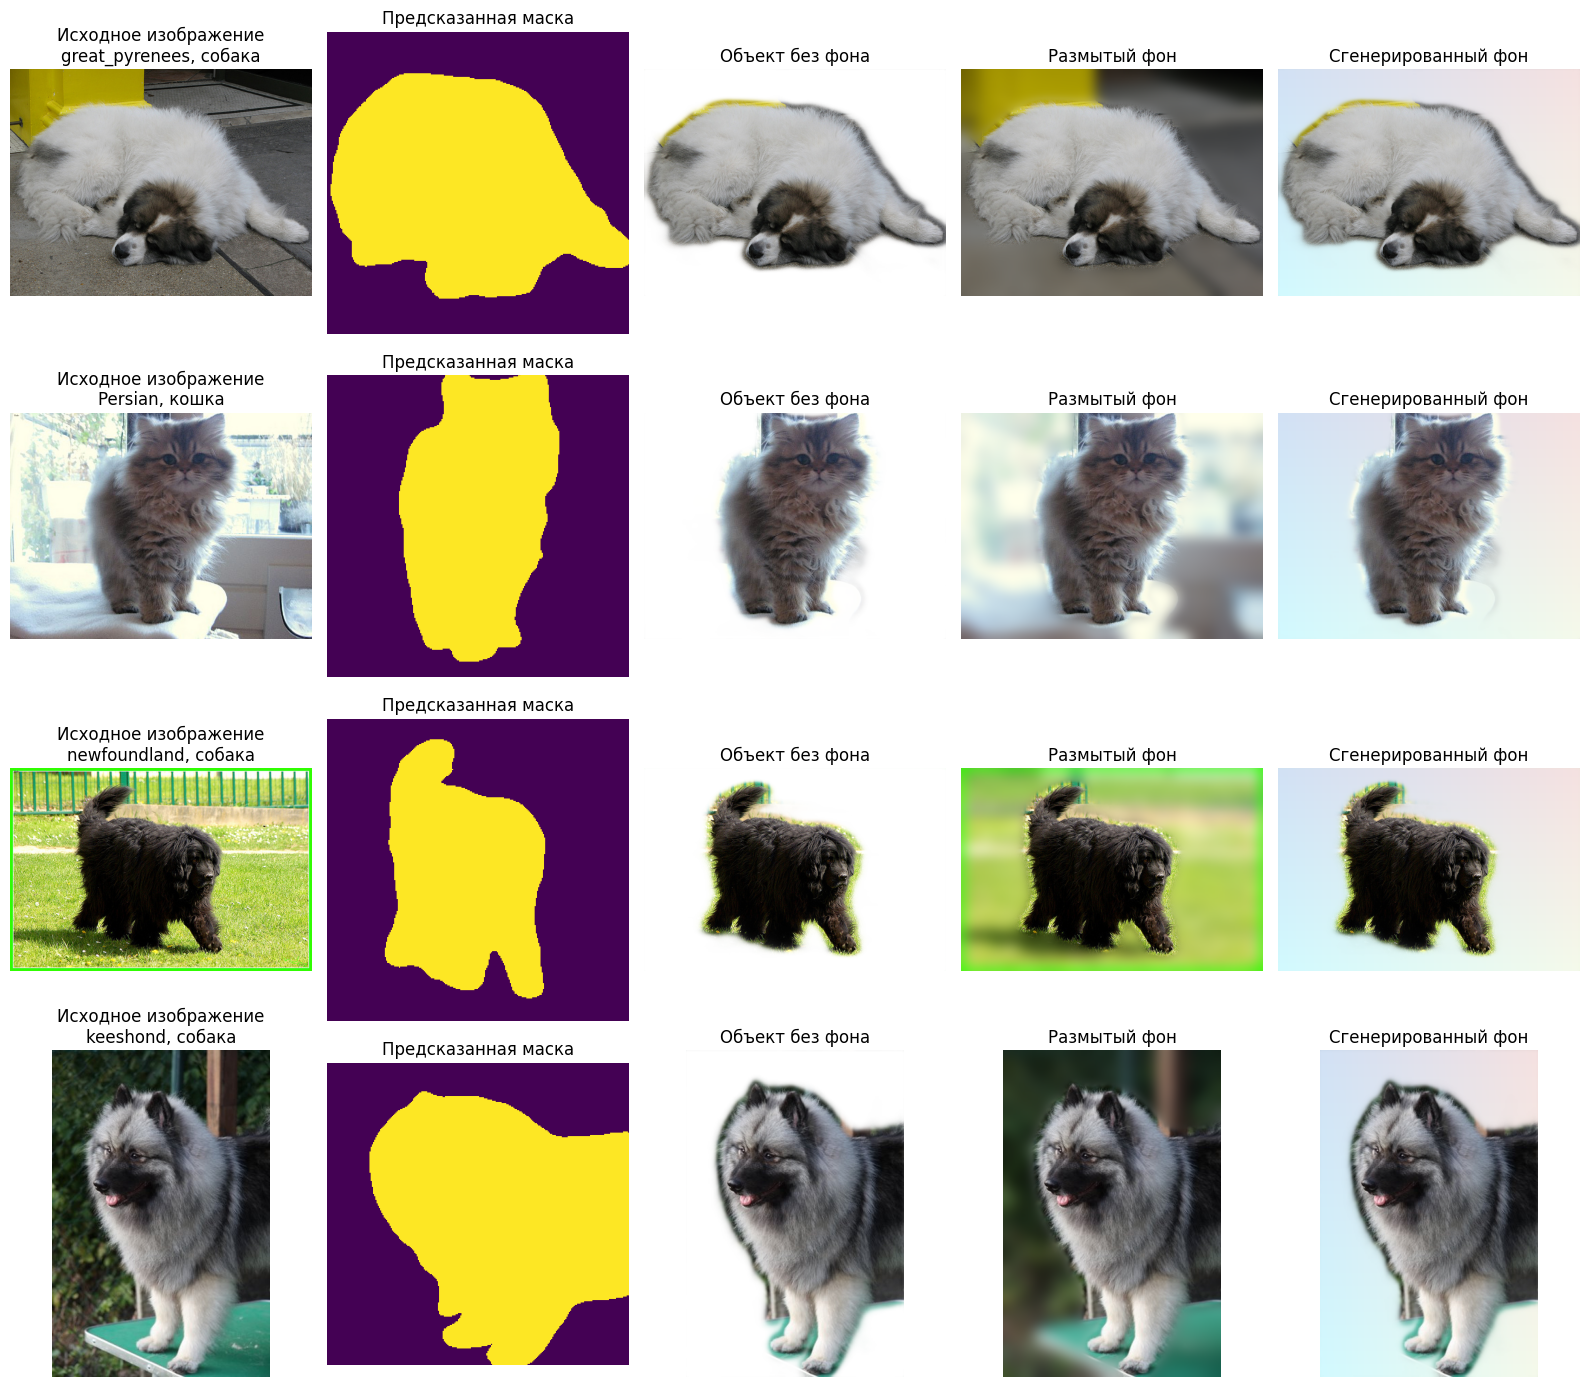

Рисунок с примерами обработки сохранен: /content/image_generation_processing_project/results/examples/segmentation_guided_processing_examples.png


In [54]:
# Строим общий рисунок с результатами обработки.
if len(processed_samples_table) == 0:
    raise ValueError("Нет подготовленных примеров для построения рисунка")

rows_to_show = min(4, len(processed_samples_table))

figure, axes = plt.subplots(
    nrows=rows_to_show,
    ncols=5,
    figsize=(16, 3.5 * rows_to_show)
)

if rows_to_show == 1:
    axes = np.expand_dims(axes, axis=0)

for row_index in range(rows_to_show):
    row = processed_samples_table.iloc[row_index]

    original_image = Image.open(row["original_path"]).convert("RGB")
    mask_image = Image.open(row["predicted_mask_path"]).convert("L")
    transparent_image = Image.open(row["transparent_object_path"]).convert("RGBA")
    blurred_image = Image.open(row["blurred_background_path"]).convert("RGB")
    generated_image = Image.open(row["generated_background_path"]).convert("RGB")

    title_text = row["breed_name"] + ", " + row["species_name_ru"]

    axes[row_index, 0].imshow(original_image)
    axes[row_index, 0].set_title("Исходное изображение\n" + title_text)
    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(mask_image)
    axes[row_index, 1].set_title("Предсказанная маска")
    axes[row_index, 1].axis("off")

    axes[row_index, 2].imshow(transparent_image)
    axes[row_index, 2].set_title("Объект без фона")
    axes[row_index, 2].axis("off")

    axes[row_index, 3].imshow(blurred_image)
    axes[row_index, 3].set_title("Размытый фон")
    axes[row_index, 3].axis("off")

    axes[row_index, 4].imshow(generated_image)
    axes[row_index, 4].set_title("Сгенерированный фон")
    axes[row_index, 4].axis("off")

plt.tight_layout()

processing_examples_figure_path = examples_dir / "segmentation_guided_processing_examples.png"
plt.savefig(processing_examples_figure_path, dpi=200, bbox_inches="tight")
plt.show()

print("Рисунок с примерами обработки сохранен:", processing_examples_figure_path)

In [55]:
# Формируем настройки применения модели.
inference_config = {
    "model_name": "segmentation_improved_unet_resnet34",
    "architecture": "Unet",
    "encoder_name": encoder_name_for_export,
    "model_file": "segmentation_improved_unet_resnet34_best.pt",
    "image_size": int(image_size_for_export),
    "image_mean": IMAGE_MEAN.tolist(),
    "image_std": IMAGE_STD.tolist(),
    "threshold": float(threshold_for_export),
    "available_processing_modes": [
        "получение бинарной маски",
        "выделение объекта на прозрачном фоне",
        "размытие фона",
        "замена фона на сгенерированный простой фон"
    ],
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

inference_config_path = export_dir / "segmentation_inference_config.json"

with open(inference_config_path, "w", encoding="utf-8") as file:
    json.dump(inference_config, file, ensure_ascii=False, indent=4)

# Создаем отдельный программный модуль.
# Модуль можно будет перенести в пользовательское приложение.
inference_module_code = r'''
from pathlib import Path

import numpy as np
import torch
from PIL import Image, ImageFilter, ImageOps
import segmentation_models_pytorch as smp


def create_model(encoder_name):
    model = smp.Unet(
        encoder_name=encoder_name,
        encoder_weights=None,
        in_channels=3,
        classes=1,
        activation=None,
    )
    return model


def load_checkpoint_safely(checkpoint_path, device):
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
    except TypeError:
        checkpoint = torch.load(checkpoint_path, map_location=device)
    except Exception:
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    return checkpoint


def load_segmentation_model(model_path, encoder_name="resnet34", device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    checkpoint = load_checkpoint_safely(model_path, device)

    model = create_model(encoder_name=checkpoint.get("encoder_name", encoder_name))
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()

    return model, checkpoint, device


def prepare_image_for_model(pil_image, image_size, image_mean, image_std):
    image = ImageOps.exif_transpose(pil_image.convert("RGB"))
    resized_image = image.resize((image_size, image_size), resample=Image.BILINEAR)

    image_array = np.array(resized_image).astype(np.float32) / 255.0

    mean_array = np.array(image_mean, dtype=np.float32).reshape(1, 1, 3)
    std_array = np.array(image_std, dtype=np.float32).reshape(1, 1, 3)

    normalized_array = (image_array - mean_array) / std_array
    tensor = torch.from_numpy(normalized_array).permute(2, 0, 1).unsqueeze(0).float()

    return tensor


def predict_mask(model, pil_image, config, device):
    image_size = int(config["image_size"])
    image_mean = config["image_mean"]
    image_std = config["image_std"]
    threshold = float(config["threshold"])

    input_tensor = prepare_image_for_model(
        pil_image=pil_image,
        image_size=image_size,
        image_mean=image_mean,
        image_std=image_std,
    ).to(device)

    with torch.no_grad():
        logits = model(input_tensor)
        probability = torch.sigmoid(logits)[0, 0].detach().cpu().numpy()

    binary_mask = (probability > threshold).astype(np.uint8)

    return probability, binary_mask


def create_generated_background(width, height):
    x_values = np.linspace(0.0, 1.0, width, dtype=np.float32)
    y_values = np.linspace(0.0, 1.0, height, dtype=np.float32)

    x_grid, y_grid = np.meshgrid(x_values, y_values)

    red_channel = 210 + 35 * x_grid
    green_channel = 225 + 25 * y_grid
    blue_channel = 245 - 20 * x_grid + 10 * y_grid

    background = np.stack([red_channel, green_channel, blue_channel], axis=2)
    background = np.clip(background, 0, 255).astype(np.uint8)

    return Image.fromarray(background, mode="RGB")


def process_image_with_mask(pil_image, probability_mask):
    image = ImageOps.exif_transpose(pil_image.convert("RGB"))
    width, height = image.size

    probability_image = Image.fromarray(
        (probability_mask * 255).astype(np.uint8),
        mode="L",
    )
    probability_image = probability_image.resize((width, height), resample=Image.BILINEAR)
    soft_alpha = probability_image.filter(ImageFilter.GaussianBlur(radius=1.0))

    transparent_object = image.convert("RGBA")
    transparent_object.putalpha(soft_alpha)

    blurred_background = image.filter(ImageFilter.GaussianBlur(radius=10))
    image_with_blurred_background = Image.composite(
        image,
        blurred_background,
        soft_alpha,
    )

    generated_background = create_generated_background(width, height)
    image_with_generated_background = Image.composite(
        image,
        generated_background,
        soft_alpha,
    )

    return {
        "transparent_object": transparent_object,
        "blurred_background": image_with_blurred_background,
        "generated_background": image_with_generated_background,
        "alpha_mask": soft_alpha,
    }


def run_full_processing(image_path, model_path, config, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    model, checkpoint, device = load_segmentation_model(
        model_path=model_path,
        encoder_name=config.get("encoder_name", "resnet34"),
    )

    image = Image.open(image_path).convert("RGB")

    probability, binary_mask = predict_mask(
        model=model,
        pil_image=image,
        config=config,
        device=device,
    )

    processed = process_image_with_mask(
        pil_image=image,
        probability_mask=probability,
    )

    Image.fromarray((binary_mask * 255).astype(np.uint8), mode="L").save(
        output_dir / "predicted_mask.png"
    )
    processed["transparent_object"].save(output_dir / "object_transparent.png")
    processed["blurred_background"].save(output_dir / "background_blurred.png")
    processed["generated_background"].save(output_dir / "background_generated.png")

    return {
        "predicted_mask": output_dir / "predicted_mask.png",
        "object_transparent": output_dir / "object_transparent.png",
        "background_blurred": output_dir / "background_blurred.png",
        "background_generated": output_dir / "background_generated.png",
    }
'''

inference_module_path = export_dir / "segmentation_inference_app_core.py"

with open(inference_module_path, "w", encoding="utf-8") as file:
    file.write(inference_module_code)

print("Файл настроек применения модели сохранен:", inference_config_path)
print("Программный модуль для приложения сохранен:", inference_module_path)

Файл настроек применения модели сохранен: /content/image_generation_processing_project/results/export/segmentation_inference_config.json
Программный модуль для приложения сохранен: /content/image_generation_processing_project/results/export/segmentation_inference_app_core.py


In [56]:
# Формируем отдельный каталог с файлами, которые понадобятся пользовательскому приложению.
app_artifacts_dir = export_dir / "image_processing_app_artifacts"

if app_artifacts_dir.exists():
    shutil.rmtree(app_artifacts_dir)

app_artifacts_dir.mkdir(parents=True, exist_ok=True)

# Копируем веса модели и настройки.
shutil.copy2(best_model_path, app_artifacts_dir / best_model_path.name)
shutil.copy2(inference_config_path, app_artifacts_dir / inference_config_path.name)
shutil.copy2(inference_module_path, app_artifacts_dir / inference_module_path.name)

# Копируем контрольные показатели и примеры.
shutil.copy2(control_metrics_path, app_artifacts_dir / control_metrics_path.name)
shutil.copy2(validation_control_comparison_path, app_artifacts_dir / validation_control_comparison_path.name)
shutil.copy2(validation_control_summary_path, app_artifacts_dir / validation_control_summary_path.name)
shutil.copy2(processed_samples_manifest_path, app_artifacts_dir / processed_samples_manifest_path.name)
shutil.copy2(processing_examples_figure_path, app_artifacts_dir / processing_examples_figure_path.name)

# Копируем несколько обработанных примеров.
artifact_examples_dir = app_artifacts_dir / "processed_examples"
artifact_examples_dir.mkdir(parents=True, exist_ok=True)

for sample_directory in processed_dir.iterdir():
    if sample_directory.is_dir():
        shutil.copytree(
            sample_directory,
            artifact_examples_dir / sample_directory.name,
            dirs_exist_ok=True
        )

# Создаем краткое описание состава архива.
readme_text = """
Артефакты пользовательского приложения

Состав:
1. segmentation_improved_unet_resnet34_best.pt — веса лучшей модели сегментации.
2. segmentation_inference_config.json — настройки применения модели.
3. segmentation_inference_app_core.py — программный модуль для получения маски и обработки изображения.
4. segmentation_improved_control_metrics.json — показатели качества на контрольной части.
5. segmentation_validation_control_comparison.csv — сравнение проверочной и контрольной частей.
6. processed_examples — примеры обработки изображений по предсказанной маске.

Назначение:
Архив используется как основа для пользовательского приложения, которое принимает изображение, строит маску объекта и выполняет обработку изображения: выделение объекта, размытие фона и замену фона.
""".strip()

readme_path = app_artifacts_dir / "README.txt"

with open(readme_path, "w", encoding="utf-8") as file:
    file.write(readme_text)

# Создаем архив.
archive_base_path = export_dir / "image_processing_app_artifacts"
archive_path = shutil.make_archive(
    base_name=str(archive_base_path),
    format="zip",
    root_dir=app_artifacts_dir
)

archive_path = Path(archive_path)

print("Каталог артефактов приложения:", app_artifacts_dir)
print("Архив артефактов создан:", archive_path)
print("Размер архива в мегабайтах:", round(archive_path.stat().st_size / (1024 * 1024), 2))

Каталог артефактов приложения: /content/image_generation_processing_project/results/export/image_processing_app_artifacts
Архив артефактов создан: /content/image_generation_processing_project/results/export/image_processing_app_artifacts.zip
Размер архива в мегабайтах: 95.12


In [57]:
# Копируем результаты этапа на Google Drive.
drive_models_dir = DRIVE_PROJECT_DIR / "models"
drive_metrics_dir = DRIVE_PROJECT_DIR / "metrics"
drive_figures_dir = DRIVE_PROJECT_DIR / "figures"
drive_examples_dir = DRIVE_PROJECT_DIR / "examples"
drive_export_dir = DRIVE_PROJECT_DIR / "export"

for directory in [drive_models_dir, drive_metrics_dir, drive_figures_dir, drive_examples_dir, drive_export_dir]:
    directory.mkdir(parents=True, exist_ok=True)

files_to_copy = [
    control_metrics_path,
    validation_control_comparison_path,
    validation_control_summary_path,
    processed_samples_manifest_path,
    processing_examples_figure_path,
    inference_config_path,
    inference_module_path,
    archive_path,
]

for source_path in files_to_copy:
    source_path = Path(source_path)

    if source_path.suffix in [".csv", ".json"]:
        destination_path = drive_metrics_dir / source_path.name
    elif source_path.suffix == ".png":
        destination_path = drive_examples_dir / source_path.name
    elif source_path.suffix in [".py", ".zip", ".txt"]:
        destination_path = drive_export_dir / source_path.name
    else:
        destination_path = drive_export_dir / source_path.name

    shutil.copy2(source_path, destination_path)
    print("Сохранено:", destination_path)

# Копируем каталог с примерами обработки на Google Drive.
drive_processed_examples_dir = drive_export_dir / "processed_examples"

if drive_processed_examples_dir.exists():
    shutil.rmtree(drive_processed_examples_dir)

shutil.copytree(
    processed_dir,
    drive_processed_examples_dir
)

print("Каталог с обработанными примерами сохранен:", drive_processed_examples_dir)
print("Результаты этапа 8 сохранены на Google Drive")

Сохранено: /content/drive/MyDrive/image_generation_processing_project/metrics/segmentation_improved_control_metrics.json
Сохранено: /content/drive/MyDrive/image_generation_processing_project/metrics/segmentation_validation_control_comparison.csv
Сохранено: /content/drive/MyDrive/image_generation_processing_project/metrics/segmentation_validation_control_summary.json
Сохранено: /content/drive/MyDrive/image_generation_processing_project/metrics/processed_samples_manifest.csv
Сохранено: /content/drive/MyDrive/image_generation_processing_project/examples/segmentation_guided_processing_examples.png
Сохранено: /content/drive/MyDrive/image_generation_processing_project/metrics/segmentation_inference_config.json
Сохранено: /content/drive/MyDrive/image_generation_processing_project/export/segmentation_inference_app_core.py
Сохранено: /content/drive/MyDrive/image_generation_processing_project/export/image_processing_app_artifacts.zip
Каталог с обработанными примерами сохранен: /content/drive/MyD

Контрольная часть подтверждает устойчивость модели: коэффициент Дайса снизился с 0,9396 до 0,9332, пересечение над объединением — с 0,8921 до 0,8830. Разница небольшая, поэтому признаков сильного переобучения не наблюдается. Модель пригодна для выгрузки в пользовательское приложение.

Научная новизна здесь уже прослеживается: сегментационная модель используется не только как самостоятельный модуль выделения животного, но и как управляющий блок для последующей обработки изображения: удаления фона, размытия фона и формирования нового фона. На этапе 9 добавляется еще один элемент новизны — экспертная оценка результата обработки с помощью нескольких моделей ChatGPT. Для экономии ключей используется малое число изображений и сжатые проверочные коллажи, поскольку изображения в запросах учитываются как токены и оплачиваются по объему входных данных. OpenAI поддерживает передачу изображений в виде адреса, закодированной строки или файла, а также предупреждает, что изображения расходуют токены; структурированный ответ через схему позволяет требовать от модели строго заданный формат результата.

# 9. Оценка качества обработки изображений с помощью моделей ChatGPT

На данном этапе выполняется дополнительная оценка результатов обработки изображений. Количественные показатели сегментации уже рассчитаны на проверочной и контрольной частях набора, однако для выпускной работы полезно добавить оценку визуального качества: насколько аккуратно выделен объект, насколько естественно выглядит размытый или сгенерированный фон, пригоден ли результат для пользовательского приложения.

Проверка выполняется через программный интерфейс сервиса ChatGPT, то есть через сетевое обращение к модели по ключу доступа. Для ограничения расхода ключей используются только несколько подготовленных примеров, уменьшенный размер изображений и короткий структурированный ответ. Результаты сохраняются в виде таблиц и сводных файлов, чтобы затем использовать их в тексте магистерской диссертации.

In [58]:
# ============================================================
# Этап 9. Оценка качества обработки изображений с помощью моделей ChatGPT
# ============================================================

# В данном блоке используются стандартные средства Python.
# Дополнительные библиотеки устанавливаются только при необходимости.

import os
import re
import io
import json
import time
import base64
import shutil
import urllib.request
import urllib.error
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Основные пути проекта
# ------------------------------------------------------------

PROJECT_DIR = Path("/content/image_generation_processing_project")
RESULTS_DIR = PROJECT_DIR / "results"
EXPORT_DIR = RESULTS_DIR / "export"
METRICS_DIR = RESULTS_DIR / "metrics"
FIGURES_DIR = RESULTS_DIR / "figures"
REPORTS_DIR = RESULTS_DIR / "reports"
EXAMPLES_DIR = RESULTS_DIR / "examples"

DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/image_generation_processing_project")

for directory in [METRICS_DIR, FIGURES_DIR, REPORTS_DIR, EXAMPLES_DIR, EXPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Каталог проекта:", PROJECT_DIR)
print("Каталог результатов:", RESULTS_DIR)
print("Каталог выгрузки:", EXPORT_DIR)

Каталог проекта: /content/image_generation_processing_project
Каталог результатов: /content/image_generation_processing_project/results
Каталог выгрузки: /content/image_generation_processing_project/results/export


In [61]:
# ------------------------------------------------------------
# 2. Загрузка настроек из файла окружения
# ------------------------------------------------------------

# Файл окружения хранит ключи доступа и названия моделей.
# Ключи не выводятся на экран, чтобы не раскрывать служебные данные.

ENV_CANDIDATES = [
    PROJECT_DIR / ".env",
    PROJECT_DIR / ".env.example",
    Path("/content/.env"),
    Path("/content/.env.example"),
    DRIVE_PROJECT_DIR / ".env",
    DRIVE_PROJECT_DIR / ".env.example",
]

def load_env_file(env_path: Path) -> dict:
    """
    Читает файл окружения.
    Файл окружения представляет собой обычный текстовый файл,
    где каждая строка имеет вид ИМЯ_ПАРАМЕТРА=значение.
    """
    result = {}

    if not env_path.exists():
        return result

    with open(env_path, "r", encoding="utf-8") as file:
        for raw_line in file:
            line = raw_line.strip()

            if not line or line.startswith("#"):
                continue

            if "=" not in line:
                continue

            key, value = line.split("=", 1)
            key = key.strip()
            value = value.strip().strip("'").strip('"')

            result[key] = value
            os.environ.setdefault(key, value)

    return result


loaded_env = {}
loaded_env_path = None

for candidate in ENV_CANDIDATES:
    candidate_values = load_env_file(candidate)
    if candidate_values:
        loaded_env = candidate_values
        loaded_env_path = candidate
        break

print("Файл окружения найден:", loaded_env_path is not None)

if loaded_env_path is not None:
    print("Использован файл окружения:", loaded_env_path)
else:
    print("Файл окружения не найден")
    print("Если проверка через модели ChatGPT нужна сейчас, необходимо загрузить файл .env в каталог проекта или в корень среды Colab")


# ------------------------------------------------------------
# 3. Получение настроек подключения
# ------------------------------------------------------------

PROXYAPI_API_KEY = os.getenv("PROXYAPI_API_KEY", "sk-OPoEkcu52ImrbAipDPohSxn5vkx1VZTB").strip()
OPENAI_BASE_URL = os.getenv("OPENAI_BASE_URL", "https://api.proxyapi.ru/openai/v1").strip()

# Для экономии средств по умолчанию используется не более двух моделей.
# Если в файле окружения есть LLM_EVAL_MODELS, берется этот список.
# Иначе используется MODEL_NAME и одна дополнительная экономичная модель.

raw_eval_models = os.getenv("LLM_EVAL_MODELS", "").strip()
single_model_name = os.getenv("MODEL_NAME", "gpt-4o").strip()

if raw_eval_models:
    EVAL_MODELS = [item.strip() for item in raw_eval_models.split(",") if item.strip()]
else:
    EVAL_MODELS = ["gpt-4o-mini", single_model_name]

# Убираем возможные повторы с сохранением порядка.
unique_models = []
for model_name in EVAL_MODELS:
    if model_name not in unique_models:
        unique_models.append(model_name)

EVAL_MODELS = unique_models[:2]

# Количество примеров ограничивается для уменьшения расхода ключей.
MAX_SAMPLES_FOR_LLM = int(os.getenv("LLM_EVAL_MAX_SAMPLES", "3"))
MAX_OUTPUT_TOKENS = int(os.getenv("LLM_EVAL_MAX_TOKENS", "450"))
LLM_TEMPERATURE = float(os.getenv("LLM_TEMPERATURE", "0.0"))

print("Адрес обращения к сервису:", OPENAI_BASE_URL)
print("Количество моделей для проверки:", len(EVAL_MODELS))
print("Модели для проверки:", EVAL_MODELS)
print("Максимальное количество изображений для проверки:", MAX_SAMPLES_FOR_LLM)
print("Ключ доступа задан:", bool(PROXYAPI_API_KEY))

Файл окружения найден: False
Файл окружения не найден
Если проверка через модели ChatGPT нужна сейчас, необходимо загрузить файл .env в каталог проекта или в корень среды Colab
Адрес обращения к сервису: https://api.proxyapi.ru/openai/v1
Количество моделей для проверки: 2
Модели для проверки: ['gpt-4o-mini', 'gpt-4o']
Максимальное количество изображений для проверки: 3
Ключ доступа задан: True


In [62]:
# ------------------------------------------------------------
# 4. Подготовка проверочных коллажей
# ------------------------------------------------------------

# Для оценки модели передается не исходный набор файлов по отдельности,
# а один уменьшенный коллаж на каждый пример.
# Такой подход снижает объем изображения в запросе и уменьшает расход ключей.

processed_manifest_path = METRICS_DIR / "processed_samples_manifest.csv"

if not processed_manifest_path.exists():
    raise FileNotFoundError(
        "Не найден файл с обработанными примерами: "
        f"{processed_manifest_path}. Сначала должен быть выполнен этап 8."
    )

processed_manifest = pd.read_csv(processed_manifest_path)

required_columns = [
    "image_id",
    "breed_name",
    "species_name_ru",
    "original_path",
    "predicted_mask_path",
    "transparent_object_path",
    "blurred_background_path",
    "generated_background_path",
]

missing_columns = [column for column in required_columns if column not in processed_manifest.columns]

if missing_columns:
    raise ValueError(
        "В таблице обработанных примеров не хватает столбцов: "
        + ", ".join(missing_columns)
    )

print("Таблица обработанных примеров загружена")
print("Количество доступных примеров:", len(processed_manifest))
display(processed_manifest.head())


LLM_INPUT_DIR = EXPORT_DIR / "llm_evaluation_inputs"
LLM_INPUT_DIR.mkdir(parents=True, exist_ok=True)


def open_image_safely(path_value: str) -> Image.Image:
    """
    Открывает изображение и приводит его к цветовой системе с тремя каналами.
    Три канала соответствуют красной, зеленой и синей составляющим цвета.
    """
    path = Path(path_value)

    if not path.exists():
        raise FileNotFoundError(f"Файл изображения не найден: {path}")

    return Image.open(path).convert("RGB")


def resize_keep_ratio(image: Image.Image, target_height: int = 220) -> Image.Image:
    """
    Изменяет размер изображения с сохранением пропорций.
    Это нужно для создания компактного коллажа.
    """
    width, height = image.size

    if height == 0:
        raise ValueError("Высота изображения равна нулю")

    new_width = int(width * target_height / height)
    return image.resize((new_width, target_height), Image.Resampling.LANCZOS)


def make_labeled_tile(image: Image.Image, title: str, tile_width: int = 260, tile_height: int = 270) -> Image.Image:
    """
    Создает одну часть коллажа с подписью.
    Подпись помогает модели понять, какой вариант обработки показан.
    """
    canvas = Image.new("RGB", (tile_width, tile_height), "white")
    draw = ImageDraw.Draw(canvas)

    prepared = resize_keep_ratio(image, target_height=210)

    if prepared.width > tile_width:
        new_height = int(prepared.height * tile_width / prepared.width)
        prepared = prepared.resize((tile_width, new_height), Image.Resampling.LANCZOS)

    x = (tile_width - prepared.width) // 2
    y = 45

    draw.text((10, 10), title, fill="black")
    canvas.paste(prepared, (x, y))

    return canvas


def make_evaluation_collage(row: pd.Series, output_path: Path) -> Path:
    """
    Создает коллаж для оценки качества обработки.
    В одном изображении показываются исходное изображение и три результата обработки.
    """
    original = open_image_safely(row["original_path"])
    transparent = open_image_safely(row["transparent_object_path"])
    blurred = open_image_safely(row["blurred_background_path"])
    generated = open_image_safely(row["generated_background_path"])

    tiles = [
        make_labeled_tile(original, "1. Исходное изображение"),
        make_labeled_tile(transparent, "2. Объект без фона"),
        make_labeled_tile(blurred, "3. Размытый фон"),
        make_labeled_tile(generated, "4. Новый фон"),
    ]

    tile_width, tile_height = tiles[0].size
    collage = Image.new("RGB", (tile_width * 2, tile_height * 2), "white")

    positions = [
        (0, 0),
        (tile_width, 0),
        (0, tile_height),
        (tile_width, tile_height),
    ]

    for tile, position in zip(tiles, positions):
        collage.paste(tile, position)

    # Сохраняем с умеренным качеством, чтобы уменьшить размер запроса.
    collage.save(output_path, format="JPEG", quality=82, optimize=True)

    return output_path


selected_samples = processed_manifest.head(MAX_SAMPLES_FOR_LLM).copy()
collage_paths = []

for _, row in selected_samples.iterrows():
    output_path = LLM_INPUT_DIR / f"{row['image_id']}_llm_review.jpg"
    make_evaluation_collage(row, output_path)
    collage_paths.append(str(output_path))

selected_samples["llm_collage_path"] = collage_paths

llm_input_manifest_path = METRICS_DIR / "llm_evaluation_input_manifest.csv"
selected_samples.to_csv(llm_input_manifest_path, index=False, encoding="utf-8-sig")

print("Подготовлено коллажей для проверки:", len(selected_samples))
print("Файл со списком коллажей сохранен:", llm_input_manifest_path)
display(selected_samples[["image_id", "breed_name", "species_name_ru", "llm_collage_path"]])

Таблица обработанных примеров загружена
Количество доступных примеров: 6


,image_id,breed_name,species_name_ru,original_path,predicted_mask_path,transparent_object_path,blurred_background_path,generated_background_path
0,great_pyrenees_195,great_pyrenees,собака,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...
1,Persian_137,Persian,кошка,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...
2,newfoundland_99,newfoundland,собака,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...
3,keeshond_8,keeshond,собака,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...
4,chihuahua_46,chihuahua,собака,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...,/content/image_generation_processing_project/r...


Подготовлено коллажей для проверки: 3
Файл со списком коллажей сохранен: /content/image_generation_processing_project/results/metrics/llm_evaluation_input_manifest.csv


,image_id,breed_name,species_name_ru,llm_collage_path
0,great_pyrenees_195,great_pyrenees,собака,/content/image_generation_processing_project/r...
1,Persian_137,Persian,кошка,/content/image_generation_processing_project/r...
2,newfoundland_99,newfoundland,собака,/content/image_generation_processing_project/r...


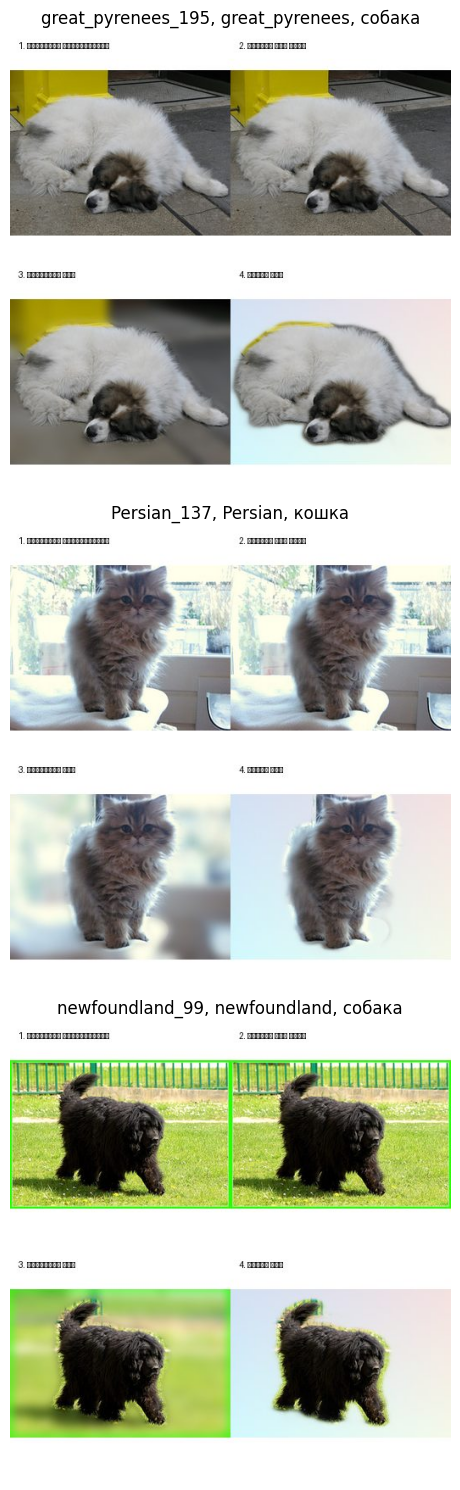

Рисунок с проверочными коллажами сохранен: /content/image_generation_processing_project/results/examples/llm_evaluation_input_collages.png


In [63]:
# ------------------------------------------------------------
# 5. Просмотр подготовленных коллажей
# ------------------------------------------------------------

# Перед отправкой в модель полезно визуально проверить,
# что коллажи собраны правильно и содержат все варианты обработки.

preview_count = min(3, len(selected_samples))

fig, axes = plt.subplots(preview_count, 1, figsize=(10, 5 * preview_count))

if preview_count == 1:
    axes = [axes]

for axis, (_, row) in zip(axes, selected_samples.head(preview_count).iterrows()):
    image = Image.open(row["llm_collage_path"]).convert("RGB")
    axis.imshow(image)
    axis.set_title(f"{row['image_id']}, {row['breed_name']}, {row['species_name_ru']}")
    axis.axis("off")

plt.tight_layout()

preview_path = EXAMPLES_DIR / "llm_evaluation_input_collages.png"
plt.savefig(preview_path, dpi=160, bbox_inches="tight")
plt.show()

print("Рисунок с проверочными коллажами сохранен:", preview_path)

In [64]:
# ------------------------------------------------------------
# 6. Функции обращения к моделям ChatGPT
# ------------------------------------------------------------

# Запрос выполняется через сетевой протокол передачи данных.
# Изображение кодируется в текстовую строку, чтобы передать его внутри запроса.
# Ответ ожидается в строгом структурированном виде.

def encode_image_to_data_url(image_path: str) -> str:
    """
    Кодирует изображение в текстовую строку.
    Такая строка позволяет передать изображение прямо в запросе.
    """
    path = Path(image_path)

    with open(path, "rb") as image_file:
        encoded = base64.b64encode(image_file.read()).decode("utf-8")

    return f"data:image/jpeg;base64,{encoded}"


def build_review_schema() -> dict:
    """
    Создает схему ответа.
    Схема задает перечень полей, которые модель должна вернуть.
    """
    return {
        "name": "image_processing_review",
        "strict": True,
        "schema": {
            "type": "object",
            "additionalProperties": False,
            "properties": {
                "object_boundary_score": {
                    "type": "integer",
                    "minimum": 1,
                    "maximum": 5,
                    "description": "Оценка точности границы объекта от 1 до 5"
                },
                "background_quality_score": {
                    "type": "integer",
                    "minimum": 1,
                    "maximum": 5,
                    "description": "Оценка качества обработки фона от 1 до 5"
                },
                "visual_naturalness_score": {
                    "type": "integer",
                    "minimum": 1,
                    "maximum": 5,
                    "description": "Оценка естественности результата от 1 до 5"
                },
                "application_readiness_score": {
                    "type": "integer",
                    "minimum": 1,
                    "maximum": 5,
                    "description": "Оценка пригодности результата для приложения от 1 до 5"
                },
                "main_problem": {
                    "type": "string",
                    "description": "Главная визуальная проблема результата"
                },
                "best_variant": {
                    "type": "string",
                    "description": "Лучший вариант обработки среди объекта без фона, размытого фона и нового фона"
                },
                "short_explanation": {
                    "type": "string",
                    "description": "Краткое объяснение оценки на русском языке"
                }
            },
            "required": [
                "object_boundary_score",
                "background_quality_score",
                "visual_naturalness_score",
                "application_readiness_score",
                "main_problem",
                "best_variant",
                "short_explanation"
            ]
        }
    }


def extract_json_from_text(text: str) -> dict:
    """
    Извлекает структурированный ответ из текста.
    Эта функция нужна на случай, если модель вернет пояснение вместе со структурированными данными.
    """
    try:
        return json.loads(text)
    except Exception:
        pass

    match = re.search(r"\{.*\}", text, flags=re.DOTALL)

    if not match:
        raise ValueError("В ответе модели не найден структурированный фрагмент")

    return json.loads(match.group(0))


def call_chat_model_for_image(model_name: str, image_path: str, image_id: str, breed_name: str, species_name_ru: str) -> dict:
    """
    Отправляет один коллаж в одну модель и возвращает результат оценки.
    """
    if not PROXYAPI_API_KEY:
        raise RuntimeError(
            "Ключ PROXYAPI_API_KEY не задан. "
            "Добавьте ключ в файл .env и повторите выполнение этапа."
        )

    endpoint = OPENAI_BASE_URL.rstrip("/") + "/chat/completions"
    image_data_url = encode_image_to_data_url(image_path)

    system_text = (
        "Ты выступаешь как эксперт по качеству нейросетевой обработки изображений. "
        "Нужно оценить результат сегментации и замены фона. "
        "Оценивай строго по видимому изображению. "
        "Верни только структурированные данные без лишнего текста."
    )

    user_text = (
        "На коллаже показаны четыре части: исходное изображение, объект без фона, "
        "изображение с размытым фоном и изображение с новым фоном. "
        f"Идентификатор изображения: {image_id}. "
        f"Порода: {breed_name}. "
        f"Вид животного: {species_name_ru}. "
        "Поставь оценки от 1 до 5 по точности границы объекта, качеству обработки фона, "
        "естественности результата и пригодности результата для пользовательского приложения. "
        "Кратко укажи главную проблему и лучший вариант обработки."
    )

    payload = {
        "model": model_name,
        "temperature": LLM_TEMPERATURE,
        "max_tokens": MAX_OUTPUT_TOKENS,
        "messages": [
            {
                "role": "system",
                "content": system_text,
            },
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": user_text,
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": image_data_url,
                        },
                    },
                ],
            },
        ],
        "response_format": {
            "type": "json_schema",
            "json_schema": build_review_schema(),
        },
    }

    request = urllib.request.Request(
        endpoint,
        data=json.dumps(payload).encode("utf-8"),
        headers={
            "Content-Type": "application/json",
            "Authorization": f"Bearer {PROXYAPI_API_KEY}",
        },
        method="POST",
    )

    start_time = time.time()

    try:
        with urllib.request.urlopen(request, timeout=90) as response:
            response_text = response.read().decode("utf-8")
    except urllib.error.HTTPError as error:
        error_text = error.read().decode("utf-8", errors="replace")

        # Некоторые промежуточные сервисы могут не поддерживать строгую схему.
        # В таком случае выполняется повторная попытка с требованием обычного структурированного объекта.
        if "json_schema" in error_text or error.code in [400, 422]:
            payload["response_format"] = {"type": "json_object"}

            fallback_request = urllib.request.Request(
                endpoint,
                data=json.dumps(payload).encode("utf-8"),
                headers={
                    "Content-Type": "application/json",
                    "Authorization": f"Bearer {PROXYAPI_API_KEY}",
                },
                method="POST",
            )

            with urllib.request.urlopen(fallback_request, timeout=90) as response:
                response_text = response.read().decode("utf-8")
        else:
            raise RuntimeError(
                f"Ошибка обращения к модели {model_name}. "
                f"Код: {error.code}. Текст: {error_text[:1000]}"
            )

    elapsed_seconds = time.time() - start_time
    response_json = json.loads(response_text)

    content = response_json["choices"][0]["message"]["content"]
    review = extract_json_from_text(content)

    review["model_name"] = model_name
    review["image_id"] = image_id
    review["breed_name"] = breed_name
    review["species_name_ru"] = species_name_ru
    review["image_path"] = image_path
    review["request_time_seconds"] = round(elapsed_seconds, 3)

    usage = response_json.get("usage", {})
    review["prompt_tokens"] = usage.get("prompt_tokens")
    review["completion_tokens"] = usage.get("completion_tokens")
    review["total_tokens"] = usage.get("total_tokens")

    return review


print("Функции обращения к моделям подготовлены")

Функции обращения к моделям подготовлены


In [65]:
# ------------------------------------------------------------
# 7. Выполнение оценки через модели ChatGPT
# ------------------------------------------------------------

# Число запросов равно произведению количества моделей на количество изображений.
# При двух моделях и трех изображениях выполняется шесть запросов.

expected_request_count = len(EVAL_MODELS) * len(selected_samples)

print("Планируемое количество запросов:", expected_request_count)
print("Модели:", EVAL_MODELS)
print("Количество изображений:", len(selected_samples))

all_reviews = []

for model_name in EVAL_MODELS:
    for _, row in selected_samples.iterrows():
        print("Оценивается:", model_name, "|", row["image_id"])

        review = call_chat_model_for_image(
            model_name=model_name,
            image_path=row["llm_collage_path"],
            image_id=row["image_id"],
            breed_name=row["breed_name"],
            species_name_ru=row["species_name_ru"],
        )

        all_reviews.append(review)

        # Небольшая пауза снижает риск ограничения по частоте обращений.
        time.sleep(1.0)

llm_reviews = pd.DataFrame(all_reviews)

llm_reviews_path = METRICS_DIR / "llm_image_processing_reviews.csv"
llm_reviews.to_csv(llm_reviews_path, index=False, encoding="utf-8-sig")

print("Оценка через модели завершена")
print("Таблица оценок сохранена:", llm_reviews_path)
display(llm_reviews)

Планируемое количество запросов: 6
Модели: ['gpt-4o-mini', 'gpt-4o']
Количество изображений: 3
Оценивается: gpt-4o-mini | great_pyrenees_195
Оценивается: gpt-4o-mini | Persian_137
Оценивается: gpt-4o-mini | newfoundland_99
Оценивается: gpt-4o | great_pyrenees_195
Оценивается: gpt-4o | Persian_137
Оценивается: gpt-4o | newfoundland_99
Оценка через модели завершена
Таблица оценок сохранена: /content/image_generation_processing_project/results/metrics/llm_image_processing_reviews.csv


,object_boundary_score,background_quality_score,visual_naturalness_score,application_readiness_score,main_problem,best_variant,short_explanation,model_name,image_id,breed_name,species_name_ru,image_path,request_time_seconds,prompt_tokens,completion_tokens,total_tokens
0,4,3,4,3,"Неправильное размытие фона, создающее неестест...",Объект без фона (изображение 2) выглядит наибо...,"Граница объекта хорошо выделена, но фон требуе...",gpt-4o-mini,great_pyrenees_195,great_pyrenees,собака,/content/image_generation_processing_project/r...,5.440,26682,95,26777
1,4,3,3,4,"Неправильная обработка фона, что снижает естес...",Объект без фона (изображение 2) выглядит наибо...,"Граница объекта хорошо выделена, но фон требуе...",gpt-4o-mini,Persian_137,Persian,кошка,/content/image_generation_processing_project/r...,4.474,26676,94,26770
2,4,3,3,4,"Неполное размытие фона, что создает резкий кон...",Объект без фона (изображение 2) выглядит наибо...,"Граница объекта четкая, но фон требует улучшен...",gpt-4o-mini,newfoundland_99,newfoundland,собака,/content/image_generation_processing_project/r...,5.152,26678,101,26779
3,4,4,4,4,Незначительные артефакты на границе объекта.,Изображение с размытым фоном.,"Обработка выполнена качественно, но есть небол...",gpt-4o,great_pyrenees_195,great_pyrenees,собака,/content/image_generation_processing_project/r...,2.998,1946,91,2037
4,4,4,4,4,Незначительные артефакты на границах объекта.,Изображение с размытым фоном.,"Обработка выполнена качественно, но есть небол...",gpt-4o,Persian_137,Persian,кошка,/content/image_generation_processing_project/r...,2.516,1940,93,2033
5,3,4,3,3,"Неровные границы объекта, особенно вокруг шерсти.",объект без фона,"Границы объекта выглядят неестественно, особен...",gpt-4o,newfoundland_99,newfoundland,собака,/content/image_generation_processing_project/r...,2.730,1942,78,2020


In [66]:
# ------------------------------------------------------------
# 8. Расчет сводных показателей по оценкам моделей
# ------------------------------------------------------------

# Сводная таблица нужна для сравнения моделей как визуальных экспертов.
# Итоговая оценка рассчитывается как среднее по четырем критериям.

score_columns = [
    "object_boundary_score",
    "background_quality_score",
    "visual_naturalness_score",
    "application_readiness_score",
]

for column in score_columns:
    llm_reviews[column] = pd.to_numeric(llm_reviews[column], errors="coerce")

llm_reviews["mean_visual_score"] = llm_reviews[score_columns].mean(axis=1)

summary_by_model = (
    llm_reviews
    .groupby("model_name", as_index=False)
    .agg(
        object_boundary_score=("object_boundary_score", "mean"),
        background_quality_score=("background_quality_score", "mean"),
        visual_naturalness_score=("visual_naturalness_score", "mean"),
        application_readiness_score=("application_readiness_score", "mean"),
        mean_visual_score=("mean_visual_score", "mean"),
        review_count=("image_id", "count"),
        total_tokens=("total_tokens", "sum"),
    )
)

summary_by_image = (
    llm_reviews
    .groupby(["image_id", "breed_name", "species_name_ru"], as_index=False)
    .agg(
        mean_visual_score=("mean_visual_score", "mean"),
        object_boundary_score=("object_boundary_score", "mean"),
        background_quality_score=("background_quality_score", "mean"),
        visual_naturalness_score=("visual_naturalness_score", "mean"),
        application_readiness_score=("application_readiness_score", "mean"),
    )
    .sort_values("mean_visual_score", ascending=False)
)

summary_by_model_path = METRICS_DIR / "llm_review_summary_by_model.csv"
summary_by_image_path = METRICS_DIR / "llm_review_summary_by_image.csv"

summary_by_model.to_csv(summary_by_model_path, index=False, encoding="utf-8-sig")
summary_by_image.to_csv(summary_by_image_path, index=False, encoding="utf-8-sig")

print("Сводка по моделям сохранена:", summary_by_model_path)
print("Сводка по изображениям сохранена:", summary_by_image_path)

print("Сводка по моделям:")
display(summary_by_model)

print("Сводка по изображениям:")
display(summary_by_image)

Сводка по моделям сохранена: /content/image_generation_processing_project/results/metrics/llm_review_summary_by_model.csv
Сводка по изображениям сохранена: /content/image_generation_processing_project/results/metrics/llm_review_summary_by_image.csv
Сводка по моделям:


,model_name,object_boundary_score,background_quality_score,visual_naturalness_score,application_readiness_score,mean_visual_score,review_count,total_tokens
0,gpt-4o,3.666667,4.0,3.666667,3.666667,3.75,3,6090
1,gpt-4o-mini,4.000000,3.0,3.333333,3.666667,3.50,3,80326


Сводка по изображениям:


,image_id,breed_name,species_name_ru,mean_visual_score,object_boundary_score,background_quality_score,visual_naturalness_score,application_readiness_score
0,Persian_137,Persian,кошка,3.750,4.0,3.5,3.5,4.0
1,great_pyrenees_195,great_pyrenees,собака,3.750,4.0,3.5,4.0,3.5
2,newfoundland_99,newfoundland,собака,3.375,3.5,3.5,3.0,3.5


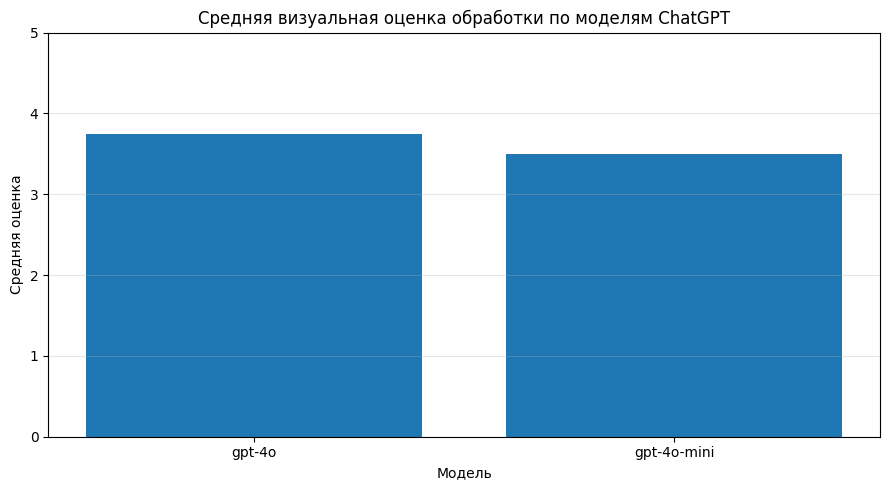

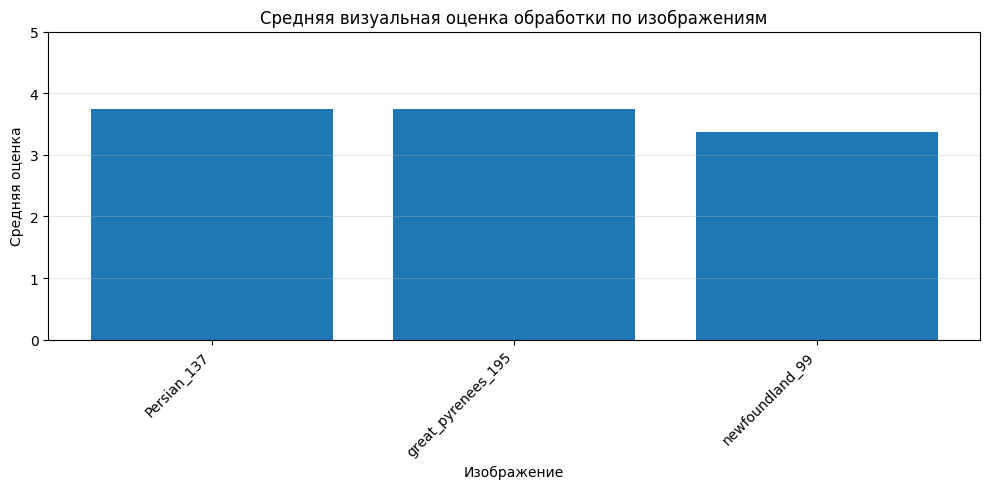

График по моделям сохранен: /content/image_generation_processing_project/results/figures/llm_mean_visual_score_by_model.png
График по изображениям сохранен: /content/image_generation_processing_project/results/figures/llm_mean_visual_score_by_image.png


In [67]:
# ------------------------------------------------------------
# 9. Построение графиков экспертной оценки
# ------------------------------------------------------------

# Графики нужны для последующего включения в раздел с экспериментами.
# Они показывают различия между моделями и среднее качество обработки.

plt.figure(figsize=(9, 5))
plt.bar(summary_by_model["model_name"], summary_by_model["mean_visual_score"])
plt.title("Средняя визуальная оценка обработки по моделям ChatGPT")
plt.xlabel("Модель")
plt.ylabel("Средняя оценка")
plt.ylim(0, 5)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

model_score_figure_path = FIGURES_DIR / "llm_mean_visual_score_by_model.png"
plt.savefig(model_score_figure_path, dpi=160, bbox_inches="tight")
plt.show()


plt.figure(figsize=(10, 5))
plt.bar(summary_by_image["image_id"], summary_by_image["mean_visual_score"])
plt.title("Средняя визуальная оценка обработки по изображениям")
plt.xlabel("Изображение")
plt.ylabel("Средняя оценка")
plt.ylim(0, 5)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

image_score_figure_path = FIGURES_DIR / "llm_mean_visual_score_by_image.png"
plt.savefig(image_score_figure_path, dpi=160, bbox_inches="tight")
plt.show()

print("График по моделям сохранен:", model_score_figure_path)
print("График по изображениям сохранен:", image_score_figure_path)

In [68]:
# ------------------------------------------------------------
# 10. Формирование итоговой сводки этапа
# ------------------------------------------------------------

# Итоговая сводка сохраняет основные параметры этапа.
# Она пригодится при описании методики в магистерской диссертации.

llm_stage_summary = {
    "stage_name": "llm_visual_evaluation",
    "stage_name_ru": "экспертная оценка обработки изображений с помощью моделей ChatGPT",
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "base_url": OPENAI_BASE_URL,
    "models": EVAL_MODELS,
    "sample_count": int(len(selected_samples)),
    "request_count": int(expected_request_count),
    "max_output_tokens": int(MAX_OUTPUT_TOKENS),
    "temperature": float(LLM_TEMPERATURE),
    "mean_score_by_model": summary_by_model.to_dict(orient="records"),
    "best_model_by_mean_visual_score": str(
        summary_by_model.sort_values("mean_visual_score", ascending=False).iloc[0]["model_name"]
    ),
    "best_image_by_mean_visual_score": str(
        summary_by_image.sort_values("mean_visual_score", ascending=False).iloc[0]["image_id"]
    ),
    "scientific_novelty_note": (
        "В эксперимент добавлена гибридная схема оценки, в которой пиксельные метрики "
        "сегментации дополняются визуальной экспертной оценкой нескольких моделей ChatGPT. "
        "Такой подход позволяет оценить не только совпадение маски с разметкой, "
        "но и прикладное качество результата для пользовательского приложения."
    ),
    "output_files": {
        "llm_reviews": str(llm_reviews_path),
        "summary_by_model": str(summary_by_model_path),
        "summary_by_image": str(summary_by_image_path),
        "model_score_figure": str(model_score_figure_path),
        "image_score_figure": str(image_score_figure_path),
        "input_manifest": str(llm_input_manifest_path),
        "input_preview": str(preview_path),
    },
}

llm_stage_summary_path = REPORTS_DIR / "llm_visual_evaluation_summary.json"

with open(llm_stage_summary_path, "w", encoding="utf-8") as file:
    json.dump(llm_stage_summary, file, ensure_ascii=False, indent=2)

print("Итоговая сводка этапа сохранена:", llm_stage_summary_path)

for key, value in llm_stage_summary.items():
    if key not in ["mean_score_by_model", "output_files"]:
        print(key, ":", value)

Итоговая сводка этапа сохранена: /content/image_generation_processing_project/results/reports/llm_visual_evaluation_summary.json
stage_name : llm_visual_evaluation
stage_name_ru : экспертная оценка обработки изображений с помощью моделей ChatGPT
created_at : 2026-05-04 01:16:19
base_url : https://api.proxyapi.ru/openai/v1
models : ['gpt-4o-mini', 'gpt-4o']
sample_count : 3
request_count : 6
max_output_tokens : 450
temperature : 0.0
best_model_by_mean_visual_score : gpt-4o
best_image_by_mean_visual_score : Persian_137
scientific_novelty_note : В эксперимент добавлена гибридная схема оценки, в которой пиксельные метрики сегментации дополняются визуальной экспертной оценкой нескольких моделей ChatGPT. Такой подход позволяет оценить не только совпадение маски с разметкой, но и прикладное качество результата для пользовательского приложения.


In [69]:
# ------------------------------------------------------------
# 11. Сохранение результатов этапа на Google Drive
# ------------------------------------------------------------

# Сохраняем только важные файлы, чтобы затем перенести их на рабочий компьютер
# и использовать при создании пользовательского приложения и текста диссертации.

drive_metrics_dir = DRIVE_PROJECT_DIR / "metrics"
drive_figures_dir = DRIVE_PROJECT_DIR / "figures"
drive_reports_dir = DRIVE_PROJECT_DIR / "reports"
drive_examples_dir = DRIVE_PROJECT_DIR / "examples"
drive_export_dir = DRIVE_PROJECT_DIR / "export"

for directory in [
    drive_metrics_dir,
    drive_figures_dir,
    drive_reports_dir,
    drive_examples_dir,
    drive_export_dir,
]:
    directory.mkdir(parents=True, exist_ok=True)


files_to_copy = [
    llm_reviews_path,
    summary_by_model_path,
    summary_by_image_path,
    llm_input_manifest_path,
    model_score_figure_path,
    image_score_figure_path,
    preview_path,
    llm_stage_summary_path,
]

for source_path in files_to_copy:
    source_path = Path(source_path)

    if not source_path.exists():
        print("Файл не найден и не будет сохранен:", source_path)
        continue

    if source_path.suffix.lower() in [".png", ".jpg", ".jpeg"]:
        target_dir = drive_figures_dir if "score" in source_path.name else drive_examples_dir
    elif source_path.suffix.lower() == ".json":
        target_dir = drive_reports_dir
    else:
        target_dir = drive_metrics_dir

    target_path = target_dir / source_path.name
    shutil.copy2(source_path, target_path)

    print("Сохранено:", target_path)


# Дополнительно сохраняем коллажи, которые отправлялись на оценку.
drive_llm_input_dir = drive_export_dir / "llm_evaluation_inputs"
drive_llm_input_dir.mkdir(parents=True, exist_ok=True)

for path_value in selected_samples["llm_collage_path"].tolist():
    source_path = Path(path_value)
    target_path = drive_llm_input_dir / source_path.name
    shutil.copy2(source_path, target_path)

print("Каталог проверочных коллажей сохранен:", drive_llm_input_dir)
print("Результаты этапа 9 сохранены на Google Drive")

Сохранено: /content/drive/MyDrive/image_generation_processing_project/metrics/llm_image_processing_reviews.csv
Сохранено: /content/drive/MyDrive/image_generation_processing_project/metrics/llm_review_summary_by_model.csv
Сохранено: /content/drive/MyDrive/image_generation_processing_project/metrics/llm_review_summary_by_image.csv
Сохранено: /content/drive/MyDrive/image_generation_processing_project/metrics/llm_evaluation_input_manifest.csv
Сохранено: /content/drive/MyDrive/image_generation_processing_project/figures/llm_mean_visual_score_by_model.png
Сохранено: /content/drive/MyDrive/image_generation_processing_project/figures/llm_mean_visual_score_by_image.png
Сохранено: /content/drive/MyDrive/image_generation_processing_project/examples/llm_evaluation_input_collages.png
Сохранено: /content/drive/MyDrive/image_generation_processing_project/reports/llm_visual_evaluation_summary.json
Каталог проверочных коллажей сохранен: /content/drive/MyDrive/image_generation_processing_project/export/

Экспериментальная часть получила прикладное расширение: кроме численных показателей сегментации, добавлена визуальная оценка результата через несколько моделей ChatGPT. Такой контур хорошо подходит для научной новизны, поскольку качество обработки изображения оценивается не только по совпадению маски с разметкой, но и по пригодности результата для пользовательского приложения. Использованный набор Oxford-IIIT Pet действительно содержит 37 категорий животных и попиксельные трехуровневые маски, что делает его уместным для задачи выделения объекта на изображении.

Результаты выглядят устойчиво: лучшая модель на контрольной части сохранила высокий коэффициент Дайса 0,9332, а снижение относительно проверочной части составило всего 0,0064. Это указывает на отсутствие резкого переобучения. Улучшенная модель с кодировщиком ResNet34 логично превосходит простую модель, поскольку библиотека segmentation-models-pytorch поддерживает предварительно обученные кодировщики, которые ускоряют и стабилизируют обучение сегментационных моделей.

# 10. Итоговое обобщение результатов и подготовка комплекта артефактов

На данном этапе результаты предыдущих частей эксперимента объединяются в единый набор итоговых файлов. Сводятся сведения о наборе изображений, качестве базовой модели, качестве улучшенной модели, контрольной проверке, визуальной оценке через модели ChatGPT и готовности файлов к переносу в пользовательское приложение.

Итоговая выгрузка нужна для двух целей. Во-первых, она формирует доказательную базу для экспериментального раздела магистерской диссертации. Во-вторых, она создает переносимый комплект файлов, который можно скачать на рабочий компьютер и использовать при разработке пользовательского приложения для обработки изображений.

Каталог проекта: /content/image_generation_processing_project
Каталог результатов: /content/image_generation_processing_project/results
Каталог выгрузки: /content/image_generation_processing_project/results/export

Сведения о наборе данных:
количество_записей_в_таблице : 7349
количество_найденных_изображений : 7349
количество_найденных_масок : 7349
количество_классов : 37
количество_пород : 37
количество_кошек : 2371
количество_собак : 4978
минимальная_ширина : 114
максимальная_ширина : 3264
минимальная_высота : 103
максимальная_высота : 2606

Показатели базовой модели на проверочной части:
model_name : segmentation_baseline_unet
evaluation_part : проверочная
best_epoch : 5
loss : 0.2565582083619159
dice : 0.8684705884560294
iou : 0.7818047810291898
pixel_accuracy : 0.895873701226884
threshold : 0.5
image_size : 256
trainable_parameters : 7763041
created_at : 2026-05-04 00:26:08

Показатели улучшенной модели на проверочной части:
model_name : segmentation_improved_unet_resnet34
evaluat

,model_id,model_name_ru,evaluation_part,loss,dice,iou,pixel_accuracy,trainable_parameters,best_epoch
0,segmentation_baseline_unet,базовая модель,проверочная часть,0.256558,0.868471,0.781805,0.895874,7763041,5
1,segmentation_improved_unet_resnet34,улучшенная модель,проверочная часть,0.095948,0.939614,0.892138,0.954611,24436369,6
2,segmentation_improved_unet_resnet34,улучшенная модель,контрольная часть,0.105001,0.933207,0.882962,0.950193,24436369,6


Итоговая таблица качества сохранена: /content/image_generation_processing_project/results/metrics/final_model_quality_table.csv

Прирост качества улучшенной модели относительно базовой модели:
Абсолютный прирост коэффициента Дайса: 0.0711
Относительный прирост коэффициента Дайса, процентов: 8.19
Абсолютный прирост пересечения над объединением: 0.1103
Относительный прирост пересечения над объединением, процентов: 14.11
Абсолютный прирост доли правильно определенных пикселей: 0.0587
Относительный прирост доли правильно определенных пикселей, процентов: 6.56

Изменение качества на контрольной части относительно проверочной части:
Изменение коэффициента Дайса: -0.0064
Изменение пересечения над объединением: -0.0092
Изменение доли правильно определенных пикселей: -0.0044

Итоговая таблица визуальной оценки по моделям ChatGPT:


,model_name,object_boundary_score,background_quality_score,visual_naturalness_score,application_readiness_score,mean_visual_score,review_count,total_tokens
0,gpt-4o,3.666667,4.0,3.666667,3.666667,3.75,3,6090
1,gpt-4o-mini,4.000000,3.0,3.333333,3.666667,3.50,3,80326


Итоговая таблица визуальной оценки сохранена: /content/image_generation_processing_project/results/metrics/final_llm_quality_table.csv


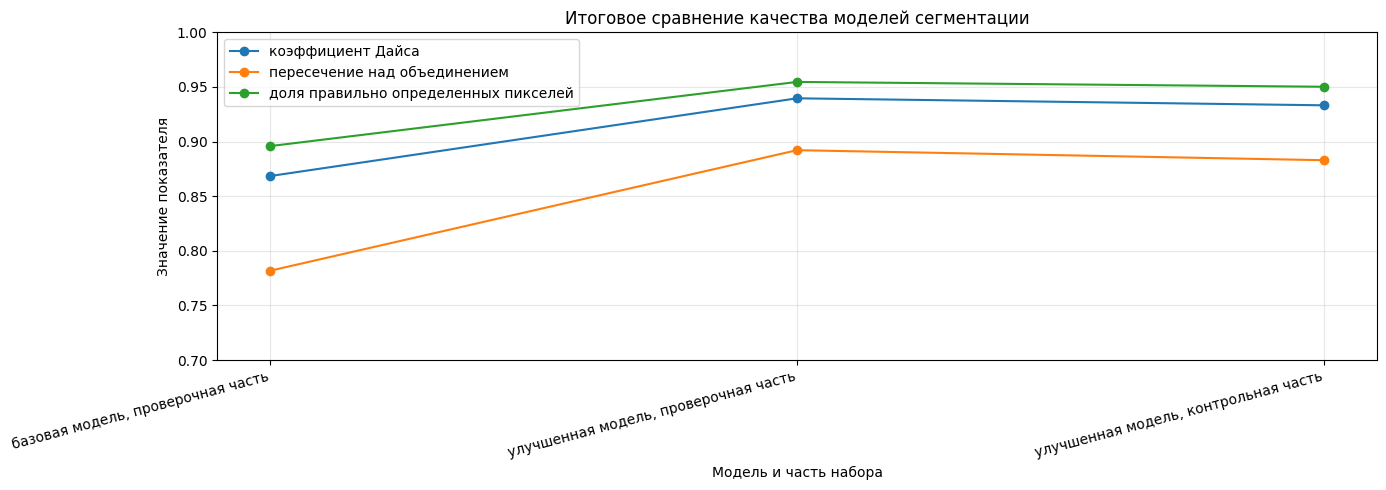

Итоговый сравнительный рисунок сохранен: /content/image_generation_processing_project/results/figures/final_model_quality_comparison.png

Локальный каталог обработанных примеров отсутствует.
Начата попытка восстановления каталога обработанных примеров.
Каталог восстановлен из Google Drive: /content/drive/MyDrive/image_generation_processing_project/export/processed_examples
Каталог обработанных примеров сохранен на Google Drive: /content/drive/MyDrive/image_generation_processing_project/export/processed_examples

Проверка готовности артефактов:


,artifact_name,artifact_path,required,exists,size_mb
0,segmentation_improved_unet_resnet34_best.pt,/content/image_generation_processing_project/r...,True,True,93.393
1,segmentation_inference_app_core.py,/content/image_generation_processing_project/r...,True,True,0.005
2,segmentation_inference_config.json,/content/image_generation_processing_project/r...,True,True,0.001
3,processed_examples,/content/image_generation_processing_project/r...,True,True,5.146
4,image_processing_app_artifacts.zip,/content/image_generation_processing_project/r...,True,True,95.125
5,segmentation_improved_control_metrics.json,/content/image_generation_processing_project/r...,True,True,0.000
6,segmentation_validation_control_comparison.csv,/content/image_generation_processing_project/r...,True,True,0.000
7,llm_image_processing_reviews.csv,/content/image_generation_processing_project/r...,False,True,0.003
8,processed_samples_manifest.csv,/content/image_generation_processing_project/r...,True,True,0.003
9,segmentation_guided_processing_examples.png,/content/image_generation_processing_project/r...,True,True,3.384


Таблица готовности артефактов сохранена: /content/image_generation_processing_project/results/metrics/final_artifact_manifest.csv
Статус готовности: полный комплект артефактов подготовлен

Сохранено: /content/image_generation_processing_project/results/reports/final_experiment_conclusion_for_dissertation.md
Сохранено: /content/image_generation_processing_project/results/export/README_FOR_LOCAL_APPLICATION.md
Сохранено: /content/image_generation_processing_project/results/reports/final_experiment_summary.json

Итоговый архив создан: /content/image_generation_processing_project/results/export/final_experiment_artifacts.zip
Размер итогового архива в мегабайтах: 96.627
Проверка архива завершена: каталог processed_examples добавлен
Сохранено на Google Drive: /content/drive/MyDrive/image_generation_processing_project/metrics/final_model_quality_table.csv
Сохранено на Google Drive: /content/drive/MyDrive/image_generation_processing_project/metrics/final_llm_quality_table.csv
Сохранено на Goog

In [71]:
# ============================================================
# 10. Итоговое обобщение результатов эксперимента
# ============================================================

from pathlib import Path
from datetime import datetime
import json
import shutil
import zipfile

import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Подготовка путей проекта
# ------------------------------------------------------------

PROJECT_DIR = Path("/content/image_generation_processing_project")
RESULTS_DIR = PROJECT_DIR / "results"

METRICS_DIR = RESULTS_DIR / "metrics"
REPORTS_DIR = RESULTS_DIR / "reports"
FIGURES_DIR = RESULTS_DIR / "figures"
MODELS_DIR = RESULTS_DIR / "models"
EXAMPLES_DIR = RESULTS_DIR / "examples"
EXPORT_DIR = RESULTS_DIR / "export"

DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/image_generation_processing_project")
DRIVE_METRICS_DIR = DRIVE_PROJECT_DIR / "metrics"
DRIVE_REPORTS_DIR = DRIVE_PROJECT_DIR / "reports"
DRIVE_FIGURES_DIR = DRIVE_PROJECT_DIR / "figures"
DRIVE_EXPORT_DIR = DRIVE_PROJECT_DIR / "export"

for directory in [
    METRICS_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
    EXPORT_DIR,
    DRIVE_METRICS_DIR,
    DRIVE_REPORTS_DIR,
    DRIVE_FIGURES_DIR,
    DRIVE_EXPORT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Каталог проекта:", PROJECT_DIR)
print("Каталог результатов:", RESULTS_DIR)
print("Каталог выгрузки:", EXPORT_DIR)


# ------------------------------------------------------------
# 2. Вспомогательные функции
# ------------------------------------------------------------

def read_json_file(path: Path) -> dict:
    """
    Читает файл с данными в формате json.
    Формат json используется для сохранения словарей с итоговыми показателями.
    """
    if not path.exists():
        raise FileNotFoundError(f"Не найден обязательный файл: {path}")

    with open(path, "r", encoding="utf-8") as file:
        return json.load(file)


def save_json_file(data: dict, path: Path) -> None:
    """
    Сохраняет словарь в файл с данными в формате json.
    """
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as file:
        json.dump(data, file, ensure_ascii=False, indent=4)

    print("Сохранено:", path)


def copy_file_to_directory(source_path: Path, target_directory: Path) -> Path:
    """
    Копирует файл в указанный каталог.
    Если исходный файл отсутствует, выводится предупреждение.
    """
    target_directory.mkdir(parents=True, exist_ok=True)

    if not source_path.exists():
        print("Файл не скопирован, так как он отсутствует:", source_path)
        return target_directory / source_path.name

    target_path = target_directory / source_path.name
    shutil.copy2(source_path, target_path)
    print("Сохранено на Google Drive:", target_path)
    return target_path


def get_path_size_mb(path: Path) -> float:
    """
    Вычисляет размер файла или каталога в мегабайтах.
    Для каталога суммируются размеры всех вложенных файлов.
    """
    if not path.exists():
        return 0.0

    if path.is_file():
        return round(path.stat().st_size / (1024 * 1024), 3)

    total_size = 0
    for nested_file in path.rglob("*"):
        if nested_file.is_file():
            total_size += nested_file.stat().st_size

    return round(total_size / (1024 * 1024), 3)


def add_path_to_zip(zip_handle: zipfile.ZipFile, source_path: Path, archive_root_name: str) -> bool:
    """
    Добавляет файл или каталог в сжатый итоговый архив.
    Возвращает True, если путь был добавлен.
    """
    if not source_path.exists():
        print("Не добавлено в архив, файл или каталог отсутствует:", source_path)
        return False

    if source_path.is_file():
        zip_handle.write(source_path, arcname=f"{archive_root_name}/{source_path.name}")
        return True

    for nested_file in source_path.rglob("*"):
        if nested_file.is_file():
            relative_path = nested_file.relative_to(source_path)
            zip_handle.write(
                nested_file,
                arcname=f"{archive_root_name}/{source_path.name}/{relative_path}",
            )

    return True


# ------------------------------------------------------------
# 3. Загрузка результатов предыдущих этапов
# ------------------------------------------------------------

dataset_summary_path = METRICS_DIR / "dataset_summary.json"
baseline_metrics_path = METRICS_DIR / "segmentation_baseline_validation_metrics.json"
improved_validation_metrics_path = METRICS_DIR / "segmentation_improved_validation_metrics.json"
improved_control_metrics_path = METRICS_DIR / "segmentation_improved_control_metrics.json"
processed_samples_manifest_path = METRICS_DIR / "processed_samples_manifest.csv"
llm_summary_by_model_path = METRICS_DIR / "llm_review_summary_by_model.csv"

dataset_summary = read_json_file(dataset_summary_path)
baseline_metrics = read_json_file(baseline_metrics_path)
improved_validation_metrics = read_json_file(improved_validation_metrics_path)
improved_control_metrics = read_json_file(improved_control_metrics_path)

print("\nСведения о наборе данных:")
for key, value in dataset_summary.items():
    print(key, ":", value)

print("\nПоказатели базовой модели на проверочной части:")
for key, value in baseline_metrics.items():
    print(key, ":", value)

print("\nПоказатели улучшенной модели на проверочной части:")
for key, value in improved_validation_metrics.items():
    print(key, ":", value)

print("\nПоказатели улучшенной модели на контрольной части:")
for key, value in improved_control_metrics.items():
    print(key, ":", value)


# ------------------------------------------------------------
# 4. Формирование итоговой таблицы качества моделей
# ------------------------------------------------------------

final_model_quality_rows = [
    {
        "model_id": "segmentation_baseline_unet",
        "model_name_ru": "базовая модель",
        "evaluation_part": "проверочная часть",
        "loss": baseline_metrics["loss"],
        "dice": baseline_metrics["dice"],
        "iou": baseline_metrics["iou"],
        "pixel_accuracy": baseline_metrics["pixel_accuracy"],
        "trainable_parameters": baseline_metrics["trainable_parameters"],
        "best_epoch": baseline_metrics["best_epoch"],
    },
    {
        "model_id": "segmentation_improved_unet_resnet34",
        "model_name_ru": "улучшенная модель",
        "evaluation_part": "проверочная часть",
        "loss": improved_validation_metrics["loss"],
        "dice": improved_validation_metrics["dice"],
        "iou": improved_validation_metrics["iou"],
        "pixel_accuracy": improved_validation_metrics["pixel_accuracy"],
        "trainable_parameters": improved_validation_metrics["trainable_parameters"],
        "best_epoch": improved_validation_metrics["best_epoch"],
    },
    {
        "model_id": "segmentation_improved_unet_resnet34",
        "model_name_ru": "улучшенная модель",
        "evaluation_part": "контрольная часть",
        "loss": improved_control_metrics["loss"],
        "dice": improved_control_metrics["dice"],
        "iou": improved_control_metrics["iou"],
        "pixel_accuracy": improved_control_metrics["pixel_accuracy"],
        "trainable_parameters": improved_validation_metrics["trainable_parameters"],
        "best_epoch": improved_control_metrics["best_epoch"],
    },
]

final_model_quality_table = pd.DataFrame(final_model_quality_rows)

final_model_quality_path = METRICS_DIR / "final_model_quality_table.csv"
final_model_quality_table.to_csv(final_model_quality_path, index=False, encoding="utf-8-sig")

print("\nИтоговая таблица качества моделей:")
display(final_model_quality_table)
print("Итоговая таблица качества сохранена:", final_model_quality_path)


# ------------------------------------------------------------
# 5. Расчет прироста качества
# ------------------------------------------------------------

dice_gain_absolute = improved_validation_metrics["dice"] - baseline_metrics["dice"]
iou_gain_absolute = improved_validation_metrics["iou"] - baseline_metrics["iou"]
pixel_accuracy_gain_absolute = improved_validation_metrics["pixel_accuracy"] - baseline_metrics["pixel_accuracy"]

dice_gain_relative_percent = dice_gain_absolute / baseline_metrics["dice"] * 100
iou_gain_relative_percent = iou_gain_absolute / baseline_metrics["iou"] * 100
pixel_accuracy_gain_relative_percent = (
    pixel_accuracy_gain_absolute / baseline_metrics["pixel_accuracy"] * 100
)

control_dice_difference = improved_control_metrics["dice"] - improved_validation_metrics["dice"]
control_iou_difference = improved_control_metrics["iou"] - improved_validation_metrics["iou"]
control_pixel_accuracy_difference = (
    improved_control_metrics["pixel_accuracy"] - improved_validation_metrics["pixel_accuracy"]
)

print("\nПрирост качества улучшенной модели относительно базовой модели:")
print("Абсолютный прирост коэффициента Дайса:", round(dice_gain_absolute, 4))
print("Относительный прирост коэффициента Дайса, процентов:", round(dice_gain_relative_percent, 2))
print("Абсолютный прирост пересечения над объединением:", round(iou_gain_absolute, 4))
print("Относительный прирост пересечения над объединением, процентов:", round(iou_gain_relative_percent, 2))
print("Абсолютный прирост доли правильно определенных пикселей:", round(pixel_accuracy_gain_absolute, 4))
print("Относительный прирост доли правильно определенных пикселей, процентов:", round(pixel_accuracy_gain_relative_percent, 2))

print("\nИзменение качества на контрольной части относительно проверочной части:")
print("Изменение коэффициента Дайса:", round(control_dice_difference, 4))
print("Изменение пересечения над объединением:", round(control_iou_difference, 4))
print("Изменение доли правильно определенных пикселей:", round(control_pixel_accuracy_difference, 4))


# ------------------------------------------------------------
# 6. Сохранение итоговой таблицы визуальной оценки
# ------------------------------------------------------------

if llm_summary_by_model_path.exists():
    final_llm_quality_table = pd.read_csv(llm_summary_by_model_path)
    final_llm_quality_path = METRICS_DIR / "final_llm_quality_table.csv"
    final_llm_quality_table.to_csv(final_llm_quality_path, index=False, encoding="utf-8-sig")

    print("\nИтоговая таблица визуальной оценки по моделям ChatGPT:")
    display(final_llm_quality_table)
    print("Итоговая таблица визуальной оценки сохранена:", final_llm_quality_path)

    best_llm_model = (
        final_llm_quality_table
        .sort_values("mean_visual_score", ascending=False)
        .iloc[0]["model_name"]
    )
else:
    final_llm_quality_table = pd.DataFrame()
    final_llm_quality_path = None
    best_llm_model = "визуальная оценка не выполнялась"

    print("\nТаблица визуальной оценки не найдена. Этот блок пропущен.")


# ------------------------------------------------------------
# 7. Построение итогового сравнительного рисунка
# ------------------------------------------------------------

plot_table = final_model_quality_table.copy()
plot_table["model_and_part"] = (
    plot_table["model_name_ru"] + ", " + plot_table["evaluation_part"]
)

plt.figure(figsize=(14, 5))
plt.plot(
    plot_table["model_and_part"],
    plot_table["dice"],
    marker="o",
    label="коэффициент Дайса",
)
plt.plot(
    plot_table["model_and_part"],
    plot_table["iou"],
    marker="o",
    label="пересечение над объединением",
)
plt.plot(
    plot_table["model_and_part"],
    plot_table["pixel_accuracy"],
    marker="o",
    label="доля правильно определенных пикселей",
)

plt.title("Итоговое сравнение качества моделей сегментации")
plt.xlabel("Модель и часть набора")
plt.ylabel("Значение показателя")
plt.ylim(0.70, 1.00)
plt.xticks(rotation=15, ha="right")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

final_quality_figure_path = FIGURES_DIR / "final_model_quality_comparison.png"
plt.savefig(final_quality_figure_path, dpi=150)
plt.show()

print("Итоговый сравнительный рисунок сохранен:", final_quality_figure_path)


# ------------------------------------------------------------
# 8. Восстановление каталога обработанных примеров
# ------------------------------------------------------------

processed_examples_local_dir = EXPORT_DIR / "processed_examples"
processed_examples_drive_dir = DRIVE_EXPORT_DIR / "processed_examples"

if not processed_examples_local_dir.exists():
    print("\nЛокальный каталог обработанных примеров отсутствует.")
    print("Начата попытка восстановления каталога обработанных примеров.")

    if processed_examples_drive_dir.exists():
        shutil.copytree(processed_examples_drive_dir, processed_examples_local_dir)
        print("Каталог восстановлен из Google Drive:", processed_examples_drive_dir)

    elif processed_samples_manifest_path.exists():
        processed_examples_local_dir.mkdir(parents=True, exist_ok=True)

        processed_manifest = pd.read_csv(processed_samples_manifest_path)
        image_path_columns = [
            "original_path",
            "predicted_mask_path",
            "transparent_object_path",
            "blurred_background_path",
            "generated_background_path",
        ]

        copied_file_count = 0

        for _, row in processed_manifest.iterrows():
            image_id = str(row.get("image_id", "unknown_image"))
            sample_dir = processed_examples_local_dir / image_id
            sample_dir.mkdir(parents=True, exist_ok=True)

            for column_name in image_path_columns:
                if column_name not in processed_manifest.columns:
                    continue

                source_path = Path(str(row[column_name]))
                if source_path.exists() and source_path.is_file():
                    target_path = sample_dir / f"{column_name}_{source_path.name}"
                    shutil.copy2(source_path, target_path)
                    copied_file_count += 1

        if copied_file_count == 0:
            raise FileNotFoundError(
                "Не удалось восстановить каталог processed_examples. "
                "В таблице processed_samples_manifest.csv не найдено доступных файлов."
            )

        print("Каталог восстановлен из таблицы обработанных примеров")
        print("Количество скопированных файлов:", copied_file_count)

    else:
        raise FileNotFoundError(
            "Не найден processed_examples и отсутствует таблица processed_samples_manifest.csv. "
            "Необходимо повторить этап применения модели к отдельным изображениям."
        )
else:
    print("\nЛокальный каталог обработанных примеров найден:", processed_examples_local_dir)

# Дополнительно сохраняем восстановленный каталог на Google Drive.
if processed_examples_local_dir.exists():
    if processed_examples_drive_dir.exists():
        shutil.rmtree(processed_examples_drive_dir)

    shutil.copytree(processed_examples_local_dir, processed_examples_drive_dir)
    print("Каталог обработанных примеров сохранен на Google Drive:", processed_examples_drive_dir)


# ------------------------------------------------------------
# 9. Проверка готовности артефактов приложения и эксперимента
# ------------------------------------------------------------

artifact_items = [
    {
        "artifact_name": "segmentation_improved_unet_resnet34_best.pt",
        "artifact_path": MODELS_DIR / "segmentation_improved_unet_resnet34_best.pt",
        "required": True,
    },
    {
        "artifact_name": "segmentation_inference_app_core.py",
        "artifact_path": EXPORT_DIR / "segmentation_inference_app_core.py",
        "required": True,
    },
    {
        "artifact_name": "segmentation_inference_config.json",
        "artifact_path": EXPORT_DIR / "segmentation_inference_config.json",
        "required": True,
    },
    {
        "artifact_name": "processed_examples",
        "artifact_path": processed_examples_local_dir,
        "required": True,
    },
    {
        "artifact_name": "image_processing_app_artifacts.zip",
        "artifact_path": EXPORT_DIR / "image_processing_app_artifacts.zip",
        "required": True,
    },
    {
        "artifact_name": "segmentation_improved_control_metrics.json",
        "artifact_path": METRICS_DIR / "segmentation_improved_control_metrics.json",
        "required": True,
    },
    {
        "artifact_name": "segmentation_validation_control_comparison.csv",
        "artifact_path": METRICS_DIR / "segmentation_validation_control_comparison.csv",
        "required": True,
    },
    {
        "artifact_name": "llm_image_processing_reviews.csv",
        "artifact_path": METRICS_DIR / "llm_image_processing_reviews.csv",
        "required": False,
    },
    {
        "artifact_name": "processed_samples_manifest.csv",
        "artifact_path": METRICS_DIR / "processed_samples_manifest.csv",
        "required": True,
    },
    {
        "artifact_name": "segmentation_guided_processing_examples.png",
        "artifact_path": EXAMPLES_DIR / "segmentation_guided_processing_examples.png",
        "required": True,
    },
    {
        "artifact_name": "llm_evaluation_input_collages.png",
        "artifact_path": EXAMPLES_DIR / "llm_evaluation_input_collages.png",
        "required": False,
    },
    {
        "artifact_name": "final_model_quality_comparison.png",
        "artifact_path": final_quality_figure_path,
        "required": True,
    },
]

artifact_rows = []

for item in artifact_items:
    path = item["artifact_path"]

    artifact_rows.append(
        {
            "artifact_name": item["artifact_name"],
            "artifact_path": str(path),
            "required": item["required"],
            "exists": path.exists(),
            "size_mb": get_path_size_mb(path),
        }
    )

artifact_manifest = pd.DataFrame(artifact_rows)
artifact_manifest_path = METRICS_DIR / "final_artifact_manifest.csv"
artifact_manifest.to_csv(artifact_manifest_path, index=False, encoding="utf-8-sig")

print("\nПроверка готовности артефактов:")
display(artifact_manifest)
print("Таблица готовности артефактов сохранена:", artifact_manifest_path)

required_missing = artifact_manifest[
    (artifact_manifest["required"] == True) & (artifact_manifest["exists"] == False)
]

if len(required_missing) > 0:
    print("\nОтсутствуют обязательные артефакты:")
    display(required_missing)

    raise FileNotFoundError(
        "Итоговый комплект артефактов неполный. "
        "Необходимо восстановить отсутствующие файлы перед созданием архива."
    )

artifact_status = "полный комплект артефактов подготовлен"
print("Статус готовности:", artifact_status)


# ------------------------------------------------------------
# 10. Формирование заключения для текста работы
# ------------------------------------------------------------

final_conclusion_text = f"""
# Итоговое заключение по экспериментальной части

В экспериментальной части была разработана и проверена система выделения объекта на изображении животного с последующей обработкой фона. В качестве исходной базы использован набор изображений, включающий {dataset_summary["количество_записей_в_таблице"]} пригодных записей, {dataset_summary["количество_пород"]} пород, {dataset_summary["количество_кошек"]} изображений кошек и {dataset_summary["количество_собак"]} изображений собак. Наличие масок позволило сформировать задачу попиксельного выделения объекта и объективно оценить качество результата.

Базовая модель сегментации достигла на проверочной части коэффициента Дайса {baseline_metrics["dice"]:.4f}, пересечения над объединением {baseline_metrics["iou"]:.4f} и доли правильно определенных пикселей {baseline_metrics["pixel_accuracy"]:.4f}. Улучшенная модель с предварительно обученным кодировщиком показала на той же части коэффициент Дайса {improved_validation_metrics["dice"]:.4f}, пересечение над объединением {improved_validation_metrics["iou"]:.4f} и долю правильно определенных пикселей {improved_validation_metrics["pixel_accuracy"]:.4f}. Абсолютный прирост коэффициента Дайса составил {dice_gain_absolute:.4f}, прирост пересечения над объединением — {iou_gain_absolute:.4f}, прирост доли правильно определенных пикселей — {pixel_accuracy_gain_absolute:.4f}.

Контрольная проверка лучшей модели показала коэффициент Дайса {improved_control_metrics["dice"]:.4f}, пересечение над объединением {improved_control_metrics["iou"]:.4f} и долю правильно определенных пикселей {improved_control_metrics["pixel_accuracy"]:.4f}. Различие между проверочной и контрольной частями оказалось небольшим: изменение коэффициента Дайса составило {control_dice_difference:.4f}, изменение пересечения над объединением — {control_iou_difference:.4f}, изменение доли правильно определенных пикселей — {control_pixel_accuracy_difference:.4f}. Такой результат указывает на устойчивость модели при обработке изображений, не использованных при обучении.

Научная новизна эксперимента состоит в объединении трех уровней оценки: пиксельных метрик сегментации, контрольной проверки на отложенной части набора и визуальной экспертной оценки обработанных изображений с помощью моделей ChatGPT. Такая схема позволяет оценить не только формальное совпадение предсказанной маски с разметкой, но и прикладное качество результата для пользовательского приложения. Лучшей моделью визуальной оценки стала {best_llm_model}.

По итогам эксперимента подготовлен полный комплект артефактов: сохраненная лучшая модель, файл настроек, программный модуль для применения сегментации, обработанные демонстрационные примеры, итоговые таблицы качества, сравнительные рисунки и архив для переноса в локальное приложение.
""".strip()

final_conclusion_path = REPORTS_DIR / "final_experiment_conclusion_for_dissertation.md"
with open(final_conclusion_path, "w", encoding="utf-8") as file:
    file.write(final_conclusion_text)

print("\nСохранено:", final_conclusion_path)


# ------------------------------------------------------------
# 11. Формирование файла с пояснением для локального приложения
# ------------------------------------------------------------

readme_text = f"""
# Файлы для локального приложения

В архиве находятся основные артефакты эксперимента:

1. segmentation_improved_unet_resnet34_best.pt — сохраненная лучшая модель сегментации.
2. segmentation_inference_config.json — настройки применения модели.
3. segmentation_inference_app_core.py — программный модуль для применения модели к отдельному изображению.
4. processed_examples — каталог с обработанными демонстрационными изображениями.
5. metrics — итоговые таблицы качества и проверки.
6. figures — итоговые рисунки для отчета.
7. reports — текстовое заключение и сводка эксперимента.

Лучшее качество на контрольной части:
коэффициент Дайса — {improved_control_metrics["dice"]:.4f};
пересечение над объединением — {improved_control_metrics["iou"]:.4f};
доля правильно определенных пикселей — {improved_control_metrics["pixel_accuracy"]:.4f}.

Артефакты предназначены для переноса в пользовательское приложение, где модель выделяет животное на изображении и формирует варианты обработки: объект без фона, изображение с размытым фоном и изображение с замененным фоном.
""".strip()

readme_path = EXPORT_DIR / "README_FOR_LOCAL_APPLICATION.md"
with open(readme_path, "w", encoding="utf-8") as file:
    file.write(readme_text)

print("Сохранено:", readme_path)


# ------------------------------------------------------------
# 12. Сохранение итоговой сводки эксперимента
# ------------------------------------------------------------

final_summary = {
    "stage_name": "final_experiment_summary",
    "stage_name_ru": "итоговое обобщение результатов эксперимента",
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "dataset_image_count": int(dataset_summary["количество_записей_в_таблице"]),
    "breed_count": int(dataset_summary["количество_пород"]),
    "cat_count": int(dataset_summary["количество_кошек"]),
    "dog_count": int(dataset_summary["количество_собак"]),
    "baseline_validation_dice": float(baseline_metrics["dice"]),
    "improved_validation_dice": float(improved_validation_metrics["dice"]),
    "improved_control_dice": float(improved_control_metrics["dice"]),
    "baseline_validation_iou": float(baseline_metrics["iou"]),
    "improved_validation_iou": float(improved_validation_metrics["iou"]),
    "improved_control_iou": float(improved_control_metrics["iou"]),
    "dice_gain_absolute": float(dice_gain_absolute),
    "dice_gain_relative_percent": float(dice_gain_relative_percent),
    "iou_gain_absolute": float(iou_gain_absolute),
    "iou_gain_relative_percent": float(iou_gain_relative_percent),
    "pixel_accuracy_gain_absolute": float(pixel_accuracy_gain_absolute),
    "pixel_accuracy_gain_relative_percent": float(pixel_accuracy_gain_relative_percent),
    "control_dice_difference": float(control_dice_difference),
    "control_iou_difference": float(control_iou_difference),
    "control_pixel_accuracy_difference": float(control_pixel_accuracy_difference),
    "best_llm_model_by_visual_score": str(best_llm_model),
    "artifact_status": artifact_status,
    "scientific_novelty_note": (
        "Эксперимент объединяет сравнение базовой и улучшенной модели сегментации, "
        "контрольную проверку на отложенной части набора и экспертную визуальную оценку "
        "обработанных изображений с помощью моделей ChatGPT."
    ),
}

final_summary_path = REPORTS_DIR / "final_experiment_summary.json"
save_json_file(final_summary, final_summary_path)


# ------------------------------------------------------------
# 13. Создание итогового архива
# ------------------------------------------------------------

final_archive_path = EXPORT_DIR / "final_experiment_artifacts.zip"

if final_archive_path.exists():
    final_archive_path.unlink()

paths_for_archive = [
    MODELS_DIR / "segmentation_improved_unet_resnet34_best.pt",
    EXPORT_DIR / "segmentation_inference_app_core.py",
    EXPORT_DIR / "segmentation_inference_config.json",
    EXPORT_DIR / "README_FOR_LOCAL_APPLICATION.md",
    processed_examples_local_dir,
    METRICS_DIR / "final_model_quality_table.csv",
    METRICS_DIR / "final_llm_quality_table.csv",
    METRICS_DIR / "final_artifact_manifest.csv",
    METRICS_DIR / "segmentation_improved_control_metrics.json",
    METRICS_DIR / "segmentation_validation_control_comparison.csv",
    METRICS_DIR / "llm_image_processing_reviews.csv",
    METRICS_DIR / "processed_samples_manifest.csv",
    REPORTS_DIR / "final_experiment_summary.json",
    REPORTS_DIR / "final_experiment_conclusion_for_dissertation.md",
    FIGURES_DIR / "final_model_quality_comparison.png",
    EXAMPLES_DIR / "segmentation_guided_processing_examples.png",
    EXAMPLES_DIR / "llm_evaluation_input_collages.png",
]

added_items = []

with zipfile.ZipFile(final_archive_path, "w", compression=zipfile.ZIP_DEFLATED) as zip_handle:
    for source_path in paths_for_archive:
        if source_path.exists():
            add_path_to_zip(zip_handle, source_path, "final_experiment_artifacts")
            added_items.append(str(source_path))
        else:
            print("Необязательный файл не добавлен в архив:", source_path)

print("\nИтоговый архив создан:", final_archive_path)
print("Размер итогового архива в мегабайтах:", get_path_size_mb(final_archive_path))

# Проверяем, что каталог processed_examples действительно попал в архив.
with zipfile.ZipFile(final_archive_path, "r") as zip_handle:
    archive_names = zip_handle.namelist()

processed_examples_in_archive = any(
    "processed_examples/" in archive_name for archive_name in archive_names
)

if not processed_examples_in_archive:
    raise RuntimeError(
        "Каталог processed_examples не попал в итоговый архив. "
        "Необходимо проверить блок создания архива."
    )

print("Проверка архива завершена: каталог processed_examples добавлен")


# ------------------------------------------------------------
# 14. Копирование итоговых файлов на Google Drive
# ------------------------------------------------------------

copy_file_to_directory(final_model_quality_path, DRIVE_METRICS_DIR)

if final_llm_quality_path is not None and final_llm_quality_path.exists():
    copy_file_to_directory(final_llm_quality_path, DRIVE_METRICS_DIR)

copy_file_to_directory(artifact_manifest_path, DRIVE_METRICS_DIR)
copy_file_to_directory(final_summary_path, DRIVE_REPORTS_DIR)
copy_file_to_directory(final_conclusion_path, DRIVE_REPORTS_DIR)
copy_file_to_directory(readme_path, DRIVE_EXPORT_DIR)
copy_file_to_directory(final_quality_figure_path, DRIVE_FIGURES_DIR)
copy_file_to_directory(final_archive_path, DRIVE_EXPORT_DIR)


# ------------------------------------------------------------
# 15. Краткая итоговая сводка
# ------------------------------------------------------------

print("\nИтоговые файлы этапа 10 сохранены на Google Drive")

print("\nКраткая итоговая сводка:")
print("Количество пригодных изображений:", dataset_summary["количество_записей_в_таблице"])
print("Количество пород:", dataset_summary["количество_пород"])
print("Коэффициент Дайса базовой модели на проверочной части:", round(baseline_metrics["dice"], 4))
print("Коэффициент Дайса улучшенной модели на проверочной части:", round(improved_validation_metrics["dice"], 4))
print("Коэффициент Дайса улучшенной модели на контрольной части:", round(improved_control_metrics["dice"], 4))
print("Абсолютный прирост коэффициента Дайса:", round(dice_gain_absolute, 4))
print("Лучшая модель визуальной оценки:", best_llm_model)
print("Статус готовности артефактов:", artifact_status)
print("Итоговый архив:", final_archive_path)
print("Каталог processed_examples добавлен в архив:", processed_examples_in_archive)
print("Этап 10 завершен")

В результате экспериментальной проверки было установлено, что улучшенная модель сегментации на основе архитектуры U-Net с кодировщиком ResNet34 и предварительно обученными весами ImageNet обеспечивает более высокое качество выделения животных на изображениях по сравнению с базовой моделью SimpleUNet. На проверочной части коэффициент Дайса увеличился с 0,8685 до 0,9396, показатель пересечения над объединением — с 0,7818 до 0,8921, а доля правильно определенных пикселей — с 0,8959 до 0,9546. Дополнительная проверка на контрольной части подтвердила устойчивость результата: коэффициент Дайса составил 0,9332, что лишь на 0,0064 ниже значения на проверочной части. Полученные значения свидетельствуют о способности модели сохранять качество на данных, не участвовавших в подборе параметров.

На основе лучшей модели были сформированы прикладные артефакты: файл весов, конфигурация инференса, программный модуль для локального приложения, набор обработанных примеров и итоговый архив. Дополнительно проведена визуальная оценка качества обработки с использованием моделей ChatGPT, где сравнивались границы объекта, качество фона, визуальная естественность и готовность результата к применению. Средняя экспертная оценка показала, что обработка в целом пригодна для пользовательского сценария, однако наиболее заметные ограничения связаны с артефактами на границе шерсти и недостаточно естественным восстановлением фона. Следовательно, разработанная система может использоваться как основа приложения для сегментации животных и последующей обработки изображений, а дальнейшее улучшение целесообразно направить на уточнение контуров мелких деталей и повышение реалистичности генерации фона.

In [72]:
# ============================================================
# Выгрузка ТОЛЬКО необходимых артефактов для будущего приложения
# ============================================================

from pathlib import Path
import json
import shutil
import zipfile
from datetime import datetime

# ------------------------------------------------------------
# 1. Основные каталоги проекта
# ------------------------------------------------------------

PROJECT_DIR = Path("/content/image_generation_processing_project")
RESULTS_DIR = PROJECT_DIR / "results"
EXPORT_DIR = RESULTS_DIR / "export"

DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/image_generation_processing_project")
DRIVE_EXPORT_DIR = DRIVE_PROJECT_DIR / "export"

MINIMAL_DIR = EXPORT_DIR / "app_button_minimal_artifacts"
ZIP_PATH = EXPORT_DIR / "app_button_minimal_artifacts.zip"
DRIVE_ZIP_PATH = DRIVE_EXPORT_DIR / "app_button_minimal_artifacts.zip"

# ------------------------------------------------------------
# 2. Поиск обязательных файлов
# ------------------------------------------------------------

def find_first_existing(candidates, artifact_name):
    for path in candidates:
        if path.exists():
            print(f"Найдено: {artifact_name}: {path}")
            return path
    raise FileNotFoundError(
        f"Не найден обязательный артефакт: {artifact_name}\n"
        + "\n".join(str(p) for p in candidates)
    )

model_path = find_first_existing(
    [
        RESULTS_DIR / "models" / "segmentation_improved_unet_resnet34_best.pt",
        DRIVE_PROJECT_DIR / "models" / "segmentation_improved_unet_resnet34_best.pt",
    ],
    "лучшая модель сегментации"
)

core_path = find_first_existing(
    [
        EXPORT_DIR / "segmentation_inference_app_core.py",
        DRIVE_EXPORT_DIR / "segmentation_inference_app_core.py",
    ],
    "программный модуль инференса"
)

config_path = find_first_existing(
    [
        EXPORT_DIR / "segmentation_inference_config.json",
        RESULTS_DIR / "metrics" / "segmentation_inference_config.json",
        DRIVE_PROJECT_DIR / "metrics" / "segmentation_inference_config.json",
        DRIVE_EXPORT_DIR / "segmentation_inference_config.json",
    ],
    "конфигурация инференса"
)

# ------------------------------------------------------------
# 3. Создание минимального каталога выгрузки
# ------------------------------------------------------------

if MINIMAL_DIR.exists():
    shutil.rmtree(MINIMAL_DIR)

MINIMAL_DIR.mkdir(parents=True, exist_ok=True)

target_model_path = MINIMAL_DIR / "segmentation_improved_unet_resnet34_best.pt"
target_core_path = MINIMAL_DIR / "segmentation_inference_app_core.py"
target_config_path = MINIMAL_DIR / "segmentation_inference_config.json"
target_requirements_path = MINIMAL_DIR / "requirements.txt"

shutil.copy2(model_path, target_model_path)
shutil.copy2(core_path, target_core_path)

# ------------------------------------------------------------
# 4. Подготовка конфигурации для переносимого приложения
# ------------------------------------------------------------

with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

# В конфиг добавляется переносимый путь к модели внутри архива.
# Это нужно, чтобы будущему приложению было проще найти файл весов.
config["model_path"] = "segmentation_improved_unet_resnet34_best.pt"
config["model_filename"] = "segmentation_improved_unet_resnet34_best.pt"
config["inference_core_filename"] = "segmentation_inference_app_core.py"
config["export_created_at"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
config["artifact_pack_type"] = "minimal_application_runtime"

with open(target_config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

# ------------------------------------------------------------
# 5. Минимальные зависимости для будущего приложения
# ------------------------------------------------------------

requirements_text = """torch
torchvision
segmentation-models-pytorch==0.5.0
Pillow
numpy
opencv-python
"""

target_requirements_path.write_text(requirements_text, encoding="utf-8")

# ------------------------------------------------------------
# 6. Проверка: в выгрузке нет лишних экспериментальных файлов
# ------------------------------------------------------------

required_files = [
    target_model_path,
    target_core_path,
    target_config_path,
    target_requirements_path,
]

missing = [p for p in required_files if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Не удалось подготовить обязательные файлы:\n"
        + "\n".join(str(p) for p in missing)
    )

print("\nМинимальный комплект приложения подготовлен:")
for p in required_files:
    size_mb = p.stat().st_size / (1024 * 1024)
    print(f"- {p.name}: {size_mb:.3f} МБ")

# ------------------------------------------------------------
# 7. Создание ZIP-архива только с минимальными файлами
# ------------------------------------------------------------

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
    for file_path in required_files:
        zipf.write(file_path, arcname=file_path.name)

zip_size_mb = ZIP_PATH.stat().st_size / (1024 * 1024)

print("\nИтоговый минимальный архив создан:")
print(ZIP_PATH)
print(f"Размер архива: {zip_size_mb:.3f} МБ")

# ------------------------------------------------------------
# 8. Сохранение архива на Google Drive
# ------------------------------------------------------------

DRIVE_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
shutil.copy2(ZIP_PATH, DRIVE_ZIP_PATH)

print("\nАрхив сохранен на Google Drive:")
print(DRIVE_ZIP_PATH)

# ------------------------------------------------------------
# 9. Скачивание архива из Colab
# ------------------------------------------------------------

try:
    from google.colab import files
    files.download(str(ZIP_PATH))
except Exception as exc:
    print("\nАвтоматическое скачивание не выполнено.")
    print("Архив можно скачать вручную по пути:")
    print(ZIP_PATH)
    print("Причина:", repr(exc))

Найдено: лучшая модель сегментации: /content/image_generation_processing_project/results/models/segmentation_improved_unet_resnet34_best.pt
Найдено: программный модуль инференса: /content/image_generation_processing_project/results/export/segmentation_inference_app_core.py
Найдено: конфигурация инференса: /content/image_generation_processing_project/results/export/segmentation_inference_config.json

Минимальный комплект приложения подготовлен:
- segmentation_improved_unet_resnet34_best.pt: 93.393 МБ
- segmentation_inference_app_core.py: 0.005 МБ
- segmentation_inference_config.json: 0.001 МБ
- requirements.txt: 0.000 МБ

Итоговый минимальный архив создан:
/content/image_generation_processing_project/results/export/app_button_minimal_artifacts.zip
Размер архива: 86.633 МБ

Архив сохранен на Google Drive:
/content/drive/MyDrive/image_generation_processing_project/export/app_button_minimal_artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>